# Age prediction from single-cell PBMC data with `patpy`

This tutorial benchmarks six sample-representation methods on the task of
**predicting biological age from PBMC scRNA-seq profiles**, then validates
the biological conclusions on an independent cohort, and finally cracks
open one of the supervised models (SampleCLR) to read the per-cell
attention weights that drive its age prediction.

The methods cover the four flavours of sample-level analysis exposed by
`patpy`:

- **Pseudobulk** (`patpy.tl.Pseudobulk`) — mean of cell embeddings per donor.
- **Cell-group composition with CLR** (`patpy.tl.CellGroupComposition`) — the
  fractions of every cell type in a donor, centred-log-ratio transformed.
- **GloScope** (`patpy.tl.GloScope_py`) — KL-divergence between donor-level
  cell-state distributions.
- **SampleCLR** ([package](https://github.com/lueckenlab/SampleCLR)) — a
  contrastive sample-level model with a self-supervised + supervised stage.
- **PaSCient** (`patpy.tl.PaSCient`) — cell→patient attention model.
- **MixMIL** (`patpy.tl.MixMIL`) — mixed-model multiple-instance learning.

We run them on the **AIFI Immunobiology of Aging** cohort (234 donors,
ages 40–89, 3.76 M PBMCs across 17 sequencing batches) and validate on
**OneK1K** (981 donors, ages 19–97).

Two questions:

1. **Engineering:** which sample representation best preserves age signal
   while not encoding the sequencing batch?
2. **Biology:** what changes in immune composition / per-cell-type
   transcription are reproducible across cohorts, and what genes drive
   the age signal inside the cell types the model pays the most
   attention to?

The notebook is self-contained — every fit, score and figure comes
from running its own cells. On a single CPU core a full pass takes
30–60 minutes; PaSCient finishes much faster on a GPU.

## Setup

Set ``SMOKE = True`` to iterate on a 20-donor × 200-cell subset (good
for debugging). The full run uses all donors and caps slow methods at
500 cells/donor.

In [1]:
%load_ext autoreload
%autoreload 2
import gc, os, time, warnings
from pathlib import Path

# Silence per-epoch training progress bars / framework logs so the methods below
# don't flood the notebook (SampleCLR already runs with verbose=False).
os.environ["TQDM_DISABLE"] = "1"

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

import patpy

warnings.filterwarnings("ignore", category=UserWarning)

import logging
for _logger in ("lightning.pytorch", "pytorch_lightning", "lightning"):
    logging.getLogger(_logger).setLevel(logging.ERROR)

# Plotting defaults: no grid, despine top + right, frameless UMAPs.
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sc.set_figure_params(dpi=80, frameon=False)

def despine(*axes):
    """Drop the top/right spines on every axis passed in."""
    for ax in axes:
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        ax.grid(False)

def style_umap(ax):
    """Strip frame + ticks from an embedding scatter."""
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

SEED = 42
print("patpy", patpy.__version__, " · torch.cuda.is_available()", torch.cuda.is_available())


patpy 0.16.5  · torch.cuda.is_available() True


In [2]:
# Quick-iteration flag. Set to True for a 20-donor × 200-cell sanity loop.
SMOKE = False

# Capped sample size per donor for the slow methods (GloScope / SampleCLR /
# PaSCient / MixMIL). Pseudobulk + composition use all cells.
N_CELLS_PER_DONOR = 200 if SMOKE else 500

# Held-out test fraction for the KNN regression score.
TEST_FRACTION = 0.20
N_NEIGHBORS = 5

## The AIFI Immunobiology of Aging cohort

The AIFI **Immunobiology of Aging** dataset is 234 healthy donors aged
40–89, with PBMCs profiled at single-cell resolution under one
protocol but split across 17 well-balanced sequencing batches.

We load the precomputed h5ad (HVG + log-normalised + 50 PCs in
``.obsm["X_pca"]``) and clean the age column (the AIFI release encodes
ages ≥89 as the literal string ``"89+"``).

In [3]:
AIFI_PATH = "/ictstr01/groups/luckylab/workspace/vladimir.shitov/aifi_data/imm_of_aging/imm-of-aging_pp.h5ad"


def add_clean_obs(adata):
    adata.obs["age"] = pd.to_numeric(adata.obs["sample.subjectAgeAtDraw"].astype(str).str.replace("+", ""))
    adata.obs["age_group"] = np.where(adata.obs["age"] >= 65, "old", "young")
    adata.obs["donor"] = adata.obs["subject.subjectGuid"].astype(str)
    return adata


def load_aging(smoke=False, n_donors=20, seed=42):
    """Read the AIFI aging cohort.

    In smoke mode, slice donors before materialising so we never pull the full
    5 GB into memory on a small machine.
    """
    if smoke:
        aging = ad.read_h5ad(AIFI_PATH, backed="r")
        donors = pd.unique(aging.obs["subject.subjectGuid"].astype(str))
        rng = np.random.default_rng(seed)
        donors = donors[rng.permutation(len(donors))[:n_donors]]
        keep_cells = aging.obs["subject.subjectGuid"].astype(str).isin(set(donors.tolist())).values
        aging = aging[keep_cells].to_memory()
    else:
        aging = ad.read_h5ad(AIFI_PATH)
    return add_clean_obs(aging)


t0 = time.time()
adata = load_aging(smoke=SMOKE)
print(f"loaded in {time.time() - t0:.1f}s - n_cells={adata.n_obs:,} n_genes={adata.n_vars}")
print(f"n_donors={adata.obs['donor'].nunique()}  age range={adata.obs['age'].min():.0f}-{adata.obs['age'].max():.0f}")


loaded in 77.8s - n_cells=3,758,514 n_genes=4000
n_donors=234  age range=40-89


        age age_group     sex       cmv              race    batch     pool  \
donor                                                                         
SF3001   52     young  Female  Negative  African American  B172-PC  B172-PC   
SF3006   68       old    Male  Positive   American Indian  B172-PC  B172-PC   
SF3016   47     young    Male  Negative         Caucasian  B171-PB  B171-PB   
SF3020   70       old  Female  Positive             Asian  B155-PA  B155-PA   
SF3024   50     young  Female  Positive   American Indian  B172-PB  B172-PB   

             chip  n_cells  
donor                       
SF3001  B172-PCC1    24303  
SF3006  B172-PCC1    12390  
SF3016  B171-PBC1    17827  
SF3020  B155-PAC1    18050  
SF3024  B172-PBC1    24252  


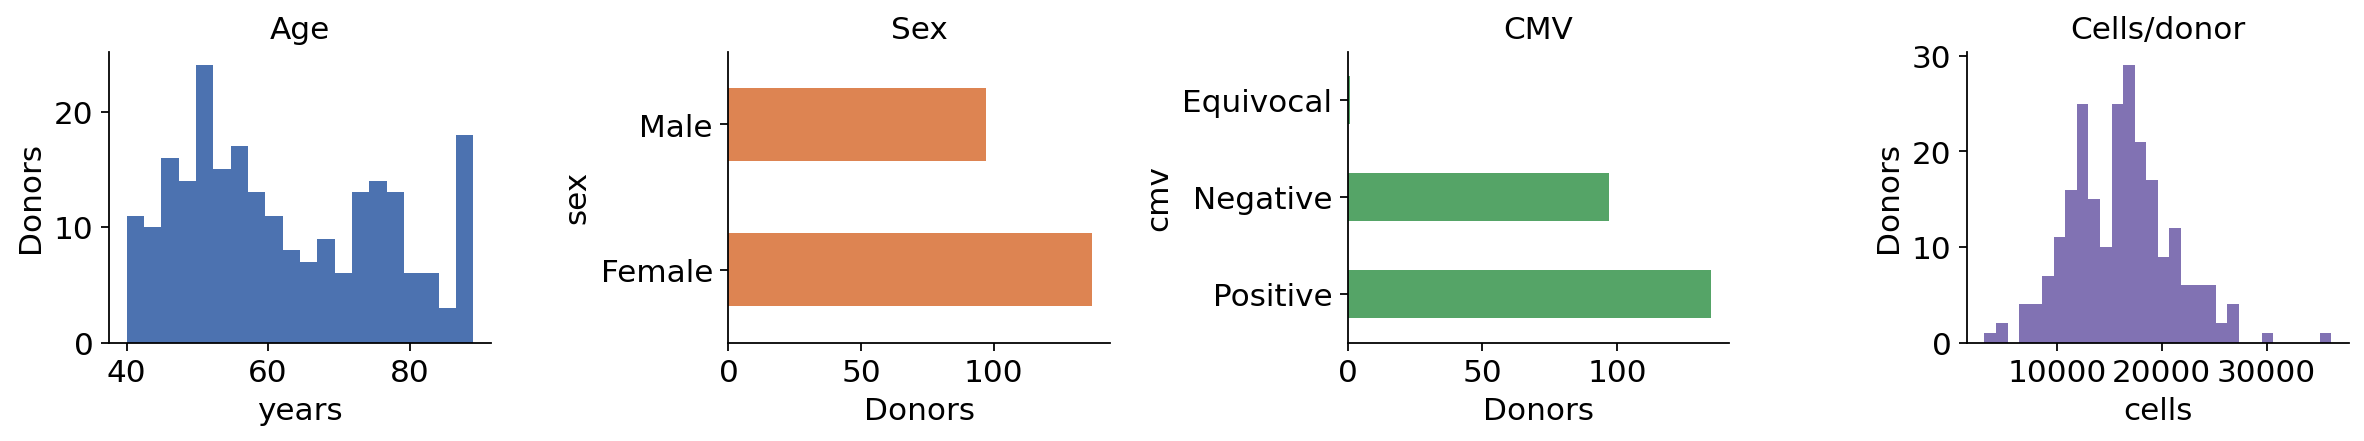

In [4]:
# Build a donor-level metadata table; we re-use it for every method below.
def donor_meta_from(adata, age_col="age", sample_col="donor",
                    keep=("subject.biologicalSex", "subject.cmv", "subject.race", "batch_id", "pool_id", "chip_id", "AIFI_L2")):
    cols = [sample_col, age_col, "age_group"] + [c for c in keep if c in adata.obs.columns]
    return adata.obs[cols].copy().groupby(sample_col, observed=True).agg(
        age=("age", "first"),
        age_group=("age_group", "first"),
        sex=("subject.biologicalSex", "first"),
        cmv=("subject.cmv", "first"),
        race=("subject.race", "first"),
        batch=("batch_id", "first"),
        pool=("pool_id", "first"),
        chip=("chip_id", "first"),
        n_cells=("AIFI_L2", "size"),
    )

donor_meta = donor_meta_from(adata)
print(donor_meta.head())

# Cohort overview: age + cells/donor as histograms, sex + CMV as horizontal bars
# (horizontal bars keep the category labels readable).
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes[0].hist(donor_meta.age, bins=20, color="#4C72B0")
axes[0].set_title("Age"); axes[0].set_xlabel("years"); axes[0].set_ylabel("Donors")
donor_meta.sex.value_counts().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Sex"); axes[1].set_xlabel("Donors")
donor_meta.cmv.value_counts().plot(kind="barh", ax=axes[2], color="#55A467")
axes[2].set_title("CMV"); axes[2].set_xlabel("Donors")
axes[3].hist(donor_meta.n_cells, bins=30, color="#8172B3")
axes[3].set_title("Cells/donor"); axes[3].set_xlabel("cells"); axes[3].set_ylabel("Donors")
despine(*axes)
plt.tight_layout(); plt.show()


In [5]:
adata.obs.columns

Index(['cohort.cohortGuid', 'subject.subjectGuid', 'sample.sampleKitGuid',
       'specimen.specimenGuid', 'subject.biologicalSex',
       'subject.ageAtFirstDraw', 'subject.race', 'subject.ethnicity',
       'subject.cmv', 'sample.visitName', 'sample.subjectAgeAtDraw',
       'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes',
       'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes',
       'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1',
       'predicted_AIFI_L1', 'AIFI_L2', 'predicted_AIFI_L2', 'AIFI_L3',
       'predicted_AIFI_L3', 'cell_population_file', 'age', 'age_group',
       'donor'],
      dtype='object')

### Pre-existing biology: composition shifts with age

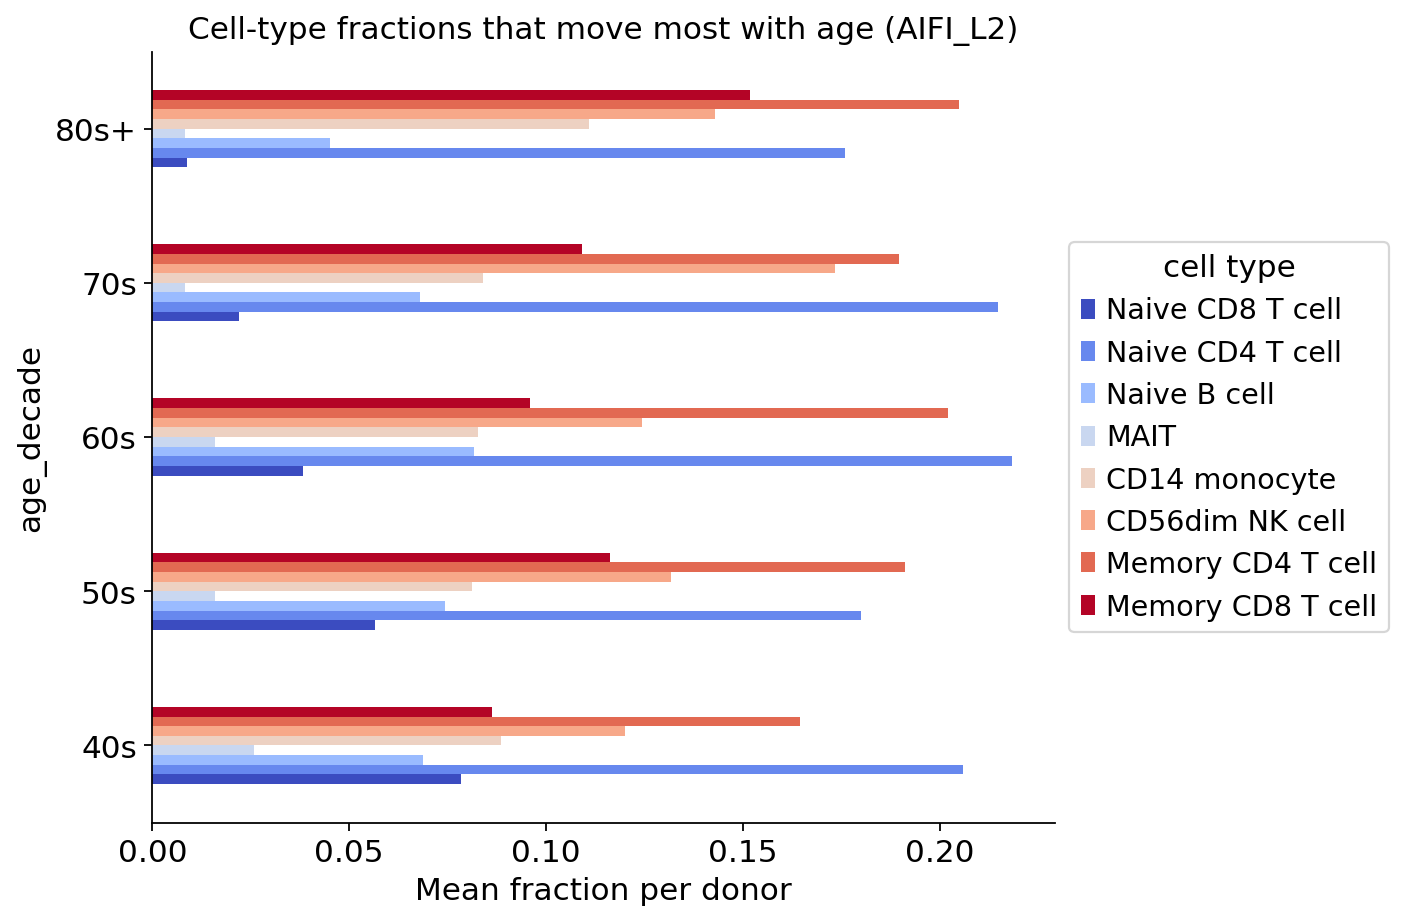

In [6]:
# Per-donor AIFI_L2 fractions, then mean by age decade.
celltype_fractions = pd.crosstab(
    adata.obs["donor"].astype(str), adata.obs["AIFI_L2"].astype(str), normalize="index"
)
donor_meta["age_decade"] = pd.cut(
    donor_meta.age, bins=[39, 50, 60, 70, 80, 90],
    labels=["40s", "50s", "60s", "70s", "80s+"], right=False,
)
fraction_by_decade = (
    celltype_fractions.join(donor_meta["age_decade"])
    .groupby("age_decade", observed=True)
    .mean()
)
fraction_change = (fraction_by_decade.iloc[-1] - fraction_by_decade.iloc[0]).sort_values()
top_movers = list(fraction_change.head(4).index) + list(fraction_change.tail(4).index)

ax = fraction_by_decade.loc[:, top_movers].plot(kind="barh", colormap="coolwarm", figsize=(9, 6))
ax.set_xlabel("Mean fraction per donor"); ax.set_xlim(0, None)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="cell type")
ax.set_title("Cell-type fractions that move most with age (AIFI_L2)")
despine(ax)
plt.tight_layout(); plt.show()


## Shared utilities

Most of the work is the same for every method: filter small donors, pick
a train/test donor split, fit the method, compute a held-out K-NN
regression of age, score the technical / biological covariates. We
define the helpers once.

In [7]:
def filter_and_subsample(adata, sample_size_threshold=200, max_cells_per_donor=None, seed=SEED):
    """Drop donors below ``sample_size_threshold`` cells; optionally cap cells per donor."""
    filtered = patpy.pp.filter_small_samples(
        adata, sample_key="donor", sample_size_threshold=sample_size_threshold
    )
    if max_cells_per_donor is None:
        return filtered

    rng = np.random.default_rng(seed)
    cells_by_donor = (
        pd.Series(filtered.obs["donor"].values)
        .groupby(filtered.obs["donor"].values, observed=True)
        .indices
    )
    kept_cells = []
    for cell_indices in cells_by_donor.values():
        if len(cell_indices) <= max_cells_per_donor:
            kept_cells.append(cell_indices)
        else:
            kept_cells.append(rng.choice(cell_indices, size=max_cells_per_donor, replace=False))
    return filtered[np.sort(np.concatenate(kept_cells))].copy()


def smoke_subset(adata, n_donors=20, max_cells_per_donor=200, seed=SEED):
    """Restrict an AnnData to a small random set of donors (for SMOKE runs)."""
    rng = np.random.default_rng(seed)
    donors = pd.unique(adata.obs["donor"].astype(str))
    donors = donors[rng.permutation(len(donors))[:n_donors]]
    subset = adata[adata.obs["donor"].astype(str).isin(donors)].copy()
    return filter_and_subsample(subset, sample_size_threshold=0, max_cells_per_donor=max_cells_per_donor)


if SMOKE:
    # adata was loaded with smoke=True above, already restricted to ~20 donors.
    # Now cap cells per donor.
    adata = filter_and_subsample(adata, sample_size_threshold=0, max_cells_per_donor=N_CELLS_PER_DONOR)
    donor_meta = donor_meta_from(adata)
    print(f"smoke subset: n_cells={adata.n_obs:,}  n_donors={adata.obs['donor'].nunique()}")


In [8]:
def donor_train_test_split(donors, seed=SEED, test_fraction=TEST_FRACTION):
    """Split donor IDs into train / test lists with a fixed seed."""
    rng = np.random.default_rng(seed)
    donors = np.asarray(donors)
    shuffled = rng.permutation(len(donors))
    n_test = max(1, round(len(donors) * test_fraction))
    test_set = set(donors[shuffled[:n_test]].tolist())
    train = [donor for donor in donors if donor not in test_set]
    test = [donor for donor in donors if donor in test_set]
    return train, test


def probe_metrics(probe_result):
    """Pull the standard regression metrics out of a ``fit_linear_probe`` result."""
    return {metric: probe_result[metric] for metric in ("r2", "spearman", "pearson", "mae")}


def linear_probe_score(embedding, target_per_sample, train_labels, test_labels):
    """Fit a Ridge linear probe on an embedding and score held-out samples.

    Mirrors ``BaseSampleMethod.fit_linear_probe`` for embeddings that don't live
    on a patpy method instance (e.g. SampleCLR's external sample representations).
    """
    from sklearn.linear_model import Ridge

    target = pd.Series(target_per_sample).astype(float)
    probe = Ridge(alpha=0.1)
    probe.fit(embedding.loc[train_labels].values, target.reindex(train_labels).values)
    predicted = probe.predict(embedding.loc[test_labels].values)
    return patpy.tl.evaluate_regression(target.reindex(test_labels).values, predicted)


def score_distance_knn(distances, target_per_sample, sample_order,
                       n_neighbors=N_NEIGHBORS, age_floor=None):
    """KNN regression of a continuous target on a precomputed distance matrix.

    Uses patpy's leave-one-out KNN (``predict_knn`` fills the diagonal to avoid
    self-prediction) and scores with ``evaluate_regression``. Suitable for
    distance-only methods such as GloScope that have no sample embedding to feed
    a linear probe.
    """
    target = pd.Series(target_per_sample).reindex(sample_order).astype(float).values
    known = np.isfinite(target)
    distances = np.asarray(distances, dtype=float)[np.ix_(known, known)]
    y_true = target[known]
    y_pred = patpy.tl.predict_knn(distances.copy(), y_true, n_neighbors=n_neighbors, task="regression")
    if age_floor is not None:
        keep = y_true >= age_floor
        y_true, y_pred = y_true[keep], y_pred[keep]
    return patpy.tl.evaluate_regression(y_true, y_pred)


def classical_mds(distances, n_components=16):
    """Classical (Torgerson) MDS embedding of a square distance matrix."""
    distances = np.asarray(distances, dtype=np.float64)
    n_samples = distances.shape[0]
    centering = np.eye(n_samples) - np.ones((n_samples, n_samples)) / n_samples
    gram = -0.5 * centering @ (distances**2) @ centering
    eigenvalues, eigenvectors = np.linalg.eigh(gram)
    top = np.argsort(-eigenvalues)[:n_components]
    return eigenvectors[:, top] * np.sqrt(np.clip(eigenvalues[top], 0, None))


donor_order = list(pd.unique(adata.obs["donor"].astype(str)))
train_donors, test_donors = donor_train_test_split(donor_order, seed=SEED)
print(f"split: train={len(train_donors)} test={len(test_donors)}")


split: train=187 test=47


## Method 1 — Pseudobulk

Mean of the cell-level `X_pca` embedding within each donor, Euclidean
distance between those means. Cheap, interpretable, ignores
within-donor heterogeneity.

In [9]:
# Pseudobulk: mean of the per-cell X_pca embedding per donor. We score age with
# patpy's built-in linear probe (Ridge) on the held-out test donors.
t0 = time.time()
pseudobulk = patpy.tl.Pseudobulk(sample_key="donor", cell_group_key="AIFI_L2", layer="X_pca", seed=SEED)
pseudobulk.prepare_anndata(adata)
dist_pb = pseudobulk.calculate_distance_matrix()
emb_pb = pd.DataFrame(pseudobulk.sample_representation, index=pseudobulk.samples)

score_pb = probe_metrics(pseudobulk.fit_linear_probe("age", task="regression", test_sample_labels=test_donors))
print(f"pseudobulk: {time.time()-t0:.1f}s  R²={score_pb['r2']:.3f}  Spearman={score_pb['spearman']:.3f}  MAE={score_pb['mae']:.2f}")


pseudobulk: 16.0s  R²=0.557  Spearman=0.822  MAE=7.23


## Method 2 — Cell-group composition (CLR)

In [10]:
# Cell-group composition (CLR): the centred-log-ratio of per-donor cell-type
# fractions. Same linear-probe scoring as pseudobulk.
t0 = time.time()
composition = patpy.tl.CellGroupComposition(
    sample_key="donor", cell_group_key="AIFI_L2", apply_clr=True, seed=SEED
)
composition.prepare_anndata(adata)
dist_comp = composition.calculate_distance_matrix()
representation = composition.sample_representation
emb_comp = representation if isinstance(representation, pd.DataFrame) else pd.DataFrame(representation, index=composition.samples)

score_comp = probe_metrics(composition.fit_linear_probe("age", task="regression", test_sample_labels=test_donors))
print(f"composition (CLR): {time.time()-t0:.1f}s  R²={score_comp['r2']:.3f}  Spearman={score_comp['spearman']:.3f}  MAE={score_comp['mae']:.2f}")


composition (CLR): 1.3s  R²=0.355  Spearman=0.600  MAE=7.78


## Method 3 — GloScope (Python)

In [11]:
# GloScope: symmetric KL divergence between donor-level cell-state distributions.
# It produces distances, not an embedding, so there is nothing to feed a linear
# probe; we score age by KNN on the KL distances (patpy.tl.predict_knn).
t0 = time.time()
gloscope_subset = filter_and_subsample(adata, sample_size_threshold=0, max_cells_per_donor=N_CELLS_PER_DONOR)
gloscope = patpy.tl.GloScope_py(sample_key="donor", cell_group_key="AIFI_L2", layer="X_pca", k=25, seed=SEED)
gloscope.prepare_anndata(gloscope_subset)
distances = gloscope.calculate_distance_matrix()
dist_gs = (distances.values if isinstance(distances, pd.DataFrame) else np.asarray(distances)).astype(np.float32)
gloscope_samples = list(distances.index) if isinstance(distances, pd.DataFrame) else list(gloscope.samples)

# Classical-MDS coordinates only feed the joint UMAP visualisation further down.
emb_gs = pd.DataFrame(classical_mds(dist_gs, n_components=16), index=gloscope_samples)

score_gs = score_distance_knn(dist_gs, donor_meta["age"], gloscope_samples)
print(f"GloScope_py: {time.time()-t0:.1f}s  R²={score_gs['r2']:.3f}  Spearman={score_gs['spearman']:.3f}  MAE={score_gs['mae']:.2f}")


0 samples removed: 


GloScope_py: 640.7s  R²=0.061  Spearman=0.365  MAE=10.66


SampleCLR trains a contrastive aggregator over cell embeddings. We snapshot the
donor embedding at the **SSL** stage (after self-supervised pretrain, no labels)
and after **fine-tuning** on age. The SSL stage has no supervised head, so we
score it with a linear probe; the fine-tuned model has a trained age head, so we
read its prediction directly (`predict`). We also pull per-cell attention weights
for the deeper analysis below.

The `use_batch_aware_sampler` flag tells the contrastive loss to balance
sequencing batches when forming positive/negative pairs — useful when the
technical batches are confounded with biology. We use a `relu` attention
activation; the saturating sigmoid default underweights informative cells.


In [12]:
def fit_sampleclr(adata):
    """Train SampleCLR; snapshot the donor embedding after SSL and after fine-tuning."""
    from sampleclr import ContrastiveModel
    from sampleclr.utils import get_sample_representations_from_adata

    subset = filter_and_subsample(adata, sample_size_threshold=0, max_cells_per_donor=N_CELLS_PER_DONOR)
    sample_order = list(pd.unique(subset.obs["donor"].astype(str)))
    n_epochs = 10 if SMOKE else 40
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = ContrastiveModel(
        adata=subset, sample_key="donor", layer="X_pca",
        tasks={"regression": ["age"]},
        batch_size=8,
        num_epochs_stage1=n_epochs, num_epochs_stage2=n_epochs,
        num_warmup_epochs_stage1=max(1, n_epochs // 5),
        num_warmup_epochs_stage2=max(1, n_epochs // 5),
        early_stopping_patience=3 if SMOKE else 8,
        aggregator_activation="relu",   # relu beats the saturating sigmoid default
        use_batch_aware_sampler=True,
        batch_sampler_batch_col="batch_id",
        verbose=False, seed=SEED,
    )

    def embed(donors):
        representation = get_sample_representations_from_adata(
            projector=model.projector, aggregator=model.aggregator,
            adata=subset, sample_key="donor", layer="X_pca",
            meta_obs_names=donors, subset_size=N_CELLS_PER_DONOR, device=device,
        )
        embedding = pd.DataFrame(np.asarray(representation), index=donors)
        distances = squareform(pdist(embedding.values, metric="euclidean")).astype(np.float32)
        return embedding, distances

    # SSL snapshot (after self-supervised pretrain, before fine-tuning on age).
    model.pretrain()
    emb_ssl, dist_ssl = embed(sample_order)

    # FT snapshot (after supervised fine-tuning on age).
    model.fine_tune(val_metric="loss")
    emb_ft, dist_ft = embed(sample_order)
    return model, subset, emb_ssl, dist_ssl, emb_ft, dist_ft


def predict_age_sampleclr(model, adata, donors, layer="X_pca", subset_size=N_CELLS_PER_DONOR):
    """Predict donor age with SampleCLR's fitted regression head.

    Runs each donor's cells through projector -> aggregator (the sample
    representation) and then the trained "age" regression head, undoing the
    z-scoring SampleCLR applies to regression targets during training.
    """
    from sampleclr.utils import get_sample_representations_from_adata

    device = "cuda" if torch.cuda.is_available() else "cpu"
    representation = get_sample_representations_from_adata(
        projector=model.projector, aggregator=model.aggregator,
        adata=adata, sample_key="donor", layer=layer,
        meta_obs_names=list(donors), subset_size=subset_size, device=device,
    )
    features = torch.tensor(np.asarray(representation), dtype=torch.float32, device=device)
    # The regressor saw the same projector output the contrastive loss did; match
    # its normalisation when the cosine loss is in use.
    if getattr(model, "contrastive_loss", None) == "InfoNCECosine":
        features = torch.nn.functional.normalize(features, dim=-1)
    regressor = model.regressors[model.regression_tasks.index("age")].to(device).eval()
    with torch.no_grad():
        z_scored = regressor(features).squeeze(-1).cpu().numpy()
    age = z_scored * model.regression_target_stds["age"] + model.regression_target_means["age"]
    return pd.Series(age, index=list(donors), name="age")


t0 = time.time()
sclr_model, sclr_adata, emb_ssl, dist_ssl, emb_ft, dist_ft = fit_sampleclr(adata)

# SSL has no supervised head yet -> score with a linear probe on the embedding.
score_ssl = linear_probe_score(emb_ssl, donor_meta["age"], train_donors, test_donors)
# FT has a trained age head -> use it directly (predict) on the held-out donors.
age_pred_ft = predict_age_sampleclr(sclr_model, sclr_adata, test_donors)
score_ft = patpy.tl.evaluate_regression(
    donor_meta["age"].reindex(test_donors).astype(float).values, age_pred_ft.values
)
print(f"SampleCLR: {time.time()-t0:.1f}s")
print(f"  SSL (linear probe) R²={score_ssl['r2']:.3f}  Spearman={score_ssl['spearman']:.3f}  MAE={score_ssl['mae']:.2f}")
print(f"  FT (predict head)  R²={score_ft['r2']:.3f}  Spearman={score_ft['spearman']:.3f}  MAE={score_ft['mae']:.2f}")


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0 samples removed: 


Stage 1: Contrastive-only training (pretrain)


Epoch 1/40 - Loss: 0.0211, Contr: 0.0210, Top1: 1.000, Top5: 1.000 | Time: 21.43s (30 batches, 626.3ms/batch)


Epoch 2/40 - Loss: 0.0141, Contr: 0.0140, Top1: 1.000, Top5: 1.000 | Time: 0.38s (30 batches, 7.5ms/batch)


...


Epoch 37/40 | Time: 0.42s (30 batches, 8.9ms/batch)
contrastive – train: 0.0010 – val: N/A
regression (age) – train: 0.3057 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 38/40 | Time: 0.40s (30 batches, 8.3ms/batch)
contrastive – train: 0.0012 – val: N/A
regression (age) – train: 0.3256 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 39/40 | Time: 0.40s (30 batches, 8.2ms/batch)
contrastive – train: 0.0008 – val: N/A
regression (age) – train: 0.3594 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 40/40 | Time: 0.40s (30 batches, 8.3ms/batch)
contrastive – train: 0.0007 – val: N/A
regression (age) – train: 0.3154 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------


SampleCLR: 152.6s
  SSL (linear probe) R²=-0.982  Spearman=0.454  MAE=13.01
  FT (predict head)  R²=0.936  Spearman=0.972  MAE=2.62


## Method 5 — PaSCient

A cell→patient attention transformer trained end-to-end on continuous age.
PaSCient expects **log-normalised gene expression**, so we feed it `adata.X`
(HVG, log-normalised) directly rather than the PCA embedding the other methods
consume. Two guardrails for the regression setup:

- `tasks=["regression"]` (the patpy wrapper swaps in MSELoss and z-scores the
  target so the loss doesn't explode against raw ages);
- `normalize=False`: `adata.X` is already log-normalised, so PaSCient must not
  log-transform it a second time.

We read predictions straight from PaSCient's native regression head via
`predict("age")`. PaSCient is GPU-preferred; it falls back to CPU but takes
5-10× longer.


In [13]:
def fit_pascient(adata):
    subset = filter_and_subsample(adata, sample_size_threshold=0, max_cells_per_donor=N_CELLS_PER_DONOR)
    cells_per_donor = max(1, subset.n_obs // max(1, subset.obs["donor"].nunique()))
    pascient = patpy.tl.PaSCient(
        sample_key="donor", label_keys=["age"], tasks=["regression"],
        cell_group_key="AIFI_L2",
        layer=None,                # adata.X holds log-normalised counts — PaSCient's expected input
        n_cells=min(N_CELLS_PER_DONOR, cells_per_donor),
        batch_size=16 if torch.cuda.is_available() else 8,
        n_epochs=2 if SMOKE else 30,
        device="cuda" if torch.cuda.is_available() else "cpu",
        normalize=False,           # already log-normalised; don't log() a second time
        seed=SEED,
    )
    pascient.prepare_anndata(subset, train=True)
    return pascient

t0 = time.time()
pascient = fit_pascient(adata)
emb_pa = pascient.get_sample_representations()
dist_pa = squareform(pdist(emb_pa.values, metric="euclidean")).astype(np.float32)

# PaSCient has a native age regression head -> predict directly. We report on the
# held-out donors so the number lines up with the unsupervised methods (note that
# supervised models did see those donors' ages during training).
age_pred_pa = pascient.predict("age")
held_out = age_pred_pa.index.isin(test_donors)
score_pa = patpy.tl.evaluate_regression(
    donor_meta["age"].reindex(age_pred_pa.index[held_out]).astype(float).values,
    age_pred_pa.values[held_out],
)
print(f"PaSCient: {time.time()-t0:.1f}s  R²={score_pa['r2']:.3f}  Spearman={score_pa['spearman']:.3f}  MAE={score_pa['mae']:.2f}")


0 samples removed: 


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA A100-PCIE-40GB MIG 3g.20gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...

Trainable params: 5.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.9 M                                                                                                
Total estimated model params size (MB): 23                                                                         
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=30` reached.


PaSCient: 605.6s  R²=0.888  Spearman=0.950  MAE=1.50


## Method 6 — MixMIL

Mixed model + multiple instance learning. The upstream `mixmil` library only
offers binomial / categorical likelihoods, so its native head is trained on the
binary `age_group = age >= 65`. To get a *continuous* age prediction we attach a
regression **linear probe** on top of MixMIL's donor embedding
(`fit_linear_probe("age", task="regression", store=True)`) and read it back
through the same `predict("age")` interface used by the other supervised methods.
The probe is fit on the train donors and scored on the held-out donors.


In [14]:
def fit_mixmil(adata):
    subset = filter_and_subsample(adata, sample_size_threshold=0, max_cells_per_donor=N_CELLS_PER_DONOR)
    mixmil = patpy.tl.MixMIL(
        sample_key="donor", label_keys=["age_group"], tasks=["classification"],
        cell_group_key="AIFI_L2", layer="X_pca",
        likelihood="binomial", n_trials=2,
        n_epochs=200 if SMOKE else 1500,
        batch_size=8, seed=SEED,
    )
    mixmil.prepare_anndata(subset, train=True)
    return mixmil

t0 = time.time()
mixmil = fit_mixmil(adata)
emb_mm = mixmil.get_sample_representations()
dist_mm = squareform(pdist(emb_mm.values, metric="euclidean")).astype(np.float32)

# MixMIL's native likelihood is binomial, so it cannot regress continuous age.
# We instead train a regression linear probe on its donor embedding (fit on the
# train donors, evaluated on the held-out test donors) and expose it through
# predict("age").
score_mm = probe_metrics(
    mixmil.fit_linear_probe("age", task="regression", test_sample_labels=test_donors, store=True)
)
age_pred_mm = mixmil.predict("age")  # continuous age, served by the stored probe
print(f"MixMIL: {time.time()-t0:.1f}s  R²={score_mm['r2']:.3f}  Spearman={score_mm['spearman']:.3f}  MAE={score_mm['mae']:.2f}")
print(f"  predict('age') head now returns continuous values, e.g. {age_pred_mm.iloc[:3].round(1).to_dict()}")


0 samples removed: 


Epoch:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch:   0%|          | 1/1500 [00:05<2:13:11,  5.33s/it]

Epoch:   0%|          | 2/1500 [00:05<1:01:11,  2.45s/it]

Epoch:   0%|          | 3/1500 [00:06<37:31,  1.50s/it]  

...

Epoch: 100%|█████████▉| 1498/1500 [05:16<00:00,  5.22it/s]

Epoch: 100%|█████████▉| 1499/1500 [05:16<00:00,  5.22it/s]

Epoch: 100%|██████████| 1500/1500 [05:16<00:00,  5.21it/s]

Epoch: 100%|██████████| 1500/1500 [05:16<00:00,  4.74it/s]

MixMIL: 360.0s  R²=0.288  Spearman=0.477  MAE=9.42
  predict('age') head now returns continuous values, e.g. {'SF3001': 59.79999923706055, 'SF3006': 49.20000076293945, 'SF3016': 59.29999923706055}


## Cross-method comparison on the aging cohort

                  r2  spearman  pearson     mae
pseudobulk     0.557     0.822    0.785   7.233
composition    0.355     0.600    0.623   7.780
gloscope       0.061     0.365    0.362  10.656
sampleclr-SSL -0.982     0.454    0.345  13.006
sampleclr-FT   0.936     0.972    0.970   2.617
pascient       0.888     0.950    0.942   1.497
mixmil         0.288     0.477    0.555   9.420


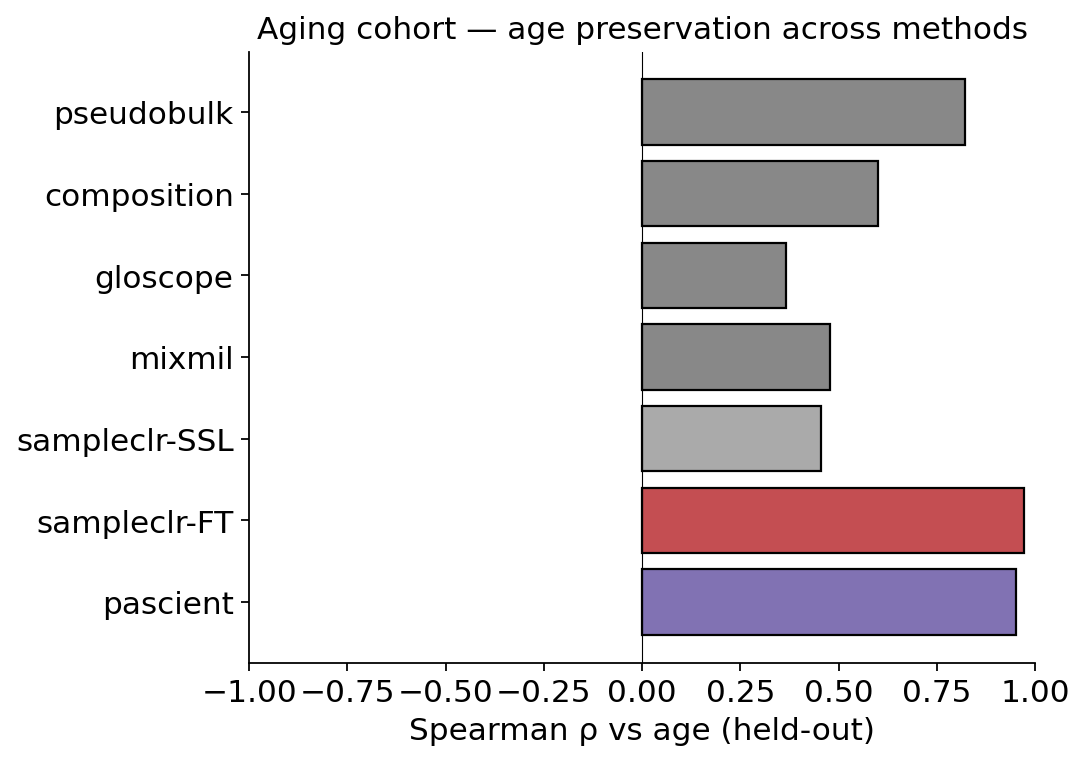

In [15]:
# All methods are scored on the held-out donors with the same regression metrics.
aging_scores = pd.DataFrame(
    {
        "pseudobulk": score_pb,
        "composition": score_comp,
        "gloscope": score_gs,
        "sampleclr-SSL": score_ssl,
        "sampleclr-FT": score_ft,
        "pascient": score_pa,
        "mixmil": score_mm,
    }
).T[["r2", "spearman", "pearson", "mae"]]
print(aging_scores.round(3))

order = ["pseudobulk", "composition", "gloscope", "mixmil", "sampleclr-SSL", "sampleclr-FT", "pascient"]
plot_scores = aging_scores.reindex(order)
colors = ["#888"] * 4 + ["#aaa", "#C44E52", "#8172B3"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(plot_scores.index, plot_scores["spearman"], color=colors, edgecolor="black")
ax.axvline(0, color="k", lw=0.5)
ax.set_xlim(-1, 1)                # Spearman is bounded in [-1, 1]; lock the range
ax.set_xlabel("Spearman ρ vs age (held-out)")
ax.set_title("Aging cohort — age preservation across methods")
ax.invert_yaxis()                 # best method on top
despine(ax)
plt.tight_layout(); plt.show()


## Sample-level embeddings in one AnnData

Each sample-representation method produces a per-donor embedding and a
donor–donor distance matrix. Bundling all of them into a single
**meta_adata** (donors × pseudobulk genes) lets us inspect them
together: a `sc.pp.neighbors` graph per method, a 2-D UMAP per method,
and donor metadata + cell-type compositions sitting in `.obs`.

- ``.X``   — pseudobulk gene expression (mean of cells, log-normalised)
- ``.obsm["X_pb_<cell_type>"]`` — per-cell-type pseudobulk gene expression
- ``.obs``   — donor metadata + per-cell-type fractions (``frac_<cell_type>``)
- ``.obsm[method_name]`` / ``.obsm[method_name+"_distances"]`` / ``.obsm["X_umap_"+method_name]``
  — sample representation, donor–donor distance, UMAP coords for each method
- ``.uns["sample_representations"]`` lists the method names


In [16]:
# --- One per-donor aggregation helper, reused everywhere below ---
def pseudobulk_per_donor(adata, donor_key="donor", layer="X", celltype_key=None):
    """Per-donor mean of a feature matrix.

    Parameters
    ----------
    layer
        ``"X"``/``None`` for ``adata.X``, an ``obsm`` key, or a ``layers`` key.
    celltype_key
        When given, returns a dict ``{cell_type: (n_donors x n_features)}`` of
        per-(donor, cell type) means instead of a single per-donor matrix.

    Returns
    -------
    (donors, matrix) or (donors, {cell_type: matrix})
    """
    donors = list(pd.unique(adata.obs[donor_key].astype(str)))
    donor_of_cell = adata.obs[donor_key].astype(str).values
    if layer in (None, "X"):
        features = adata.X
    elif layer in adata.obsm:
        features = adata.obsm[layer]
    else:
        features = adata.layers[layer]

    def densify(block):
        return np.asarray(block.toarray() if hasattr(block, "toarray") else block, dtype=np.float32)

    if celltype_key is None:
        means = np.zeros((len(donors), features.shape[1]), dtype=np.float32)
        for i, donor in enumerate(donors):
            means[i] = densify(features[donor_of_cell == donor]).mean(axis=0)
        return donors, means

    celltype_of_cell = adata.obs[celltype_key].astype(str).values
    cell_types = list(pd.unique(celltype_of_cell))
    means_by_celltype = {
        cell_type: np.zeros((len(donors), features.shape[1]), dtype=np.float32) for cell_type in cell_types
    }
    for i, donor in enumerate(donors):
        donor_mask = donor_of_cell == donor
        for cell_type in cell_types:
            block = features[donor_mask & (celltype_of_cell == cell_type)]
            if block.shape[0]:
                means_by_celltype[cell_type][i] = densify(block).mean(axis=0)
    return donors, means_by_celltype


# --- Build the donor-level meta AnnData ---
donors_pb, bulk_X = pseudobulk_per_donor(adata, layer="X")
donors_check, bulk_by_celltype = pseudobulk_per_donor(adata, layer="X", celltype_key="AIFI_L2")
assert donors_pb == donors_check

meta_adata = ad.AnnData(X=bulk_X)
meta_adata.var_names = adata.var_names.astype(str)
meta_adata.obs_names = pd.Index(donors_pb)
meta_adata.obs = donor_meta.loc[donors_pb].copy()

for cell_type, celltype_means in bulk_by_celltype.items():
    key = "X_pb_" + str(cell_type).replace(" ", "_").replace("/", "_")
    meta_adata.obsm[key] = celltype_means

fractions = celltype_fractions.reindex(donors_pb).fillna(0.0).astype(np.float32)
fractions.columns = ["frac_" + str(c).replace(" ", "_").replace("/", "_") for c in fractions.columns]
meta_adata.obs = pd.concat([meta_adata.obs, fractions], axis=1)
print(meta_adata)


AnnData object with n_obs × n_vars = 234 × 4000
    obs: 'age', 'age_group', 'sex', 'cmv', 'race', 'batch', 'pool', 'chip', 'n_cells', 'age_decade', 'frac_ASDC', 'frac_CD14_monocyte', 'frac_CD16_monocyte', 'frac_CD56bright_NK_cell', 'frac_CD56dim_NK_cell', 'frac_CD8aa', 'frac_DN_T_cell', 'frac_Effector_B_cell', 'frac_Erythrocyte', 'frac_ILC', 'frac_MAIT', 'frac_Memory_B_cell', 'frac_Memory_CD4_T_cell', 'frac_Memory_CD8_T_cell', 'frac_Naive_B_cell', 'frac_Naive_CD4_T_cell', 'frac_Naive_CD8_T_cell', 'frac_Plasma_cell', 'frac_Platelet', 'frac_Progenitor_cell', 'frac_Proliferating_NK_cell', 'frac_Proliferating_T_cell', 'frac_Transitional_B_cell', 'frac_Treg', 'frac_cDC1', 'frac_cDC2', 'frac_gdT', 'frac_pDC'
    obsm: 'X_pb_Memory_B_cell', 'X_pb_Transitional_B_cell', 'X_pb_Plasma_cell', 'X_pb_Effector_B_cell', 'X_pb_Naive_B_cell', 'X_pb_Treg', 'X_pb_Memory_CD4_T_cell', 'X_pb_Proliferating_T_cell', 'X_pb_Naive_CD4_T_cell', 'X_pb_Memory_CD8_T_cell', 'X_pb_gdT', 'X_pb_CD8aa', 'X_pb_MAIT', 'X_p

In [17]:
# --- Adapter to plug an externally-fitted method into meta_adata. ---
# Mirrors patpy's `store_representation` but takes the embedding, distance matrix
# and sample order directly (so the fit_* cells above don't need to return the
# model object).
from umap import UMAP


def store_representation(meta_adata, sample_representation, distances, samples, method_name, seed=SEED):
    representation = np.asarray(sample_representation, dtype=np.float32)
    distances = np.asarray(distances, dtype=np.float32)
    samples = [str(s) for s in samples]
    obs_names = list(meta_adata.obs_names.astype(str))

    position_of_sample = {sample: i for i, sample in enumerate(samples)}
    missing = [name for name in obs_names if name not in position_of_sample]
    if missing:
        raise RuntimeError(
            f"method {method_name!r} is missing {len(missing)} donors "
            f"(first few: {missing[:3]}). Make sure prepare_anndata was called on the full cohort."
        )
    order = np.array([position_of_sample[name] for name in obs_names])
    meta_adata.obsm[method_name] = representation[order]
    meta_adata.obsm[f"{method_name}_distances"] = distances[np.ix_(order, order)]

    n_neighbors = min(15, len(obs_names) - 1)
    sc.pp.neighbors(meta_adata, use_rep=f"{method_name}_distances",
                    key_added=f"{method_name}_neighbors", metric="precomputed", n_neighbors=n_neighbors)
    coords = UMAP(n_neighbors=n_neighbors, min_dist=0.3, random_state=seed,
                  init="random", metric="precomputed").fit_transform(
        meta_adata.obsm[f"{method_name}_distances"].astype(np.float32)
    )
    meta_adata.obsm[f"X_umap_{method_name}"] = coords.astype(np.float32)

    meta_adata.uns.setdefault("sample_representations", [])
    if method_name not in meta_adata.uns["sample_representations"]:
        meta_adata.uns["sample_representations"].append(method_name)
    return meta_adata


# Each method's (embedding, distance, sample-order) tuple from the cells above.
method_blobs = [
    ("pseudobulk",    emb_pb.values,   dist_pb,   list(emb_pb.index)),
    ("composition",   emb_comp.values, dist_comp, list(emb_comp.index)),
    ("gloscope",      emb_gs.values,   dist_gs,   list(emb_gs.index)),
    ("sampleclr_ssl", emb_ssl.values,  dist_ssl,  list(emb_ssl.index)),
    ("sampleclr_ft",  emb_ft.values,   dist_ft,   list(emb_ft.index)),
    ("pascient",      emb_pa.values,   dist_pa,   list(emb_pa.index)),
    ("mixmil",        emb_mm.values,   dist_mm,   list(emb_mm.index)),
]
for method_name, representation, distances, samples in method_blobs:
    store_representation(meta_adata, representation, distances, samples, method_name)
print("stored:", meta_adata.uns["sample_representations"])


stored: ['pseudobulk', 'composition', 'gloscope', 'sampleclr_ssl', 'sampleclr_ft', 'pascient', 'mixmil']


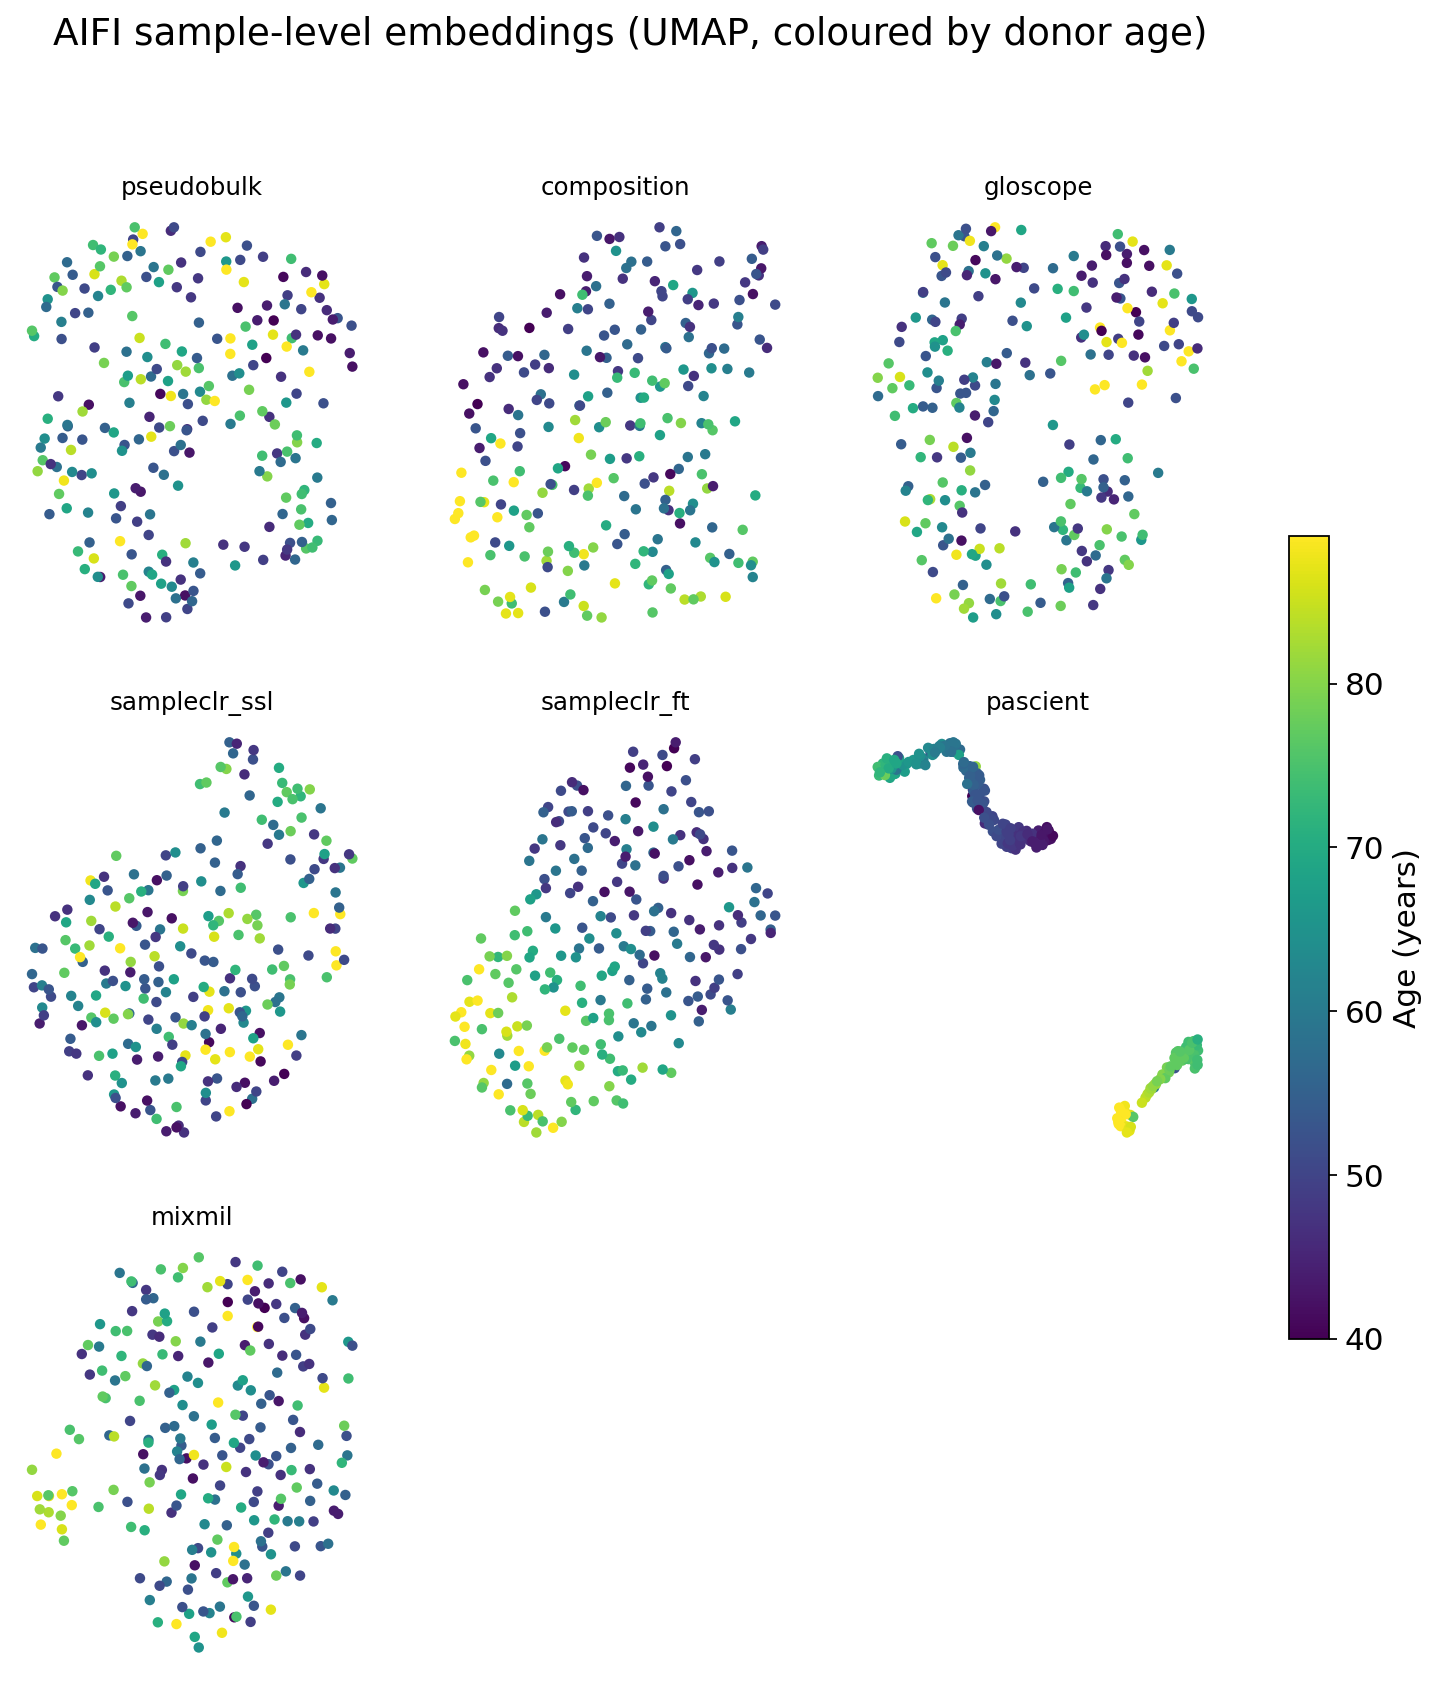

In [18]:
# Grid of UMAPs, one per sample-representation method, coloured by age.
methods = meta_adata.uns["sample_representations"]
ncols = 3
nrows = int(np.ceil(len(methods) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.0, nrows * 4.0), squeeze=False)
donor_ages = meta_adata.obs["age"].astype(float).values
scatter = None
for ax, method in zip(axes.ravel(), methods):
    coords = meta_adata.obsm[f"X_umap_{method}"]
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=donor_ages, cmap="viridis", s=22, edgecolor="none")
    ax.set_title(method, fontsize=11)
    style_umap(ax)
for ax in axes.ravel()[len(methods):]:
    ax.set_visible(False)
fig.colorbar(scatter, ax=axes.ravel().tolist(), shrink=0.55, label="Age (years)")
plt.suptitle("AIFI sample-level embeddings (UMAP, coloured by donor age)", y=1.01)
plt.show()


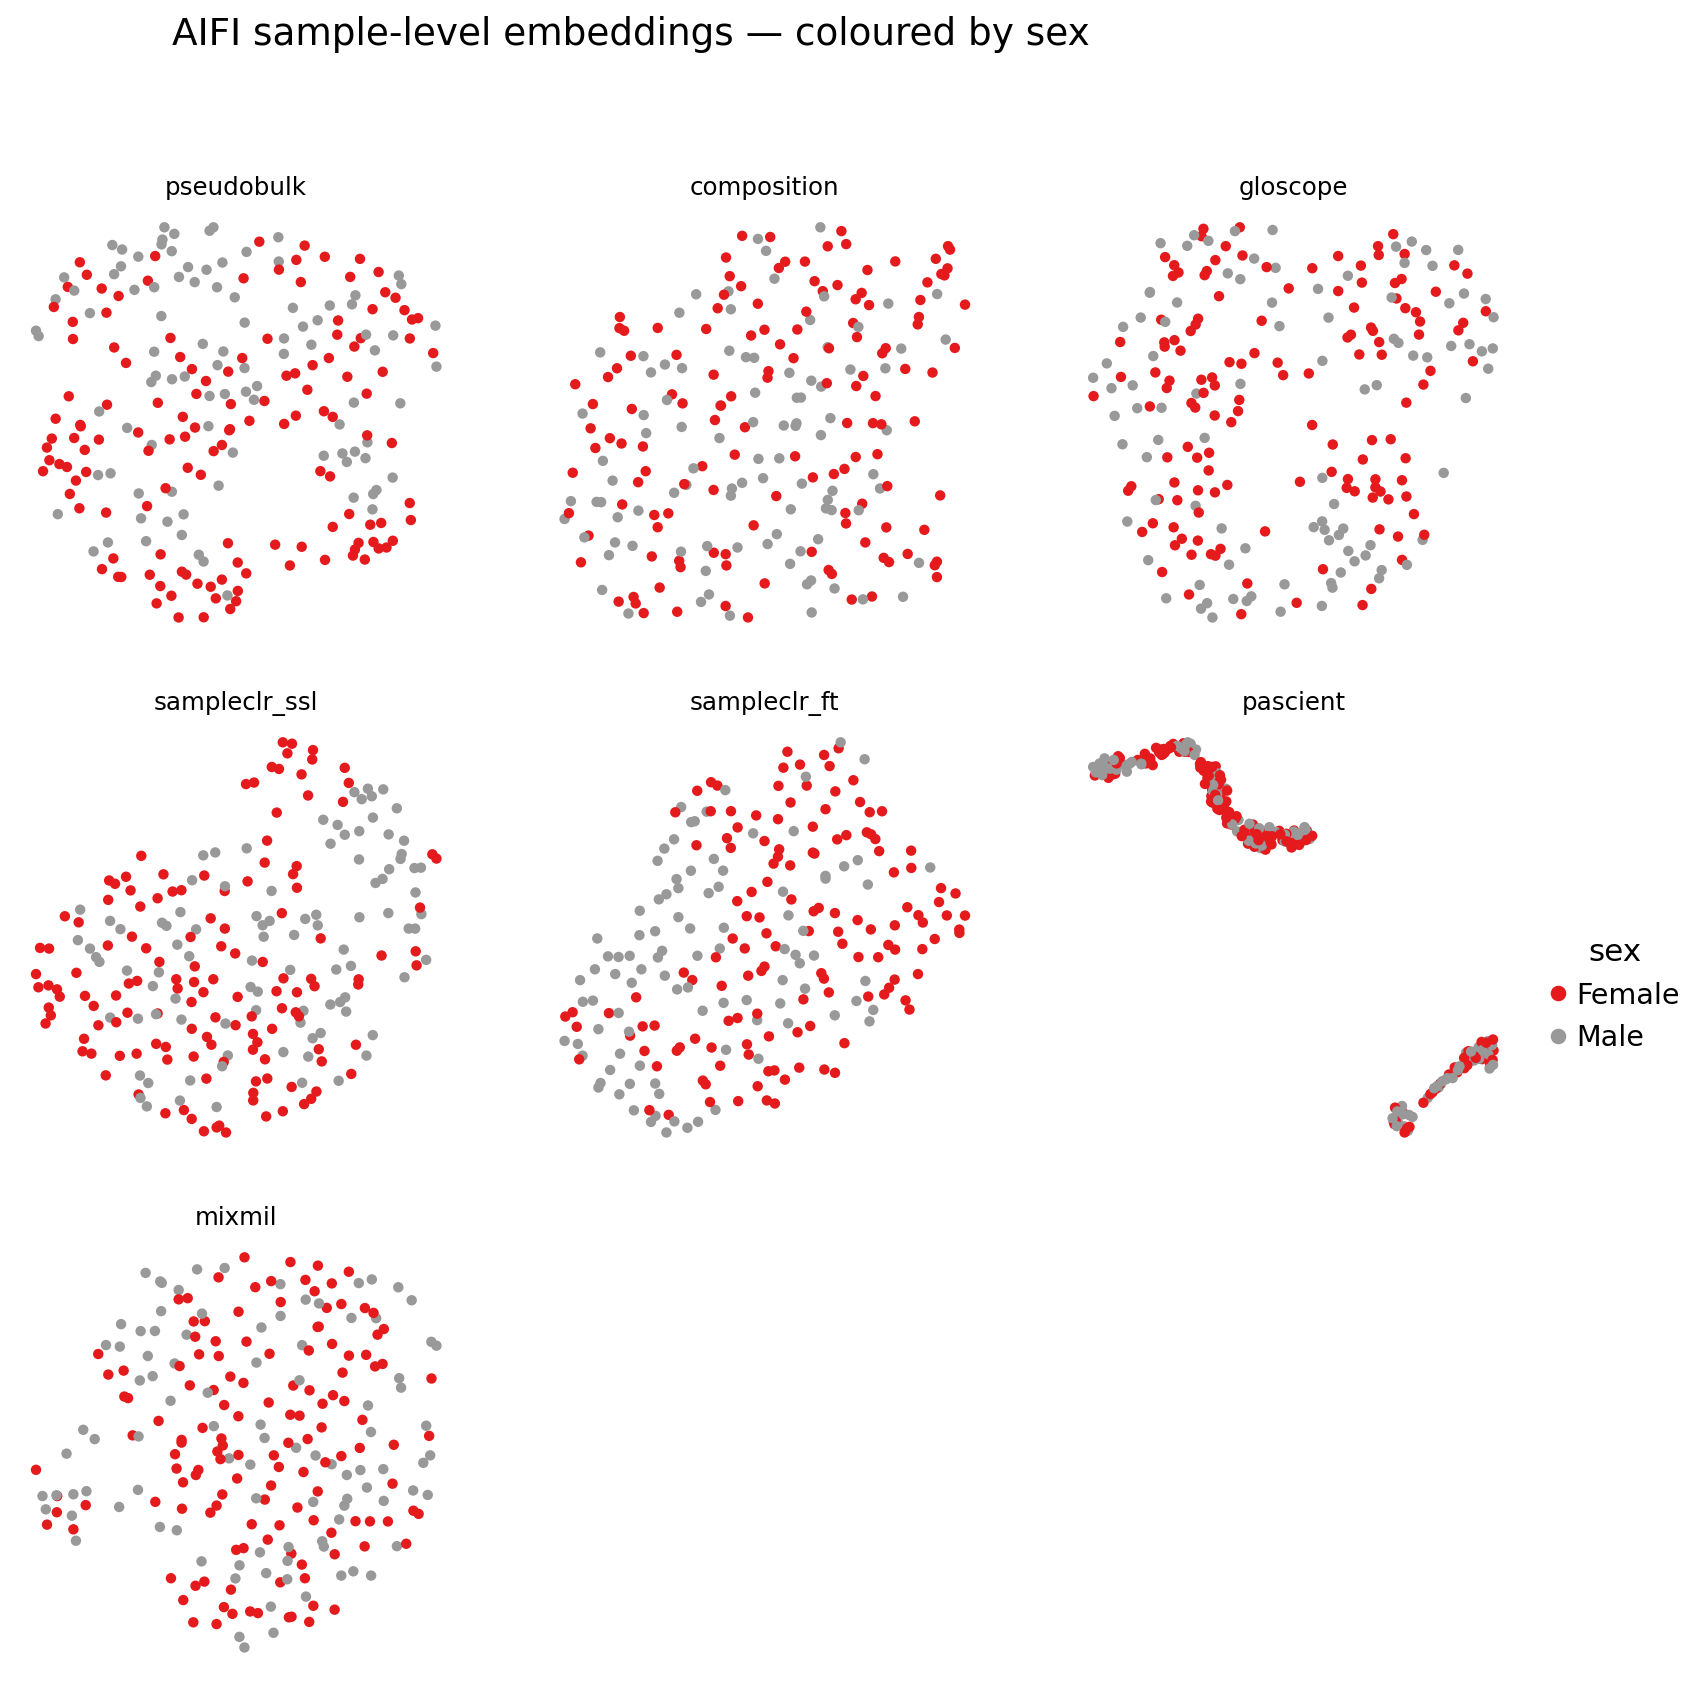

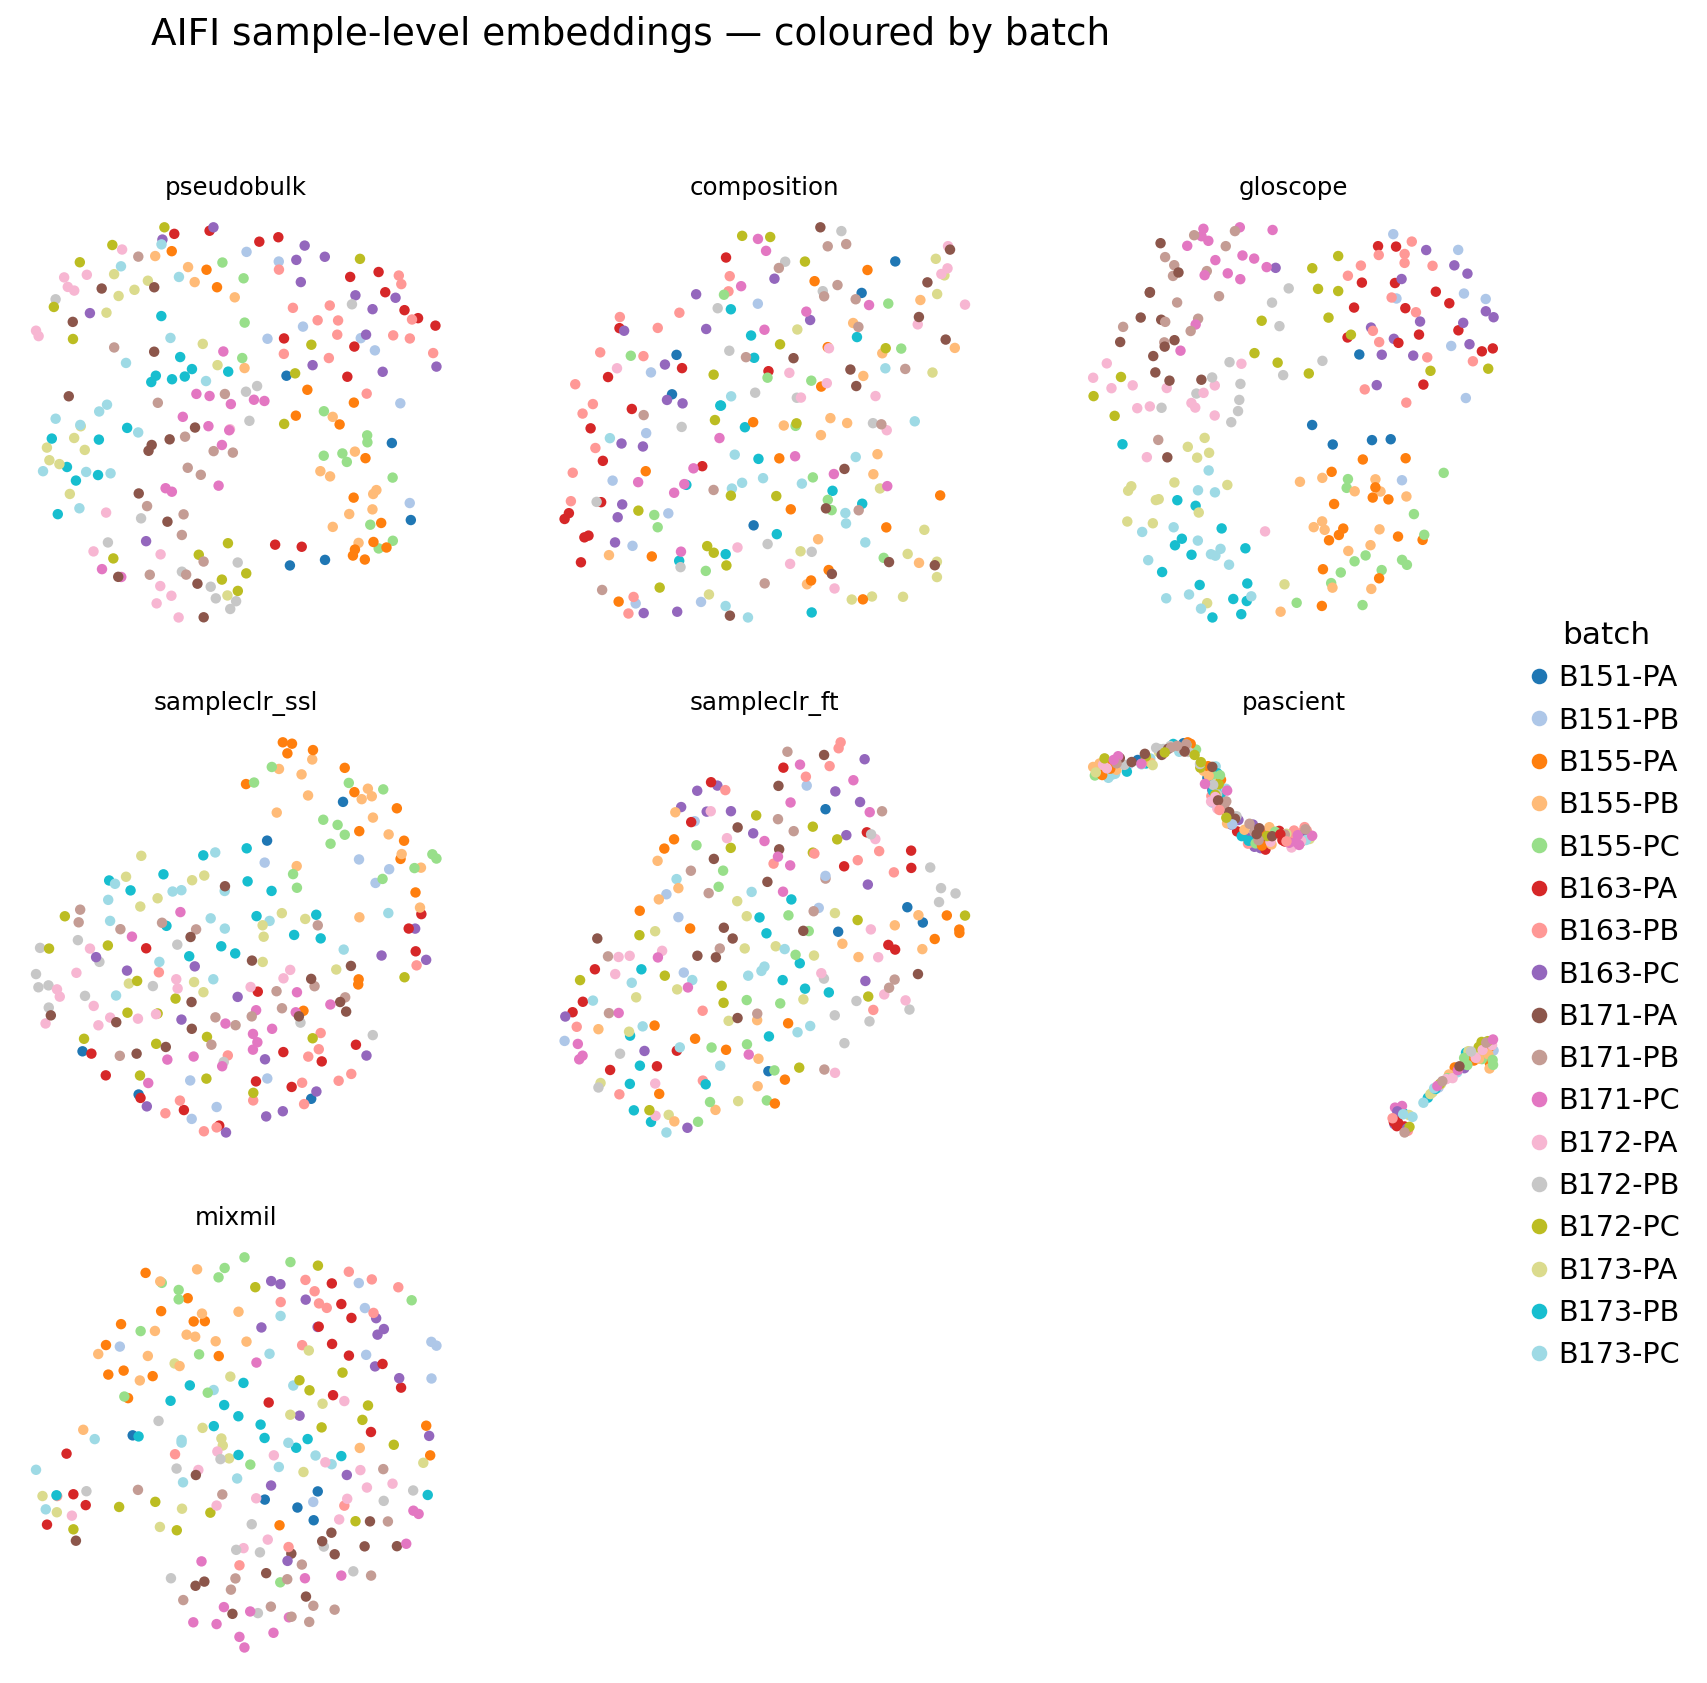

In [19]:
# Same UMAPs, coloured by sex + batch — a quick visual check that the embedding
# isn't *just* picking up technical or demographic batch structure.
covariate_panels = [("sex", "Set1"), ("batch", "tab20")]
for covariate, cmap_name in covariate_panels:
    categories = meta_adata.obs[covariate].astype(str).astype("category")
    palette = plt.get_cmap(cmap_name, max(2, len(categories.cat.categories)))
    category_codes = categories.cat.codes.values
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.0, nrows * 4.0), squeeze=False)
    for ax, method in zip(axes.ravel(), methods):
        coords = meta_adata.obsm[f"X_umap_{method}"]
        ax.scatter(coords[:, 0], coords[:, 1], c=category_codes, cmap=palette, s=22, edgecolor="none")
        ax.set_title(method, fontsize=11)
        style_umap(ax)
    for ax in axes.ravel()[len(methods):]:
        ax.set_visible(False)
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=7,
                   markerfacecolor=palette(i), markeredgecolor="none", label=str(name))
        for i, name in enumerate(categories.cat.categories)
    ]
    fig.legend(handles=handles, loc="center right", title=covariate, frameon=False, bbox_to_anchor=(1.06, 0.5))
    plt.suptitle(f"AIFI sample-level embeddings — coloured by {covariate}", y=1.01)
    plt.show()


### Persist `meta_adata` to disk

All seven sample representations are now bundled into a single
``AnnData``. Writing it to a single `.h5ad` makes the downstream
analyses (biology, sweep, attention) and any future post-hoc work
fast to resume — no need to re-fit every method.


In [20]:
import os
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

# Persist meta_adata: every method's sample representation, distances, UMAP and
# the donor-level pseudobulk / per-cell-type pseudobulk all live in one file.
META_ADATA_DIR = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/"
                       "patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts")
META_ADATA_DIR.mkdir(parents=True, exist_ok=True)
META_ADATA_PATH = META_ADATA_DIR / "aifi_meta_adata.h5ad"

# obs columns with the categorical dtype "category" sometimes need flattening
# for h5ad to accept them. Pre-cast object dtypes to string.
for col in meta_adata.obs.columns:
    if meta_adata.obs[col].dtype == object:
        meta_adata.obs[col] = meta_adata.obs[col].astype(str)

meta_adata.write_h5ad(META_ADATA_PATH)
print(f"meta_adata -> {META_ADATA_PATH}  ({META_ADATA_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"  obs: {list(meta_adata.obs.columns)[:10]}{'...' if meta_adata.obs.shape[1] > 10 else ''}")
print(f"  obsm: {list(meta_adata.obsm.keys())[:8]}{'...' if len(meta_adata.obsm) > 8 else ''}")
print(f"  representations: {meta_adata.uns['sample_representations']}")


meta_adata -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/aifi_meta_adata.h5ad  (111.9 MB)
  obs: ['age', 'age_group', 'sex', 'cmv', 'race', 'batch', 'pool', 'chip', 'n_cells', 'age_decade']...
  obsm: ['X_pb_Memory_B_cell', 'X_pb_Transitional_B_cell', 'X_pb_Plasma_cell', 'X_pb_Effector_B_cell', 'X_pb_Naive_B_cell', 'X_pb_Treg', 'X_pb_Memory_CD4_T_cell', 'X_pb_Proliferating_T_cell']...
  representations: ['pseudobulk', 'composition', 'gloscope', 'sampleclr_ssl', 'sampleclr_ft', 'pascient', 'mixmil']


## Biology: which cell types correlate with age?

Composition (CLR) ignores expression entirely — yet it reaches the
strongest unsupervised score on this cohort. So most of the
predictable variance must live in the cell-type fractions themselves.
We Pearson-correlate each per-donor cell-type fraction with age.

Top cell types DECREASING with age (AIFI):
                      r    p
Naive CD8 T cell -0.615  0.0
CD8aa            -0.415  0.0
MAIT             -0.344  0.0
ILC              -0.250  0.0
Memory B cell    -0.242  0.0

Top cell types INCREASING with age (AIFI):
                       r      p
Platelet           0.123  0.060
Effector B cell    0.123  0.060
Memory CD4 T cell  0.136  0.037
Memory CD8 T cell  0.162  0.013
CD56dim NK cell    0.175  0.007


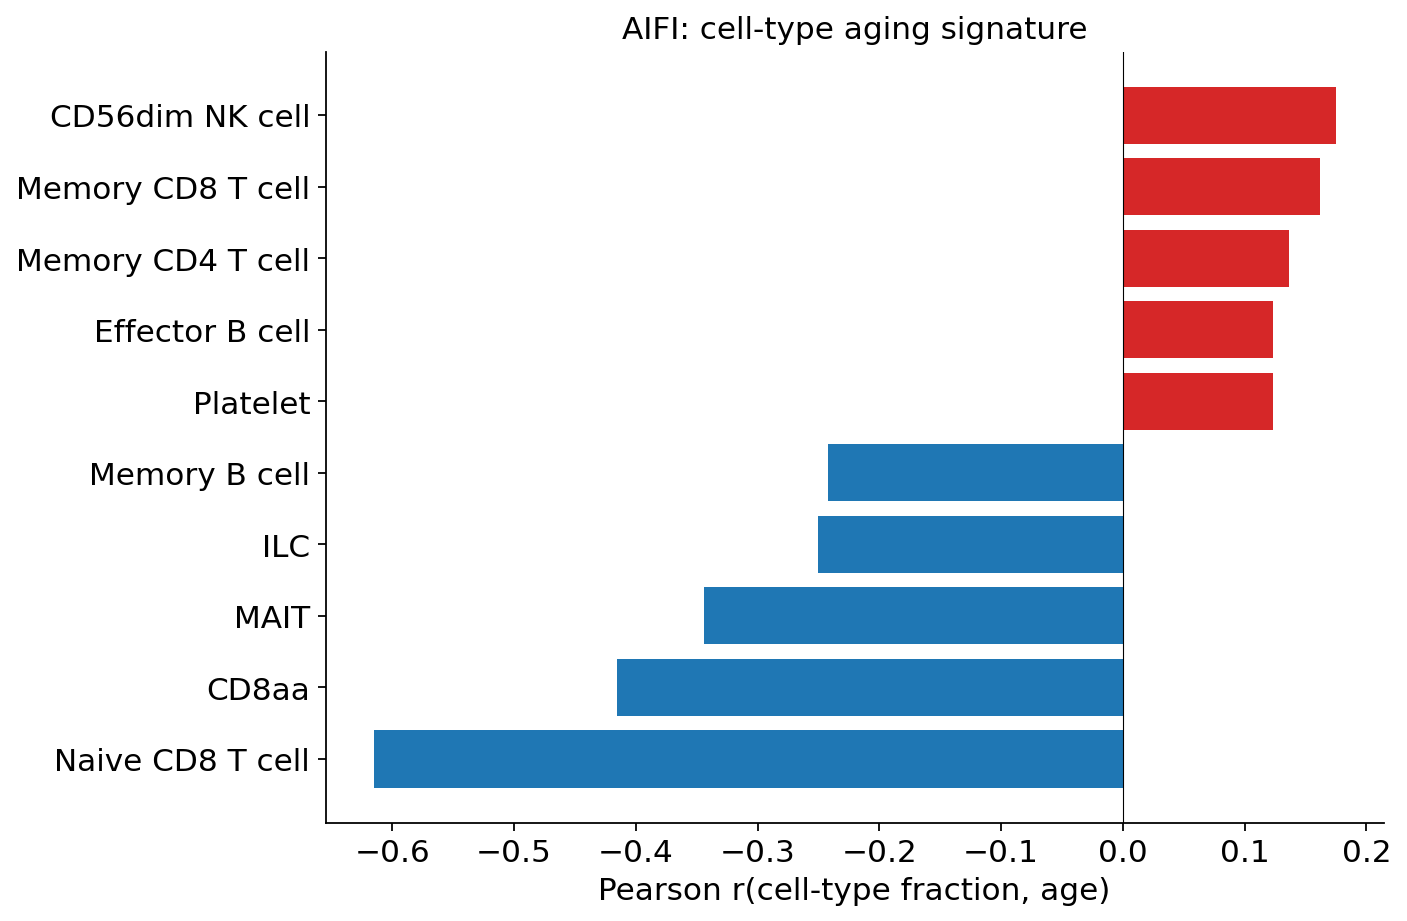

In [21]:
# Pearson-correlate each per-donor cell-type fraction with age.
fractions_with_age = celltype_fractions.join(donor_meta["age"])
ages = fractions_with_age.pop("age")
corr_aging = fractions_with_age.apply(
    lambda fraction: pd.Series({"r": pearsonr(fraction, ages)[0], "p": pearsonr(fraction, ages)[1]})
).T.sort_values("r")
print("Top cell types DECREASING with age (AIFI):")
print(corr_aging.head(5).round(3))
print("\nTop cell types INCREASING with age (AIFI):")
print(corr_aging.tail(5).round(3))

fig, ax = plt.subplots(figsize=(9, 6))
top = pd.concat([corr_aging.head(5), corr_aging.tail(5)])
ax.barh(top.index, top["r"], color=["#1f77b4" if r < 0 else "#d62728" for r in top["r"]])
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Pearson r(cell-type fraction, age)")
ax.set_title("AIFI: cell-type aging signature")
despine(ax)
plt.tight_layout(); plt.show()


### Genes correlated with age (pseudobulk-level)

The pseudobulk method computes a donor-level mean of the per-cell `X_pca`
embedding. To go back to gene resolution we do the same averaging at the
expression level: per donor, take the mean log-normalised expression of
every gene, then Pearson-correlate each gene's vector across donors with
age. These are the genes whose **donor-mean expression shifts with age**,
i.e. the gene-level aging signature that the pseudobulk distance is
implicitly leveraging.

In [22]:
# Pseudobulk gene expression per donor (mean of cells in log-normalised space),
# then Pearson-correlate each gene's donor-vector with age.
donors_genes, bulk_expression = pseudobulk_per_donor(adata, layer="X")
bulk_aging = pd.DataFrame(bulk_expression, index=donors_genes, columns=adata.var_names.astype(str))
print(f"pseudobulk matrix: {bulk_aging.shape}  (donors x genes)")

age = donor_meta["age"].reindex(bulk_aging.index).astype(float).values
known = np.isfinite(age)
expression = bulk_aging.values[known]
age = age[known]
gene_z = (expression - expression.mean(axis=0)) / (expression.std(axis=0) + 1e-12)
age_z = (age - age.mean()) / (age.std() + 1e-12)
gene_age_corr = pd.Series(gene_z.T @ age_z / len(age_z), index=bulk_aging.columns, name="r").sort_values()

print("\nTop 10 genes DECREASING with age in AIFI pseudobulk:")
print(gene_age_corr.head(10).round(3))
print("\nTop 10 genes INCREASING with age:")
print(gene_age_corr.tail(10).round(3))


pseudobulk matrix: (234, 4000)  (donors x genes)

Top 10 genes DECREASING with age in AIFI pseudobulk:
ROBO1    -0.606
CD248    -0.565
SFRP5    -0.538
FLNB     -0.506
NT5E     -0.500
LRRN3    -0.482
NRCAM    -0.469
SHANK1   -0.461
MXRA8    -0.414
IGFBP6   -0.404
Name: r, dtype: float64

Top 10 genes INCREASING with age:
CPQ        0.376
RNF149     0.377
KATNAL1    0.392
EDA        0.393
GREM2      0.401
FNDC3B     0.401
UPP1       0.402
PRDM1      0.449
ADGRE5     0.465
INPP4B     0.477
Name: r, dtype: float64


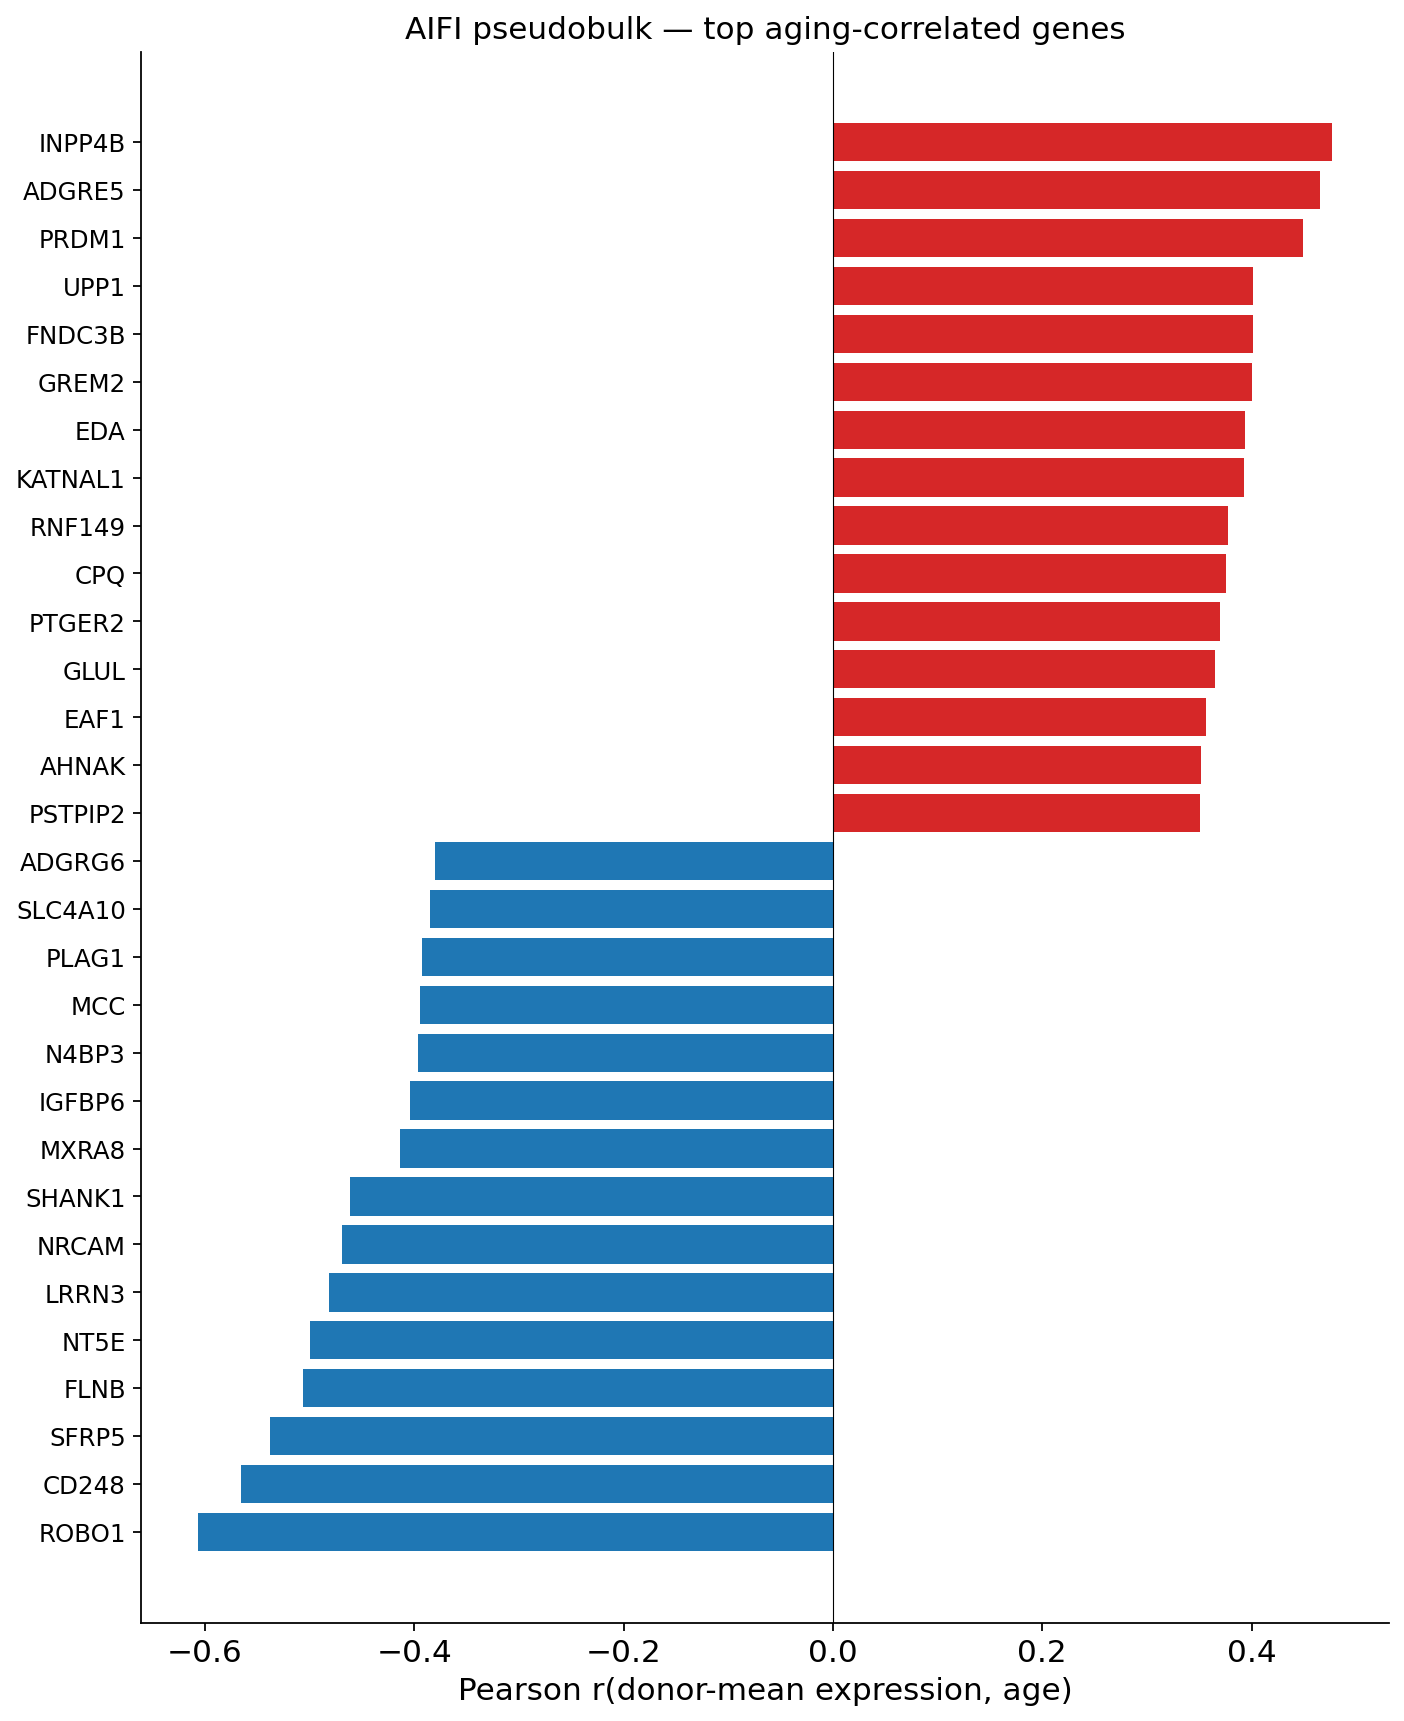

In [23]:
# Top aging-correlated genes. A tall figure + larger tick labels keeps the 30
# gene names from crowding each other.
fig, ax = plt.subplots(figsize=(9, 11))
top = pd.concat([gene_age_corr.head(15), gene_age_corr.tail(15)]).sort_values()
ax.barh(top.index, top.values, color=["#1f77b4" if r < 0 else "#d62728" for r in top.values])
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Pearson r(donor-mean expression, age)")
ax.set_title("AIFI pseudobulk — top aging-correlated genes")
ax.tick_params(axis="y", labelsize=11)
despine(ax)
plt.tight_layout(); plt.show()


### Connecting the PCs back to genes

The pseudobulk distance lives in 50-D `X_pca` space; the methods above
treat each PC as a feature without knowing what biology lives in it. We
can read each PC's "meaning" off its loadings (`adata.varm["PCs"]` — the
eigenvectors that mapped log-normalised gene expression into the 50-D PCA
space).

For each donor-level age-correlated PC, the top-loading genes tell us
what transcriptional program drove that PC.

In [24]:
# Per-donor mean of X_pca = the pseudobulk vector. Correlate each PC with age.
donors_pca, pca_means = pseudobulk_per_donor(adata, layer="X_pca")
pca_per_donor = pd.DataFrame(
    pca_means, index=donors_pca, columns=[f"PC{i + 1}" for i in range(pca_means.shape[1])]
)
age = donor_meta["age"].reindex(pca_per_donor.index).astype(float).values
pc_age_corr = pd.Series(
    [pearsonr(pca_per_donor[pc].values, age)[0] for pc in pca_per_donor.columns],
    index=pca_per_donor.columns, name="r",
).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top 10 PCs by |r(donor-mean PC, age)|:")
print(pc_age_corr.head(10).round(3))


Top 10 PCs by |r(donor-mean PC, age)|:
PC9     0.391
PC28    0.352
PC8    -0.288
PC10   -0.277
PC22   -0.249
PC26   -0.247
PC27   -0.212
PC25   -0.212
PC21    0.206
PC43    0.206
Name: r, dtype: float64


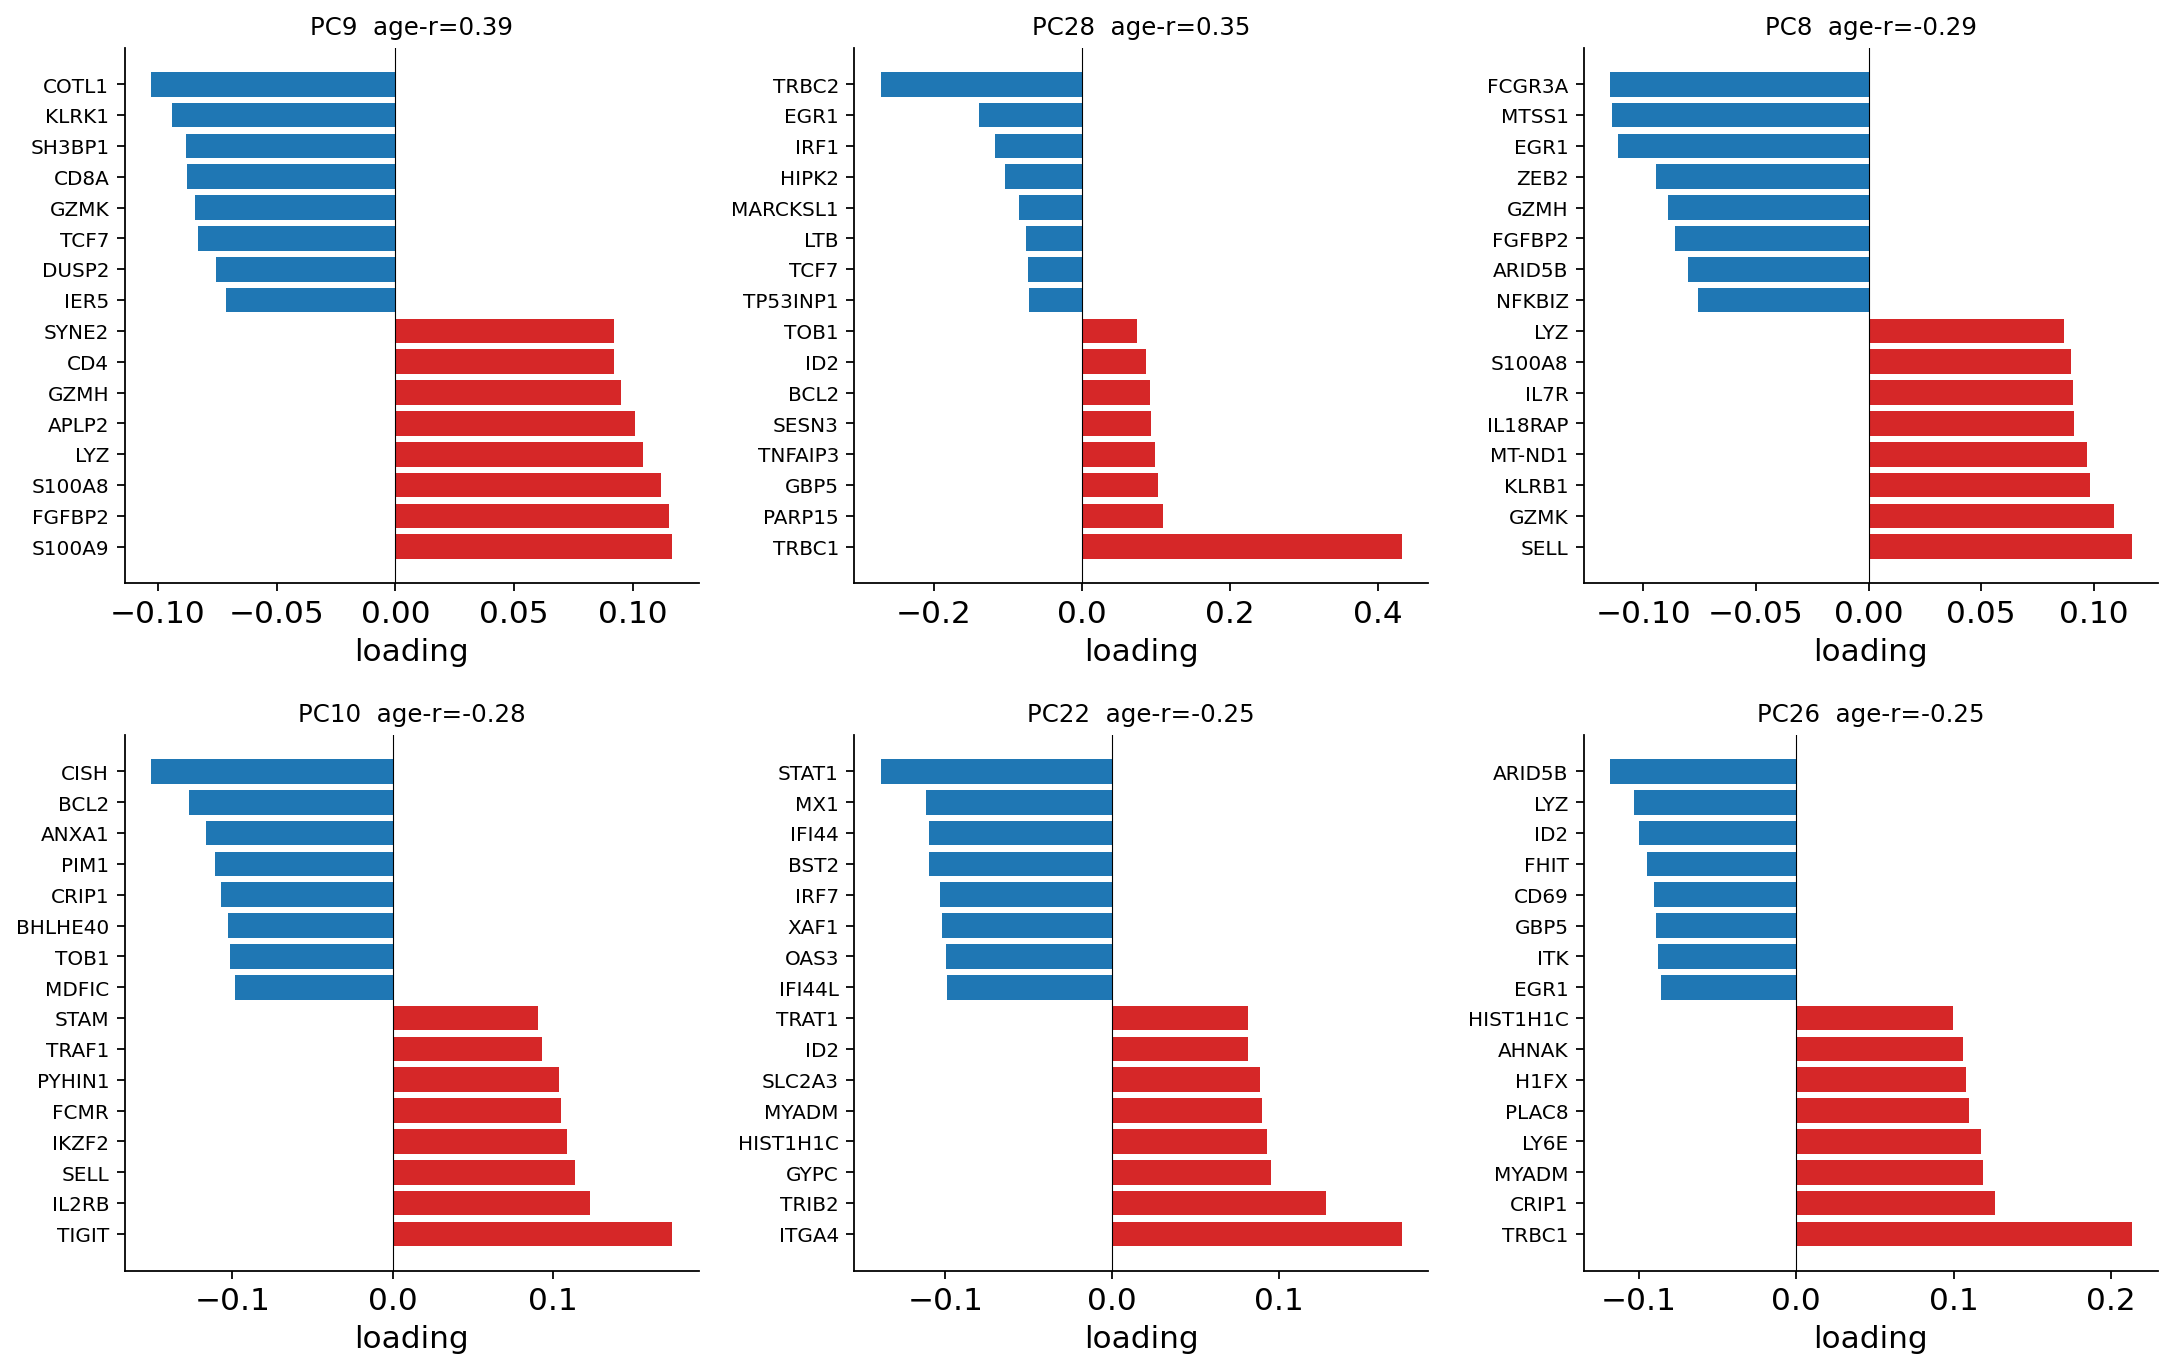

In [25]:
# Read the top-loading genes for the most age-correlated PCs.
loadings = pd.DataFrame(
    adata.varm["PCs"], index=adata.var_names.astype(str),
    columns=[f"PC{i + 1}" for i in range(adata.varm["PCs"].shape[1])],
)

top_pcs = pc_age_corr.head(6).index.tolist()
ncols = 3
nrows = int(np.ceil(len(top_pcs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.6, nrows * 4.4), squeeze=False)
for ax, pc in zip(axes.ravel(), top_pcs):
    loads = loadings[pc].sort_values()
    top_genes = pd.concat([loads.head(8), loads.tail(8)])
    ax.barh(top_genes.index, top_genes.values,
            color=["#1f77b4" if value < 0 else "#d62728" for value in top_genes.values])
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{pc}  age-r={pc_age_corr[pc]:.2f}", fontsize=11)
    ax.set_xlabel("loading")
    ax.tick_params(axis="y", labelsize=9)
    ax.invert_yaxis()
    despine(ax)
for ax in axes.ravel()[len(top_pcs):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()


**Reading the loading plots.** For each of the top age-correlated PCs,
red bars are genes that **load positively** on the PC (cells expressing
them shift the PC value up) and blue bars are genes loading negatively.
Combined with the header's `age-r`:

- A PC with `age-r > 0` whose red bars include cytotoxic markers
  (`GZMB`, `GNLY`, `PRF1`, `NKG7`) tells us: *donors with more cells
  expressing this cytotoxic program score higher on this PC, and that
  PC tracks age*.
- A PC with `age-r < 0` whose red bars include naive T markers
  (`CCR7`, `LEF1`, `TCF7`, `SELL`) tells us the *opposite* — that PC
  encodes naivety, and naivety drops with age.

This is the same biology you'd get from a manual differential test on
pseudobulks, just routed through the PCA the methods actually consume.

## Cross-cohort validation on OneK1K

Same three unsupervised methods + SampleCLR on a 981-donor independent
cohort with age 19–97. If a method captures *aging* and not *AIFI
quirks*, the score on OneK1K should look similar.

In [26]:
def load_onek1k():
    onek1k, _ = patpy.datasets.onek1k(return_dataset_info=True)
    onek1k.obs["donor"] = onek1k.obs["donor_id"].astype(str)
    onek1k.obs["age_group"] = np.where(onek1k.obs["age"] >= 65, "old", "young")
    return onek1k

t0 = time.time()
adata_one = load_onek1k()
if SMOKE:
    adata_one = smoke_subset(adata_one, n_donors=20, max_cells_per_donor=N_CELLS_PER_DONOR)
print(f"OneK1K: n_cells={adata_one.n_obs:,}  n_donors={adata_one.obs['donor'].nunique()}  loaded in {time.time()-t0:.1f}s")


OneK1K: n_cells=1,248,980  n_donors=981  loaded in 12.9s


In [27]:
# Cross-cohort: re-fit the two cheap unsupervised methods on OneK1K and score
# age with the same linear probe used on AIFI.
donor_meta_one = adata_one.obs[["donor", "age", "age_group", "sex", "pool_number"]].copy()
donor_meta_one["donor"] = donor_meta_one["donor"].astype(str)
donor_meta_one = donor_meta_one.groupby("donor", observed=True).agg(
    age=("age", "first"), age_group=("age_group", "first"),
    sex=("sex", "first"), pool=("pool_number", "first"),
)

donor_order_one = list(pd.unique(adata_one.obs["donor"].astype(str)))
train_one, test_one = donor_train_test_split(donor_order_one, seed=SEED)


def score_unsupervised_onek1k(method):
    """Linear-probe age score on OneK1K, reported for all donors and for age >= 40.

    AIFI only covers ages 40-89, so the ``age >= 40`` slice is the fair
    cross-cohort comparison.
    """
    method.prepare_anndata(adata_one)
    method.calculate_distance_matrix()
    probe = method.fit_linear_probe("age", task="regression", test_sample_labels=test_one)
    y_true = np.asarray(probe["age_test"], dtype=float)
    y_pred = np.asarray(probe["age_pred"], dtype=float)
    over_40 = y_true >= 40
    return (
        patpy.tl.evaluate_regression(y_true, y_pred),
        patpy.tl.evaluate_regression(y_true[over_40], y_pred[over_40]),
    )


score_pb_one_all, score_pb_one_40 = score_unsupervised_onek1k(
    patpy.tl.Pseudobulk(sample_key="donor", cell_group_key="cell_type", layer="X_pca", seed=SEED)
)
score_comp_one_all, score_comp_one_40 = score_unsupervised_onek1k(
    patpy.tl.CellGroupComposition(sample_key="donor", cell_group_key="cell_type", apply_clr=True, seed=SEED)
)

for name, scores_all, scores_40 in [
    ("pseudobulk", score_pb_one_all, score_pb_one_40),
    ("composition", score_comp_one_all, score_comp_one_40),
]:
    print(f"OneK1K {name:<12s} all donors:  R²={scores_all['r2']:.3f}  Spearman={scores_all['spearman']:.3f}  MAE={scores_all['mae']:.2f}  n={scores_all['n']}")
    print(f"OneK1K {name:<12s} age >= 40:   R²={scores_40['r2']:.3f}  Spearman={scores_40['spearman']:.3f}  MAE={scores_40['mae']:.2f}  n={scores_40['n']}")
print()
print("OneK1K covers age 19-97; the AIFI cohort only covers 40-89, so the")
print("`age >= 40` row is the fair comparison for cross-cohort transfer.")


OneK1K pseudobulk   all donors:  R²=0.450  Spearman=0.648  MAE=9.74  n=196
OneK1K pseudobulk   age >= 40:   R²=0.199  Spearman=0.534  MAE=8.30  n=171
OneK1K composition  all donors:  R²=0.475  Spearman=0.671  MAE=9.74  n=196
OneK1K composition  age >= 40:   R²=0.137  Spearman=0.546  MAE=8.72  n=171

OneK1K covers age 19-97; the AIFI cohort only covers 40-89, so the
`age >= 40` row is the fair comparison for cross-cohort transfer.


In [28]:
celltype_fractions_one = pd.crosstab(
    adata_one.obs["donor"].astype(str), adata_one.obs["cell_type"].astype(str), normalize="index"
).join(donor_meta_one["age"])
ages_one = celltype_fractions_one.pop("age")
corr_one = celltype_fractions_one.apply(
    lambda fraction: pd.Series({"r": pearsonr(fraction, ages_one)[0], "p": pearsonr(fraction, ages_one)[1]})
).T.sort_values("r")
print("OneK1K — top cell types decreasing with age:")
print(corr_one.head(5).round(3))
print("\nTop cell types increasing with age:")
print(corr_one.tail(5).round(3))


OneK1K — top cell types decreasing with age:
                                                        r    p
naive thymus-derived CD8-positive, alpha-beta T... -0.680  0.0
mucosal invariant T cell                           -0.297  0.0
naive thymus-derived CD4-positive, alpha-beta T... -0.200  0.0
memory B cell                                      -0.153  0.0
central memory CD8-positive, alpha-beta T cell     -0.135  0.0

Top cell types increasing with age:
                                                     r      p
central memory CD4-positive, alpha-beta T cell   0.068  0.032
CD4-positive, alpha-beta cytotoxic T cell        0.156  0.000
CD14-low, CD16-positive monocyte                 0.188  0.000
effector memory CD8-positive, alpha-beta T cell  0.218  0.000
natural killer cell                              0.308  0.000


                 AIFI  OneK1K
family                       
B_memory       -0.242  -0.153
B_naive        -0.156  -0.026
CD4_naive      -0.012  -0.200
CD8_naive      -0.615  -0.680
DC             -0.088   0.005
Mono_CD16       0.060   0.188
Mono_classical  0.085   0.056
T_effector      0.123   0.056
plasma         -0.058  -0.111


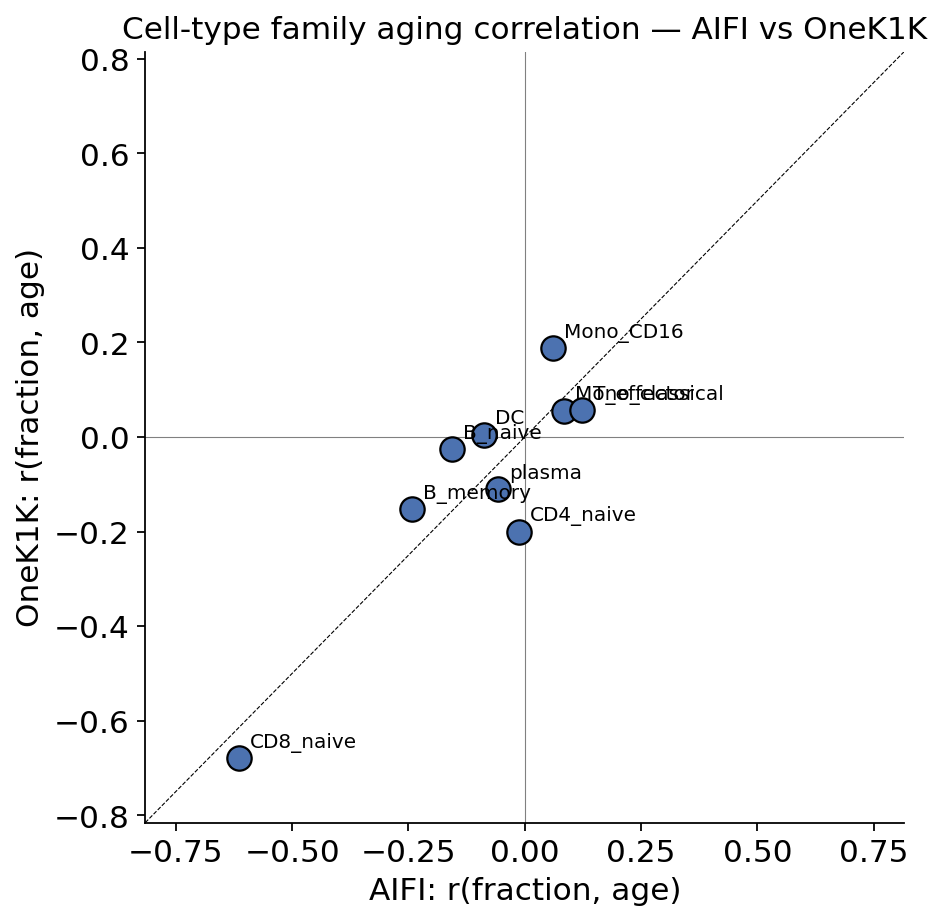

In [29]:
# Cross-cohort cell-type family agreement.
def family(name):
    lowered = str(name).lower()
    if "naive" in lowered and ("cd4" in lowered or "t4" in lowered): return "CD4_naive"
    if "naive" in lowered and ("cd8" in lowered or "t8" in lowered): return "CD8_naive"
    if "tem" in lowered or "effector" in lowered or "gzmb" in lowered: return "T_effector"
    if "treg" in lowered: return "Treg"
    if "naive b" in lowered or "b_naive" in lowered: return "B_naive"
    if "memory b" in lowered or "b mem" in lowered: return "B_memory"
    if "monocyte" in lowered and ("cd16" in lowered or "non-classical" in lowered): return "Mono_CD16"
    if "monocyte" in lowered: return "Mono_classical"
    if "nk" in lowered: return "NK"
    if "mait" in lowered or "gdt" in lowered: return "MAIT_gdT"
    if "dc" in lowered or "dendritic" in lowered: return "DC"
    if "plasma" in lowered: return "plasma"
    return None


aifi_family = corr_aging.assign(family=corr_aging.index.map(family)).dropna(subset=["family"]).groupby("family")["r"].mean()
onek1k_family = corr_one.assign(family=corr_one.index.map(family)).dropna(subset=["family"]).groupby("family")["r"].mean()
family_corr = pd.concat([aifi_family.rename("AIFI"), onek1k_family.rename("OneK1K")], axis=1).dropna()
print(family_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(family_corr["AIFI"], family_corr["OneK1K"], s=120, c="#4C72B0", edgecolor="black", zorder=3)
for family_name, row in family_corr.iterrows():
    ax.annotate(family_name, (row["AIFI"], row["OneK1K"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
lim = max(family_corr.abs().max()) * 1.2
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("AIFI: r(fraction, age)"); ax.set_ylabel("OneK1K: r(fraction, age)")
ax.set_title("Cell-type family aging correlation — AIFI vs OneK1K")
despine(ax)
plt.tight_layout(); plt.show()


## Generalisation: train on AIFI, predict on OneK1K

So far we re-trained each model from scratch on each cohort. Real
deployment looks more like *train once on a reference cohort, predict
on every new donor that comes in*. Two engineering choices and one
biological question.

**Engineering**

1. **Feature alignment.** AIFI and OneK1K have different gene panels and were
   PCA'd independently, so their `X_pca` spaces are incomparable out of the box.
   We match the cohorts on **shared gene symbols** (AIFI stores symbols in
   `var_names`; OneK1K stores Ensembl IDs with the symbol in
   `var["feature_name"]`) and build two shared-space inputs on each cohort:
   `obsm["X_shared_genes"]` (log-normalised expression on the shared panel, the
   gene-level input for PaSCient) and `obsm["X_pca_shared"]` (a PCA refit on AIFI
   shared genes and applied to both, the low-dim input for SampleCLR / MixMIL).
2. **Bag size.** AIFI donors have ~16K cells each, OneK1K donors have
   ~1.3K. We use a small bag of 200 cells/donor for both training and
   inference so OneK1K donors aren't dominated by zero-padding.

**Biological question.** Three protocols on the same models:

- **Zero-shot transfer** — train on AIFI, predict OneK1K with no
  further training. Worst case.
- **Fine-tuning with a small donor budget** — train on AIFI, then
  continue training on **10% of OneK1K donors** (with a smaller lr and
  fewer epochs), then predict the remaining 90%. Does a tiny budget
  of in-domain donors fix the transfer gap?
- AIFI in-sample for reference.

**Young-weighted FT subset.** AIFI only covers age 40-89, so the
AIFI-pretrained models are most likely to misjudge donors below 40
(OneK1K has a non-trivial under-40 cohort). A plain random 10% would
inherit OneK1K's natural age distribution and under-represent young
donors — exactly where the AIFI-trained models struggle. We instead
sample each donor with probability proportional to
``(max_age - age + 1)``, which mildly biases the FT subset toward
younger donors while still covering the full 19-97 range. The 90%
held-out test set never sees the fine-tune step. Below we report
predictions on **all donors** and separately on **donors with age >=
40**, the slice that matches AIFI's training range.


In [30]:
from sklearn.decomposition import PCA


def shared_gene_index(aifi, onek1k):
    """Match AIFI gene symbols to OneK1K (Ensembl IDs + ``var['feature_name']`` symbols).

    Returns the sorted shared symbols and the column indices into each cohort.
    """
    aifi_symbols = aifi.var_names.astype(str)
    one_symbols = (
        onek1k.var["feature_name"].astype(str)
        if "feature_name" in onek1k.var.columns
        else onek1k.var_names.astype(str)
    )
    shared = sorted(set(aifi_symbols) & set(one_symbols))
    if len(shared) < 200:
        raise RuntimeError(f"too few shared gene symbols: {len(shared)}")
    aifi_idx = aifi.var_names.get_indexer(shared)
    onek1k_idx = pd.Series(np.arange(onek1k.n_vars), index=one_symbols.values).reindex(shared).values.astype(int)
    return shared, aifi_idx, onek1k_idx


def _shared_gene_matrix(adata, gene_idx):
    block = adata.X[:, gene_idx]
    return np.asarray(block.toarray() if hasattr(block, "toarray") else block, dtype=np.float32)


def fit_shared_pca(aifi, aifi_idx, n_pcs=50, fit_subsample=300_000, seed=SEED):
    """Fit a PCA on AIFI restricted to the shared gene panel (on a cell subsample)."""
    rng = np.random.default_rng(seed)
    rows = np.arange(aifi.n_obs)
    if aifi.n_obs > fit_subsample:
        rows = np.sort(rng.choice(aifi.n_obs, fit_subsample, replace=False))
    pca = PCA(n_components=n_pcs, svd_solver="randomized", random_state=seed)
    pca.fit(_shared_gene_matrix(aifi[rows], aifi_idx))
    print(f"PCA fit on {len(rows):,} cells: cumulative variance = {pca.explained_variance_ratio_.sum():.3f}")
    return pca


def attach_shared_features(adata, gene_idx, pca):
    """Store both shared-space inputs on a (subsampled) AnnData.

    - ``obsm['X_shared_genes']``: log-normalised expression on the shared panel
      (gene-level input for PaSCient);
    - ``obsm['X_pca_shared']``: the shared PCA applied to it (low-dim input for
      SampleCLR / MixMIL).
    """
    shared_lognorm = _shared_gene_matrix(adata, gene_idx)
    adata.obsm["X_shared_genes"] = shared_lognorm
    adata.obsm["X_pca_shared"] = pca.transform(shared_lognorm).astype(np.float32)


shared_genes, aifi_gene_idx, onek1k_gene_idx = shared_gene_index(adata, adata_one)
print(f"shared gene symbols: {len(shared_genes)}")
pca_shared = fit_shared_pca(adata, aifi_gene_idx, n_pcs=50)


shared gene symbols: 885


PCA fit on 300,000 cells: cumulative variance = 0.624


0 samples removed: 


0 samples removed: 


AIFI training set:        46,800 cells  (234 donors)
OneK1K fine-tune set:     19,600 cells  (98 donors, young-weighted, age 19-87, median 56)
OneK1K held-out test set: 176,600 cells  (883 donors)


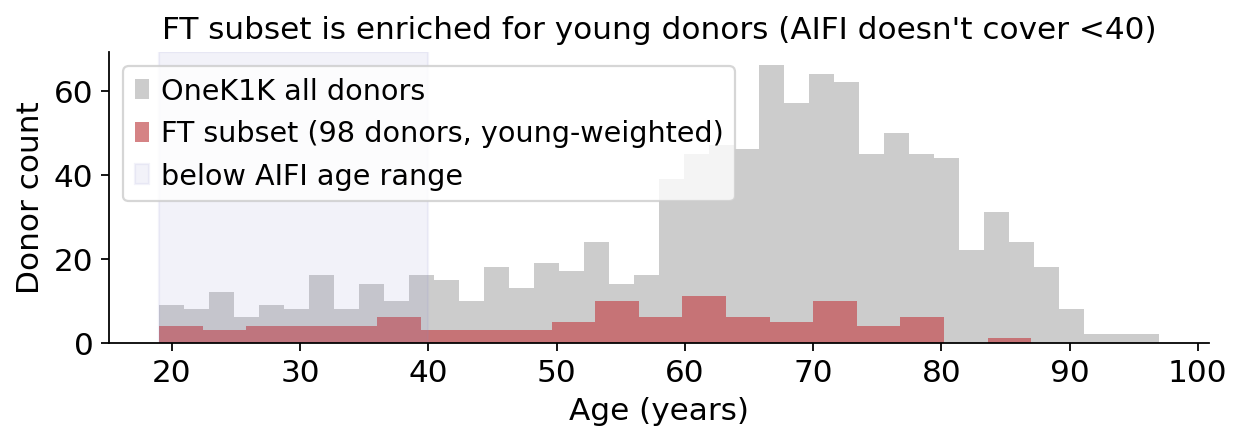

In [31]:
# Bag size used for training + inference. 200 cells fits OneK1K donors well.
N_CELLS_TRANSFER = 50 if SMOKE else 200
FINETUNE_FRACTION = 0.10        # 10% of OneK1K donors used to fine-tune the AIFI model

aifi_t = filter_and_subsample(adata, sample_size_threshold=0, max_cells_per_donor=N_CELLS_TRANSFER)
one_t = filter_and_subsample(adata_one, sample_size_threshold=0, max_cells_per_donor=N_CELLS_TRANSFER)

# Materialise the shared-space features on the (small) transfer subsets only, so we
# never densify the full multi-million-cell matrices. one_test / one_ft are sliced
# from one_t below and inherit these obsm entries.
attach_shared_features(aifi_t, aifi_gene_idx, pca_shared)
attach_shared_features(one_t, onek1k_gene_idx, pca_shared)


def sample_young_weighted(donor_age, n_target, seed):
    """Draw `n_target` donors without replacement, weighted by (max_age - age + 1).

    Keeps the full age range represented but biases toward the young end of OneK1K —
    the slice the AIFI-pretrained model (only saw ages 40-89) struggles with.
    """
    donor_age = donor_age.dropna().astype(float)
    if n_target >= len(donor_age):
        return list(donor_age.index)
    weights = (donor_age.max() - donor_age + 1.0).values
    weights = weights / weights.sum()
    rng = np.random.default_rng(seed)
    return list(rng.choice(donor_age.index.values, size=n_target, replace=False, p=weights))


one_donors_all = pd.Index(pd.unique(one_t.obs["donor"]))
donor_age_one = donor_meta_one["age"].reindex(one_donors_all).astype(float)
n_finetune = max(5, round(len(donor_age_one.dropna()) * FINETUNE_FRACTION))
finetune_donors = sample_young_weighted(donor_age_one, n_finetune, seed=SEED)
finetune_set = set(finetune_donors)
one_ft = one_t[one_t.obs["donor"].isin(finetune_set)].copy()
one_test = one_t[~one_t.obs["donor"].isin(finetune_set)].copy()

finetune_ages = donor_age_one.reindex(finetune_donors)
print(f"AIFI training set:        {aifi_t.n_obs:,} cells  ({aifi_t.obs['donor'].nunique()} donors)")
print(f"OneK1K fine-tune set:     {one_ft.n_obs:,} cells  ({len(finetune_donors)} donors, "
      f"young-weighted, age {finetune_ages.min():.0f}-{finetune_ages.max():.0f}, median {finetune_ages.median():.0f})")
print(f"OneK1K held-out test set: {one_test.n_obs:,} cells  ({one_test.obs['donor'].nunique()} donors)")

# Visualise the FT-subset age distribution against the full cohort.
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(donor_age_one.dropna(), bins=40, alpha=0.4, color="grey", label="OneK1K all donors")
ax.hist(finetune_ages, bins=20, alpha=0.7, color="#C44E52",
        label=f"FT subset ({len(finetune_donors)} donors, young-weighted)")
ax.axvspan(19, 40, color="#88c", alpha=0.10, label="below AIFI age range")
ax.set_xlabel("Age (years)"); ax.set_ylabel("Donor count")
ax.set_title("FT subset is enriched for young donors (AIFI doesn't cover <40)")
ax.legend()
despine(ax)
plt.tight_layout(); plt.show()


In [32]:
def score_with_age_floor(y_true, y_pred, age_floor=None):
    """Regression metrics, optionally restricted to donors with age >= age_floor."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if age_floor is not None:
        keep = np.isfinite(y_true) & (y_true >= age_floor)
        y_true, y_pred = y_true[keep], y_pred[keep]
    return patpy.tl.evaluate_regression(y_true, y_pred)


def pascient_predict_on(pascient, adata):
    """Re-point a trained PaSCient at a new in-memory cohort and predict age.

    PaSCient.prepare_anndata(train=False) needs a checkpoint on disk, so for an
    already-trained model we swap the cohort and re-extract its cell embeddings.
    """
    pascient.adata = adata
    pascient.samples = pd.unique(adata.obs["donor"]).tolist()
    pascient._cell_embeddings = {}
    pascient._extract_embeddings(adata)
    return pascient.predict("age")


# --- PaSCient transfer: gene-level log-normalised input on the shared panel ---
pa = patpy.tl.PaSCient(
    sample_key="donor", label_keys=["age"], tasks=["regression"],
    cell_group_key=None, layer="X_shared_genes",   # log-normalised shared-gene expression
    n_cells=N_CELLS_TRANSFER,
    batch_size=16 if torch.cuda.is_available() else 8,
    n_epochs=2 if SMOKE else 30,
    device="cuda" if torch.cuda.is_available() else "cpu",
    normalize=False, seed=SEED,
)
t0 = time.time()
pa.prepare_anndata(aifi_t, train=True)
print(f"PaSCient AIFI train: {time.time()-t0:.1f}s")
aifi_pa_pred = pa.predict("age")

# Snapshot of AIFI-only weights, reused by the FT-fraction sweep below.
pa_aifi_state = {k: v.detach().cpu().clone() for k, v in pa._pascient_model.state_dict().items()}

# 1) Zero-shot: predict the OneK1K test set with no further training.
one_pa_pred_zs = pascient_predict_on(pa, one_test)

# 2) Fine-tune on the 10% OneK1K subset (lower lr, fewer epochs).
pa.adata = one_ft
pa.samples = pd.unique(one_ft.obs["donor"]).tolist()
pa.labels = pa._extract_metadata(pa.label_keys)
pa.lr = 1e-5
pa.n_epochs = 5 if SMOKE else 15
t0 = time.time()
pa.fine_tune("age", "regression", n_epochs=pa.n_epochs)
print(f"PaSCient OneK1K fine-tune ({pa.n_epochs} epochs, lr={pa.lr}): {time.time()-t0:.1f}s")

# 3) Predict the held-out OneK1K test set with the fine-tuned model.
one_pa_pred_ft = pascient_predict_on(pa, one_test)

aifi_pa_score = score_with_age_floor(donor_meta["age"].reindex(aifi_pa_pred.index).values, aifi_pa_pred.values)
age_zs_pa = donor_meta_one["age"].reindex(one_pa_pred_zs.index).astype(float).values
age_ft_pa = donor_meta_one["age"].reindex(one_pa_pred_ft.index).astype(float).values
zs_pa_score_all = score_with_age_floor(age_zs_pa, one_pa_pred_zs.values)
zs_pa_score_40 = score_with_age_floor(age_zs_pa, one_pa_pred_zs.values, age_floor=40)
ft_pa_score_all = score_with_age_floor(age_ft_pa, one_pa_pred_ft.values)
ft_pa_score_40 = score_with_age_floor(age_ft_pa, one_pa_pred_ft.values, age_floor=40)

print(f"PaSCient AIFI in-sample:             R²={aifi_pa_score['r2']:.3f}  Spearman={aifi_pa_score['spearman']:.3f}  MAE={aifi_pa_score['mae']:.2f}")
print(f"PaSCient OneK1K zero-shot (all):     R²={zs_pa_score_all['r2']:.3f}  Spearman={zs_pa_score_all['spearman']:.3f}  MAE={zs_pa_score_all['mae']:.2f}  n={zs_pa_score_all['n']}")
print(f"PaSCient OneK1K zero-shot (>=40):    R²={zs_pa_score_40['r2']:.3f}  Spearman={zs_pa_score_40['spearman']:.3f}  MAE={zs_pa_score_40['mae']:.2f}  n={zs_pa_score_40['n']}")
print(f"PaSCient OneK1K after 10% FT (all):  R²={ft_pa_score_all['r2']:.3f}  Spearman={ft_pa_score_all['spearman']:.3f}  MAE={ft_pa_score_all['mae']:.2f}  n={ft_pa_score_all['n']}")
print(f"PaSCient OneK1K after 10% FT (>=40): R²={ft_pa_score_40['r2']:.3f}  Spearman={ft_pa_score_40['spearman']:.3f}  MAE={ft_pa_score_40['mae']:.2f}  n={ft_pa_score_40['n']}")


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-449040eb-cddc-5194-aac7-5b9d2296207a]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                        ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gene2cell_encoder           │ BasicMLP                │  907 K │ train │     0 │
│ 1 │ cell2patient_aggregation    │ NonLinearAttnAggregator │  1.1 M │ train │     0 │
│ 2 │ patient_encoder             │ BasicMLP                │  787 K │ train │     0 │
│ 3 │ cell2cell_encoder           │ CellToCellIdentity      │      0 │ train │     0 │
│ 4 │ sample_prediction_loss_func │ _RegressionLoss         │      0 │ train │     0 │
│ 5 │ patient_predictor           │ BasicMLP                │    513 │ train │     0 │
└───┴─────────────────────────────┴─────────────────────────┴────────┴───────┴───────┘

...

SLURM auto-requeueing enabled. Setting signal handlers.


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=15` reached.


PaSCient OneK1K fine-tune (15 epochs, lr=1e-05): 2.7s


PaSCient AIFI in-sample:             R²=0.943  Spearman=0.969  MAE=1.96
PaSCient OneK1K zero-shot (all):     R²=0.156  Spearman=0.422  MAE=11.25  n=883
PaSCient OneK1K zero-shot (>=40):    R²=0.085  Spearman=0.357  MAE=9.07  n=800
PaSCient OneK1K after 10% FT (all):  R²=-0.164  Spearman=0.386  MAE=13.88  n=883
PaSCient OneK1K after 10% FT (>=40): R²=-1.093  Spearman=0.294  MAE=13.62  n=800


In [33]:
# --- SampleCLR transfer: predict age with the fitted regression head ---
from sampleclr import ContrastiveModel

device = "cuda" if torch.cuda.is_available() else "cpu"
aifi_donors = list(pd.unique(aifi_t.obs["donor"]))
test_donors_one = list(pd.unique(one_test.obs["donor"]))

# 1. Pretrain + fine-tune on AIFI.
n_epochs = 10 if SMOKE else 30
sclr_t = ContrastiveModel(
    adata=aifi_t, sample_key="donor", layer="X_pca_shared",
    tasks={"regression": ["age"]}, batch_size=8,
    num_epochs_stage1=n_epochs, num_epochs_stage2=n_epochs,
    num_warmup_epochs_stage1=max(1, n_epochs // 5),
    num_warmup_epochs_stage2=max(1, n_epochs // 5),
    early_stopping_patience=8, aggregator_activation="relu",
    use_batch_aware_sampler=True, batch_sampler_batch_col="batch_id",
    verbose=False, seed=SEED,
)
t0 = time.time()
sclr_t.pretrain()
sclr_t.fine_tune(val_metric="loss")
print(f"SampleCLR AIFI train: {time.time()-t0:.1f}s")

# Snapshot of AIFI-only weights, reused by the FT-fraction sweep below.
sclr_aifi_state = {
    "projector": {k: v.detach().cpu().clone() for k, v in sclr_t.projector.state_dict().items()},
    "aggregator": {k: v.detach().cpu().clone() for k, v in sclr_t.aggregator.state_dict().items()},
}

# 2. AIFI in-sample + zero-shot OneK1K, both through the regression head.
# Keep sclr_t alive: the FT-fraction sweep below reuses it for its zero-shot point.
aifi_sc_pred = predict_age_sampleclr(sclr_t, aifi_t, aifi_donors, layer="X_pca_shared", subset_size=N_CELLS_TRANSFER)
one_sc_pred_zs = predict_age_sampleclr(sclr_t, one_test, test_donors_one, layer="X_pca_shared", subset_size=N_CELLS_TRANSFER)

# 3. Fine-tune on the 10% OneK1K subset, starting from the AIFI weights.
ft_epochs = 5 if SMOKE else 20
sclr_ft = ContrastiveModel(
    adata=one_ft, sample_key="donor", layer="X_pca_shared",
    tasks={"regression": ["age"]}, batch_size=8,
    num_epochs_stage1=1, num_epochs_stage2=ft_epochs,
    num_warmup_epochs_stage1=1, num_warmup_epochs_stage2=max(1, ft_epochs // 5),
    early_stopping_patience=8, aggregator_activation="relu",
    use_batch_aware_sampler=False, verbose=False, seed=SEED,
)
try:
    sclr_ft.projector.load_state_dict({k: v.to(device) for k, v in sclr_aifi_state["projector"].items()})
    sclr_ft.aggregator.load_state_dict({k: v.to(device) for k, v in sclr_aifi_state["aggregator"].items()})
    print("loaded AIFI projector + aggregator weights")
except RuntimeError as error:
    print(f"WARN: could not load AIFI weights: {error}")
t0 = time.time()
sclr_ft.fine_tune(val_metric="loss")
print(f"SampleCLR OneK1K fine-tune ({ft_epochs} epochs): {time.time()-t0:.1f}s")

# 4. Predict the OneK1K test set with the fine-tuned head.
one_sc_pred_ft = predict_age_sampleclr(sclr_ft, one_test, test_donors_one, layer="X_pca_shared", subset_size=N_CELLS_TRANSFER)
del sclr_ft; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 5. Score.
age_aifi = donor_meta["age"].reindex(aifi_donors).astype(float).values
age_test_one = donor_meta_one["age"].reindex(test_donors_one).astype(float).values
aifi_sc_score = score_with_age_floor(age_aifi, aifi_sc_pred.values)
zs_sc_score_all = score_with_age_floor(age_test_one, one_sc_pred_zs.values)
zs_sc_score_40 = score_with_age_floor(age_test_one, one_sc_pred_zs.values, age_floor=40)
ft_sc_score_all = score_with_age_floor(age_test_one, one_sc_pred_ft.values)
ft_sc_score_40 = score_with_age_floor(age_test_one, one_sc_pred_ft.values, age_floor=40)
print(f"SampleCLR AIFI in-sample:            R²={aifi_sc_score['r2']:.3f}  Spearman={aifi_sc_score['spearman']:.3f}  MAE={aifi_sc_score['mae']:.2f}")
print(f"SampleCLR OneK1K zero-shot (all):    R²={zs_sc_score_all['r2']:.3f}  Spearman={zs_sc_score_all['spearman']:.3f}  MAE={zs_sc_score_all['mae']:.2f}  n={zs_sc_score_all['n']}")
print(f"SampleCLR OneK1K zero-shot (>=40):   R²={zs_sc_score_40['r2']:.3f}  Spearman={zs_sc_score_40['spearman']:.3f}  MAE={zs_sc_score_40['mae']:.2f}  n={zs_sc_score_40['n']}")
print(f"SampleCLR OneK1K after 10% FT (all): R²={ft_sc_score_all['r2']:.3f}  Spearman={ft_sc_score_all['spearman']:.3f}  MAE={ft_sc_score_all['mae']:.2f}  n={ft_sc_score_all['n']}")
print(f"SampleCLR OneK1K after 10% FT (>=40):R²={ft_sc_score_40['r2']:.3f}  Spearman={ft_sc_score_40['spearman']:.3f}  MAE={ft_sc_score_40['mae']:.2f}  n={ft_sc_score_40['n']}")


Stage 1: Contrastive-only training (pretrain)


Epoch 1/30 - Loss: 0.0315, Contr: 0.0314, Top1: 1.000, Top5: 1.000 | Time: 3.04s (30 batches, 92.7ms/batch)


Epoch 2/30 - Loss: 0.0192, Contr: 0.0192, Top1: 1.000, Top5: 1.000 | Time: 0.59s (30 batches, 11.9ms/batch)


Epoch 3/30 - Loss: 0.0082, Contr: 0.0082, Top1: 1.000, Top5: 1.000 | Time: 0.56s (30 batches, 11.4ms/batch)


Epoch 4/30 - Loss: 0.0027, Contr: 0.0027, Top1: 1.000, Top5: 1.000 | Time: 0.43s (30 batches, 8.6ms/batch)


...


Epoch 14/20 | Time: 0.11s (12 batches, 7.1ms/batch)
contrastive – train: 0.0013 – val: N/A
regression (age) – train: 0.6511 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------

Epoch 15/20 | Time: 0.11s (12 batches, 7.1ms/batch)
contrastive – train: 0.0013 – val: N/A
regression (age) – train: 0.4631 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 16/20 | Time: 0.11s (12 batches, 6.9ms/batch)
contrastive – train: 0.0014 – val: N/A
regression (age) – train: 0.4825 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------

Epoch 17/20 | Time: 0.11s (12 batches, 6.9ms/batch)
contrastive – train: 0.0014 – val: N/A
regression (age) – train: 0.3279 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 18/20 | Time: 0.11s (12 batches, 7.0ms/batch)
contrastive – train: 0.0012 – val: N/A
regression (age) – train: 0.5705 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------

Epoch 19/20 | Time: 0.11s (12 batches, 6.9ms/batch)
contrastive – train: 0.0013 – val: N/A
regression (age) – train: 0.3067 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 20/20 | Time: 0.11s (12 batches, 7.0ms/batch)
contrastive – train: 0.0015 – val: N/A
regression (age) – train: 0.3100 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------
SampleCLR OneK1K fine-tune (20 epochs): 2.0s


SampleCLR AIFI in-sample:            R²=0.929  Spearman=0.962  MAE=2.99
SampleCLR OneK1K zero-shot (all):    R²=0.088  Spearman=0.353  MAE=12.01  n=883
SampleCLR OneK1K zero-shot (>=40):   R²=-0.062  Spearman=0.258  MAE=9.90  n=800
SampleCLR OneK1K after 10% FT (all): R²=0.098  Spearman=0.471  MAE=12.34  n=883
SampleCLR OneK1K after 10% FT (>=40):R²=-0.659  Spearman=0.342  MAE=12.23  n=800


   method                        set     r2  spearman  pearson    mae   n
 PaSCient             AIFI in-sample  0.943     0.969    0.972  1.960 234
 PaSCient     OneK1K zero-shot (all)  0.156     0.422    0.422 11.254 883
 PaSCient    OneK1K zero-shot (>=40)  0.085     0.357    0.358  9.066 800
 PaSCient  OneK1K after 10% FT (all) -0.164     0.386    0.413 13.878 883
 PaSCient OneK1K after 10% FT (>=40) -1.093     0.294    0.296 13.623 800
SampleCLR             AIFI in-sample  0.929     0.962    0.968  2.992 234
SampleCLR     OneK1K zero-shot (all)  0.088     0.353    0.346 12.014 883
SampleCLR    OneK1K zero-shot (>=40) -0.062     0.258    0.246  9.905 800
SampleCLR  OneK1K after 10% FT (all)  0.098     0.471    0.532 12.342 883
SampleCLR OneK1K after 10% FT (>=40) -0.659     0.342    0.345 12.233 800


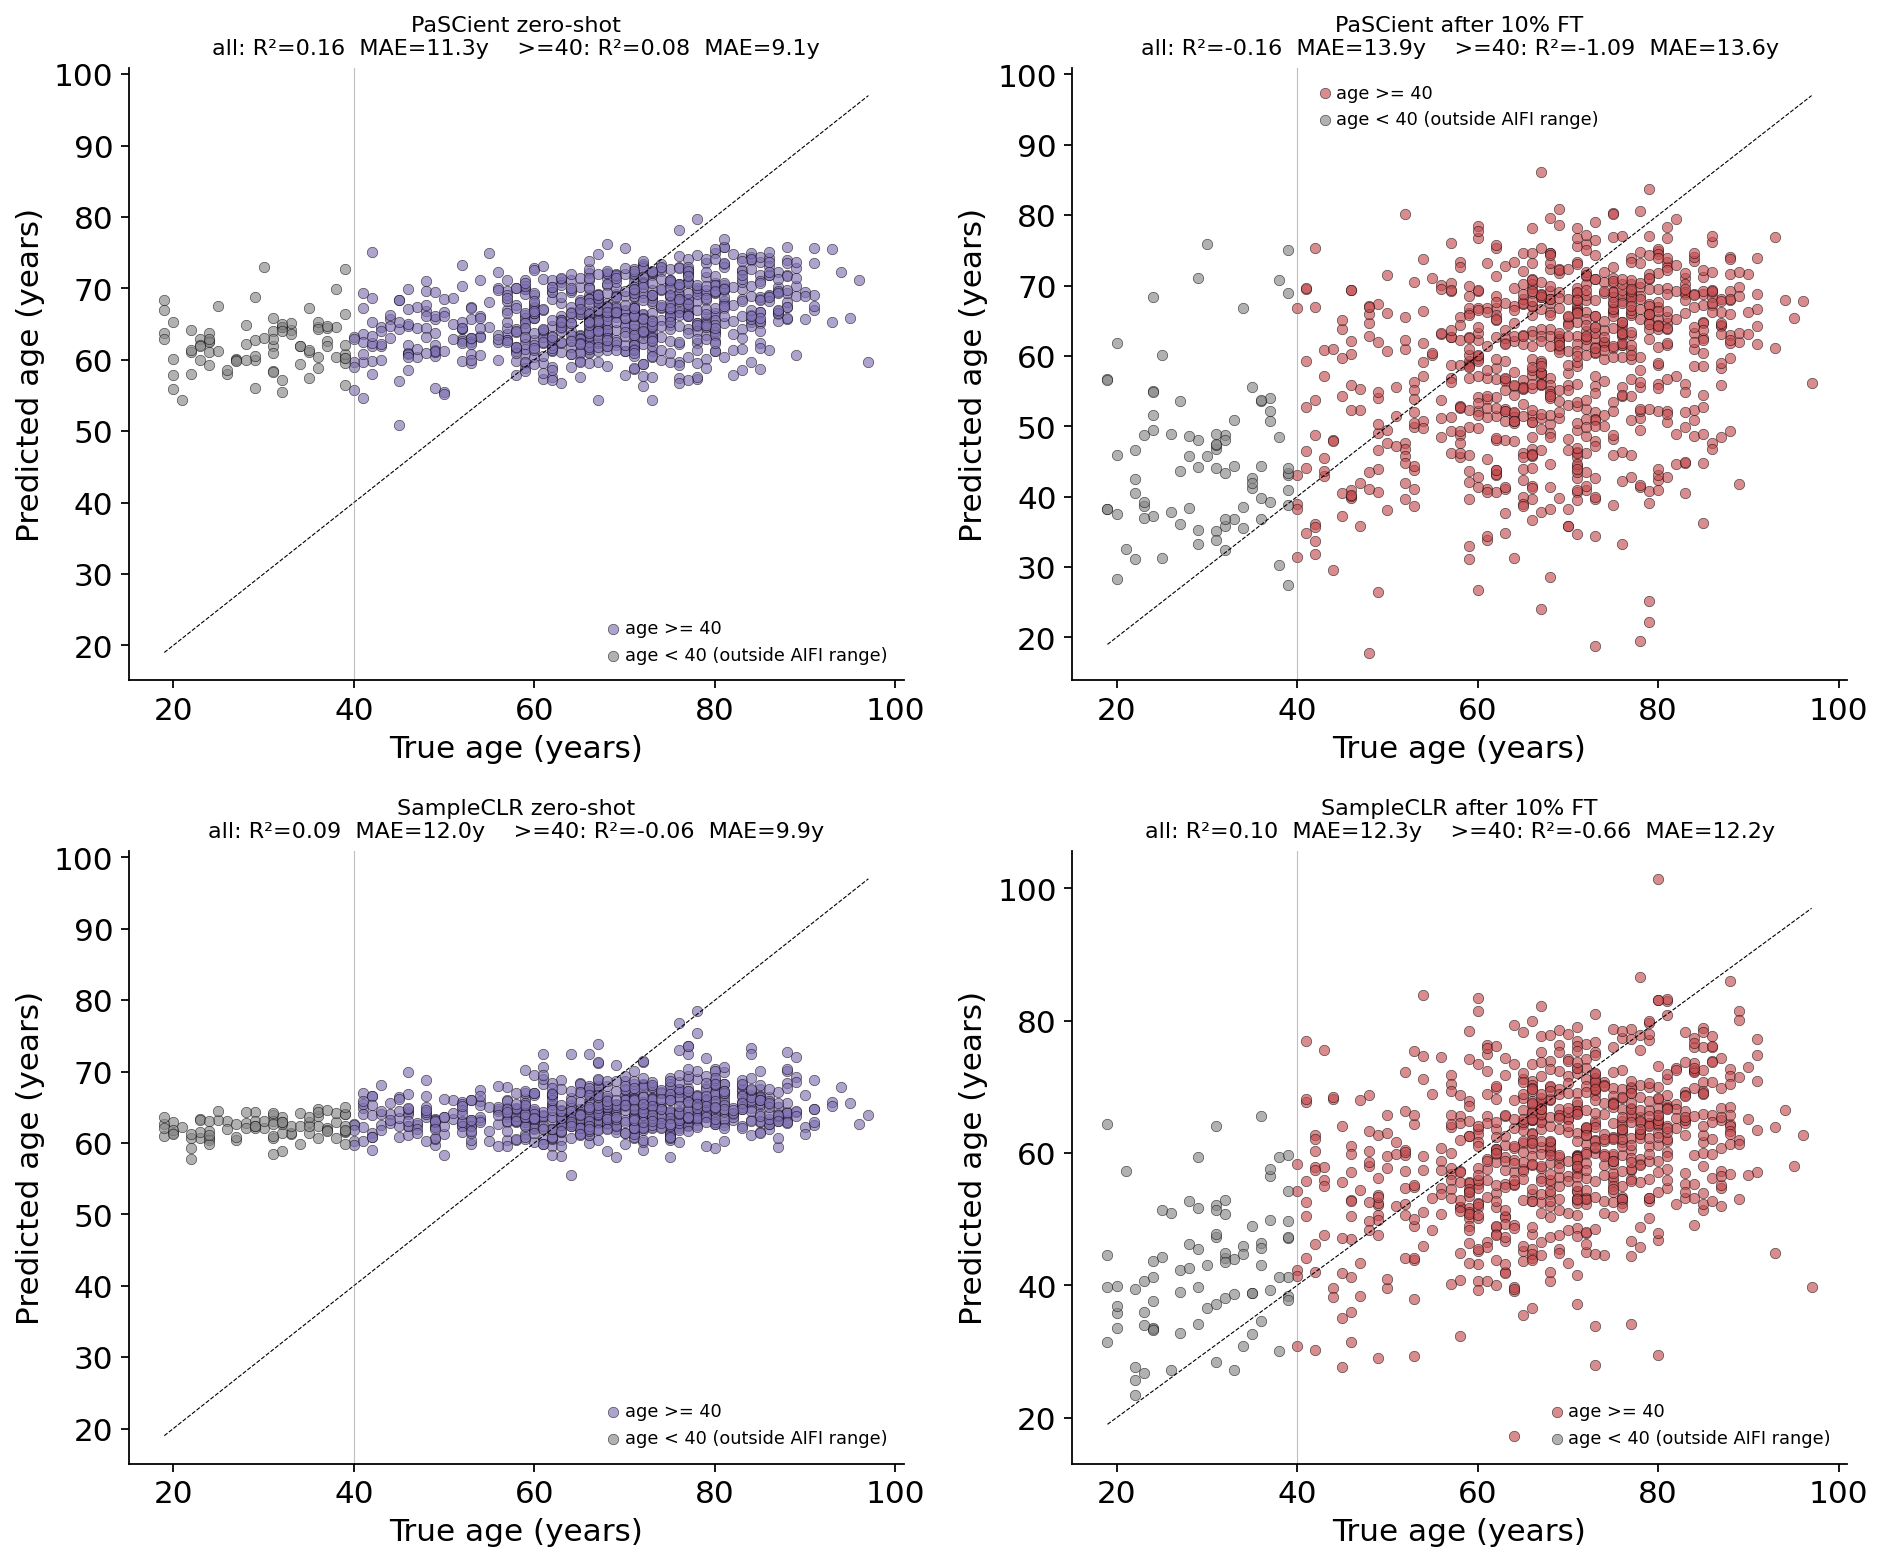

In [34]:
# Summary table — both all-donor and >=40 cuts.
transfer_df = pd.DataFrame([
    {"method": "PaSCient",  "set": "AIFI in-sample",             **aifi_pa_score},
    {"method": "PaSCient",  "set": "OneK1K zero-shot (all)",     **zs_pa_score_all},
    {"method": "PaSCient",  "set": "OneK1K zero-shot (>=40)",    **zs_pa_score_40},
    {"method": "PaSCient",  "set": "OneK1K after 10% FT (all)",  **ft_pa_score_all},
    {"method": "PaSCient",  "set": "OneK1K after 10% FT (>=40)", **ft_pa_score_40},
    {"method": "SampleCLR", "set": "AIFI in-sample",             **aifi_sc_score},
    {"method": "SampleCLR", "set": "OneK1K zero-shot (all)",     **zs_sc_score_all},
    {"method": "SampleCLR", "set": "OneK1K zero-shot (>=40)",    **zs_sc_score_40},
    {"method": "SampleCLR", "set": "OneK1K after 10% FT (all)",  **ft_sc_score_all},
    {"method": "SampleCLR", "set": "OneK1K after 10% FT (>=40)", **ft_sc_score_40},
])
print(transfer_df.round(3).to_string(index=False))

# Predicted-vs-true scatter, with the >=40 slice highlighted.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
panels = [
    (axes[0, 0], "PaSCient zero-shot",     age_zs_pa,      one_pa_pred_zs.values, zs_pa_score_all, zs_pa_score_40, "#8172B3"),
    (axes[0, 1], "PaSCient after 10% FT",  age_ft_pa,      one_pa_pred_ft.values, ft_pa_score_all, ft_pa_score_40, "#C44E52"),
    (axes[1, 0], "SampleCLR zero-shot",    age_test_one,   one_sc_pred_zs.values, zs_sc_score_all, zs_sc_score_40, "#8172B3"),
    (axes[1, 1], "SampleCLR after 10% FT", age_test_one,   one_sc_pred_ft.values, ft_sc_score_all, ft_sc_score_40, "#C44E52"),
]
for ax, title, y_true, y_pred, score_all, score_40, color in panels:
    below_aifi = y_true < 40
    ax.scatter(y_true[~below_aifi], y_pred[~below_aifi], s=22, alpha=0.65,
               color=color, edgecolor="black", lw=0.3, label="age >= 40")
    ax.scatter(y_true[below_aifi], y_pred[below_aifi], s=22, alpha=0.65,
               color="#888", edgecolor="black", lw=0.3, label="age < 40 (outside AIFI range)")
    lo, hi = float(np.nanmin(y_true)), float(np.nanmax(y_true))
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.5)
    ax.axvline(40, color="grey", lw=0.5, alpha=0.5)
    ax.set_xlabel("True age (years)"); ax.set_ylabel("Predicted age (years)")
    ax.set_title(
        f"{title}\n"
        f"all: R²={score_all['r2']:.2f}  MAE={score_all['mae']:.1f}y    "
        f">=40: R²={score_40['r2']:.2f}  MAE={score_40['mae']:.1f}y",
        fontsize=10,
    )
    ax.legend(fontsize=8, frameon=False)
    despine(ax)
plt.tight_layout(); plt.show()


**Reading the panels.** The left column is zero-shot transfer (no
OneK1K data ever seen); the right column is the same model after 15
fine-tune epochs on 10% of OneK1K donors at a 10× smaller learning
rate. A big jump from left to right means the AIFI-pretrained model
*has* useful aging features but they live in a slightly different
geometry — a small donor budget is enough to recalibrate. A small
jump means the supervised features are AIFI-specific and only a
re-train from scratch on OneK1K would help.

**Interpreting the transfer.** A perfect transfer would mean the model
learnt aging biology rather than AIFI-specific artefacts (batch
structure, recruitment bias, the 40-89 age range). Two failure modes
to watch for:

- **Floor effect at the AIFI age range.** OneK1K donors aged 19-39 may
  all collapse onto AIFI's youngest decade (40s), giving them an
  upward-biased predicted age. The scatter above makes this visible.
- **Sequencing-platform / annotation differences.** The shared-gene
  PCA only covers what both cohorts measured; cohort-specific gene
  programs are lost.

The MAE and Spearman on the right-hand scatter are the headline:
how many years off, and how well-ranked, are the predictions on a
cohort the model has never seen.

## Inside SampleCLR — what does fine-tuning move?

We snapshotted the aggregator twice during the SampleCLR run above —
once after self-supervised pretrain (SSL) and once after fine-tuning on
age (FT). Now we extract the per-cell, per-head attention weights from
both and ask three questions:

1. How does the held-out age score change SSL → FT?
2. Which immune cell types do the attention heads focus on, and how
   does that shift with FT?
3. Which (cell type, head) combinations correlate with donor age, and
   what genes drive that head's attention inside those cells?

In [35]:
def attention_weights_for_donors(aggregator, adata, donor_order, n_cells_per_donor=N_CELLS_PER_DONOR):
    """Per-cell, per-head SampleCLR attention as a tidy DataFrame.

    One row per (donor, sampled cell) with the cell type, the original ``obs``
    row index, and one ``head_<h>`` column per attention head.
    """
    aggregator.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    rng = np.random.default_rng(SEED)
    celltype_key = "AIFI_L2" if "AIFI_L2" in adata.obs else "cell_type"
    donor_of_cell = adata.obs["donor"].astype(str).values
    celltype_of_cell = adata.obs[celltype_key].astype(str).values
    cell_features = adata.obsm["X_pca"]

    rows = []
    with torch.no_grad():
        for donor in donor_order:
            cell_indices = np.flatnonzero(donor_of_cell == donor)
            if len(cell_indices) == 0:
                continue
            replace = len(cell_indices) < n_cells_per_donor
            picked = np.sort(rng.choice(cell_indices, size=n_cells_per_donor, replace=replace))
            features = torch.tensor(cell_features[picked].astype(np.float32)).unsqueeze(0).to(device)
            _, weights = aggregator(features, return_weights=True)
            weights = weights.squeeze(0).cpu().numpy()  # (n_cells, n_heads)
            for position, cell_index in enumerate(picked):
                row = {"donor": donor, "obs_idx": int(cell_index), "cell_type": celltype_of_cell[cell_index]}
                row.update({f"head_{head}": float(weights[position, head]) for head in range(weights.shape[1])})
                rows.append(row)
    return pd.DataFrame(rows)


# FT attention from the fine-tuned aggregator captured during the main run.
att_ft = attention_weights_for_donors(
    sclr_model.aggregator, sclr_adata, sclr_adata.obs["donor"].astype(str).unique().tolist()
)
n_heads = sum(col.startswith("head_") for col in att_ft.columns)
print(f"FT attention: {len(att_ft):,} rows across {att_ft['cell_type'].nunique()} cell types and {n_heads} heads")


FT attention: 117,000 rows across 28 cell types and 8 heads


We need both SSL and FT attention for the deltas, so we briefly retrain
a second SampleCLR instance, capture attention right after the SSL
stage, then dispose of it.

In [36]:
from sampleclr import ContrastiveModel


def quick_sampleclr_ssl(adata, sample_key="donor", layer="X_pca"):
    """Train only the self-supervised (SSL) stage, to capture pre-fine-tune attention."""
    subset = filter_and_subsample(adata, sample_size_threshold=0, max_cells_per_donor=N_CELLS_PER_DONOR)
    n_epochs = 10 if SMOKE else 40
    model = ContrastiveModel(
        adata=subset, sample_key=sample_key, layer=layer,
        tasks={"regression": ["age"]}, batch_size=8,
        num_epochs_stage1=n_epochs, num_epochs_stage2=1,   # only SSL matters here
        num_warmup_epochs_stage1=max(1, n_epochs // 5), num_warmup_epochs_stage2=1,
        aggregator_activation="relu",
        use_batch_aware_sampler=True, batch_sampler_batch_col="batch_id",
        verbose=False, seed=SEED,
    )
    model.pretrain()
    return model, subset


ssl_model, ssl_sub = quick_sampleclr_ssl(adata)
att_ssl = attention_weights_for_donors(
    ssl_model.aggregator, ssl_sub, ssl_sub.obs["donor"].astype(str).unique().tolist()
)
del ssl_model
gc.collect()
print(f"SSL attention: {len(att_ssl):,} rows")


0 samples removed: 


Stage 1: Contrastive-only training (pretrain)


Epoch 1/40 - Loss: 0.0211, Contr: 0.0210, Top1: 1.000, Top5: 1.000 | Time: 0.55s (30 batches, 8.5ms/batch)


Epoch 2/40 - Loss: 0.0141, Contr: 0.0140, Top1: 1.000, Top5: 1.000 | Time: 0.48s (30 batches, 10.1ms/batch)


Epoch 3/40 - Loss: 0.0055, Contr: 0.0054, Top1: 1.000, Top5: 1.000 | Time: 0.57s (30 batches, 11.7ms/batch)


...

Epoch 37/40 - Loss: 0.0005, Contr: 0.0004, Top1: 1.000, Top5: 1.000 | Time: 0.58s (30 batches, 11.7ms/batch)


Epoch 38/40 - Loss: 0.0005, Contr: 0.0005, Top1: 1.000, Top5: 1.000 | Time: 0.58s (30 batches, 11.7ms/batch)


Epoch 39/40 - Loss: 0.0006, Contr: 0.0005, Top1: 1.000, Top5: 1.000 | Time: 0.58s (30 batches, 11.7ms/batch)


Epoch 40/40 - Loss: 0.0005, Contr: 0.0005, Top1: 1.000, Top5: 1.000 | Time: 0.56s (30 batches, 11.3ms/batch)


SSL attention: 117,000 rows


### 1. SSL vs FT held-out age scores

          R²  Spearman     MAE
stage                         
SSL   -0.982     0.454  13.006
FT     0.936     0.972   2.617


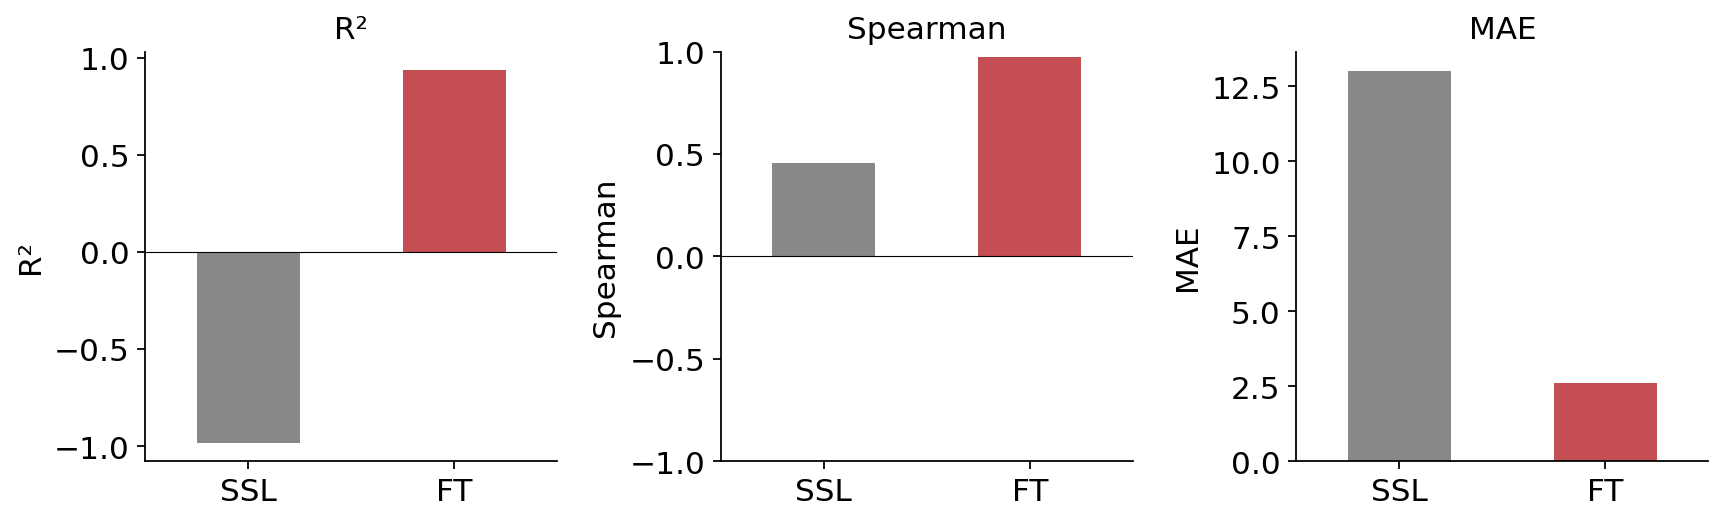

In [37]:
stage_scores = pd.DataFrame([
    {"stage": "SSL", "R²": score_ssl["r2"], "Spearman": score_ssl["spearman"], "MAE": score_ssl["mae"]},
    {"stage": "FT",  "R²": score_ft["r2"],  "Spearman": score_ft["spearman"],  "MAE": score_ft["mae"]},
]).set_index("stage")
print(stage_scores.round(3))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, metric in zip(axes, ["R²", "Spearman", "MAE"]):
    stage_scores[metric].plot(kind="bar", ax=ax, color=["#888", "#C44E52"])
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(metric); ax.set_ylabel(metric); ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=0)
    if metric == "Spearman":
        ax.set_ylim(-1, 1)        # Spearman is bounded in [-1, 1]
    despine(ax)
plt.tight_layout(); plt.show()


### 2. Attention distribution across cell types (SSL vs FT)

Mean attention per (cell type × head) — first 5 rows of FT:
                    head_0  head_1  head_2  head_3  head_4  head_5  head_6  head_7
cell_type                                                                         
ASDC                 2.203   0.000     0.0   0.000     0.0     0.0   0.000   3.117
CD14 monocyte        1.598   0.000     0.0   0.001     0.0     0.0   0.000   1.318
CD16 monocyte        1.354   0.000     0.0   0.000     0.0     0.0   0.000   2.327
CD56bright NK cell   1.583   0.003     0.0   0.407     0.0     0.0   0.168   3.042
CD56dim NK cell      1.573   0.000     0.0   0.010     0.0     0.0   0.002   2.366


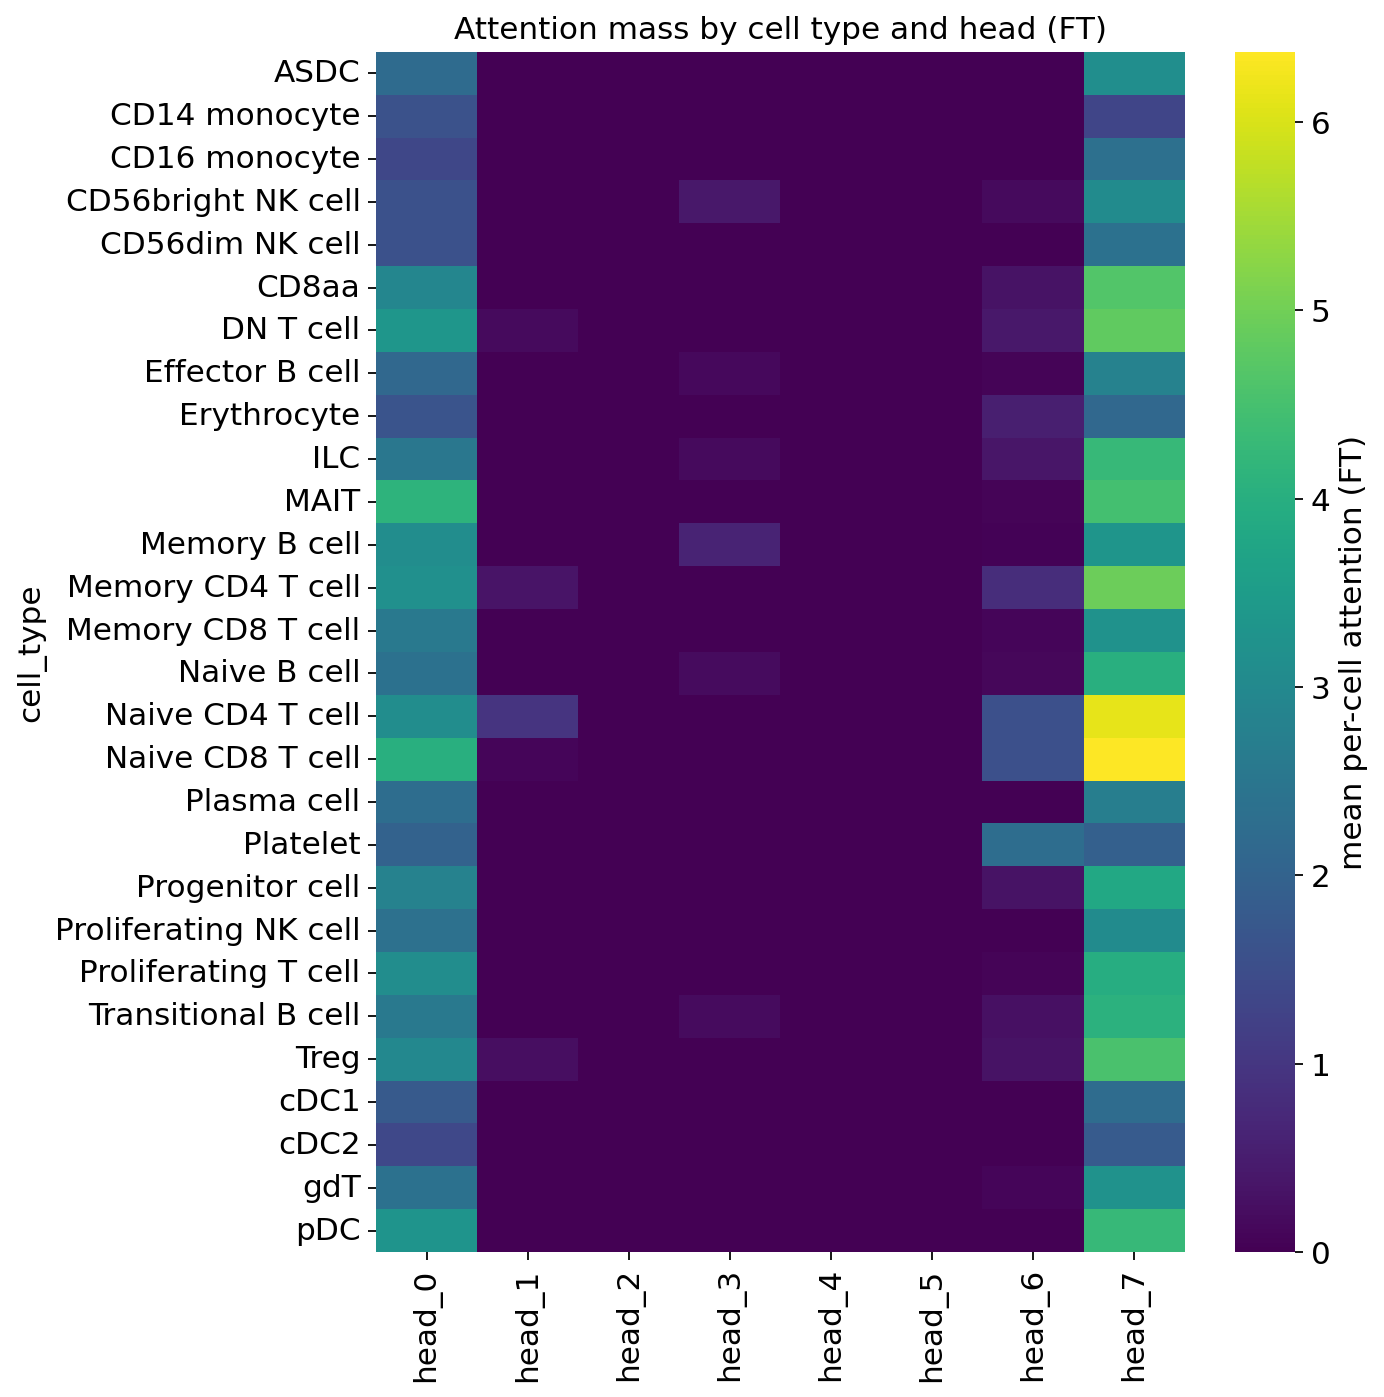

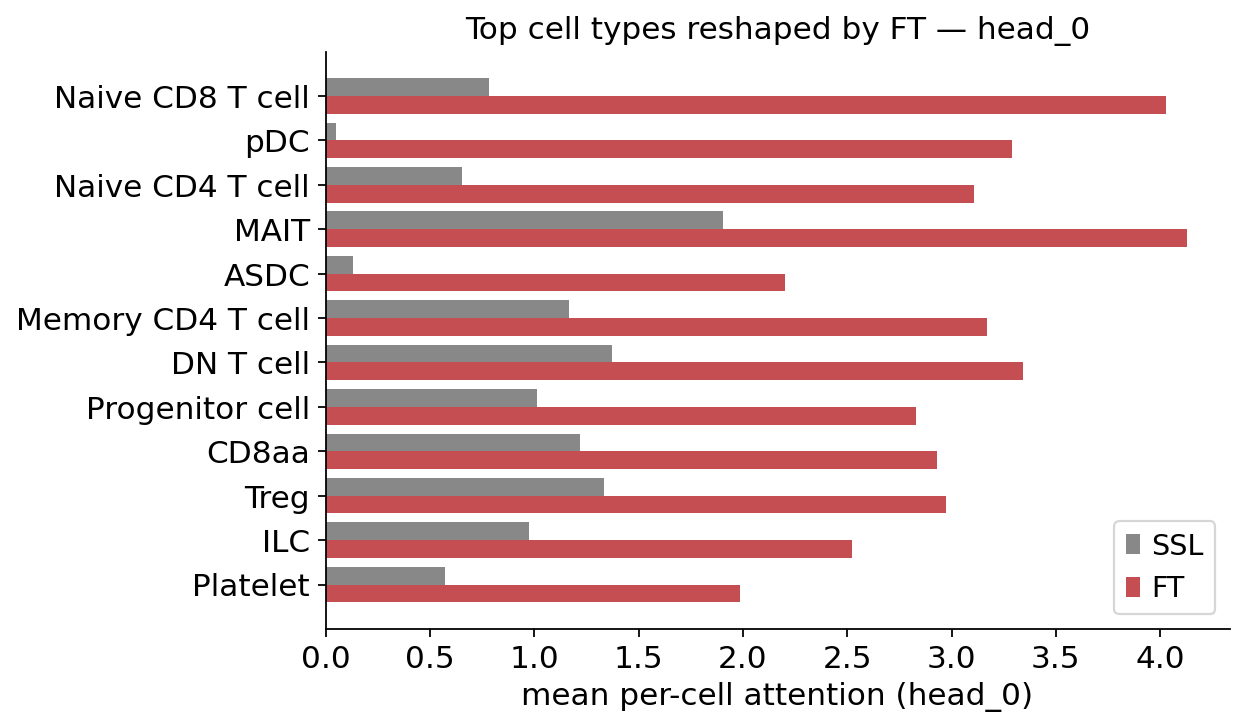

In [38]:
def attention_by_celltype(att):
    head_cols = [c for c in att.columns if c.startswith("head_")]
    return att.groupby("cell_type", observed=True)[head_cols].mean()


attention_ssl = attention_by_celltype(att_ssl)
attention_ft = attention_by_celltype(att_ft)
print("Mean attention per (cell type × head) — first 5 rows of FT:")
print(attention_ft.head().round(3).to_string())

# Heatmap of FT attention per (cell type × head).
fig, ax = plt.subplots(figsize=(9, max(5, 0.32 * len(attention_ft))))
sns.heatmap(attention_ft, ax=ax, cmap="viridis", cbar_kws={"label": "mean per-cell attention (FT)"})
ax.grid(False)
ax.set_title("Attention mass by cell type and head (FT)")
plt.tight_layout(); plt.show()

# Side-by-side bars: the cell types head_0 reshapes most between SSL and FT.
head_name = "head_0"
head0_comparison = pd.concat(
    [attention_ssl[head_name].rename("SSL"), attention_ft[head_name].rename("FT")], axis=1
).dropna()
head0_comparison = (
    head0_comparison.assign(delta=(head0_comparison["FT"] - head0_comparison["SSL"]).abs())
    .sort_values("delta", ascending=False)
    .head(12)
)
positions = np.arange(len(head0_comparison))
fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(head0_comparison))))
ax.barh(positions - 0.2, head0_comparison["SSL"], height=0.4, color="#888", label="SSL")
ax.barh(positions + 0.2, head0_comparison["FT"], height=0.4, color="#C44E52", label="FT")
ax.set_yticks(positions); ax.set_yticklabels(head0_comparison.index)
ax.set_xlabel(f"mean per-cell attention ({head_name})")
ax.invert_yaxis(); ax.legend()
ax.set_title(f"Top cell types reshaped by FT — {head_name}")
despine(ax)
plt.tight_layout(); plt.show()


### Attention dotplot (SampleCLR heads × cell type)

A complementary view of the same FT attention matrix: a scanpy dotplot
where colour encodes mean attention weight and size encodes the fraction
of cells with non-zero attention. Easier to read off than the dense
heatmap when there are many cell types.


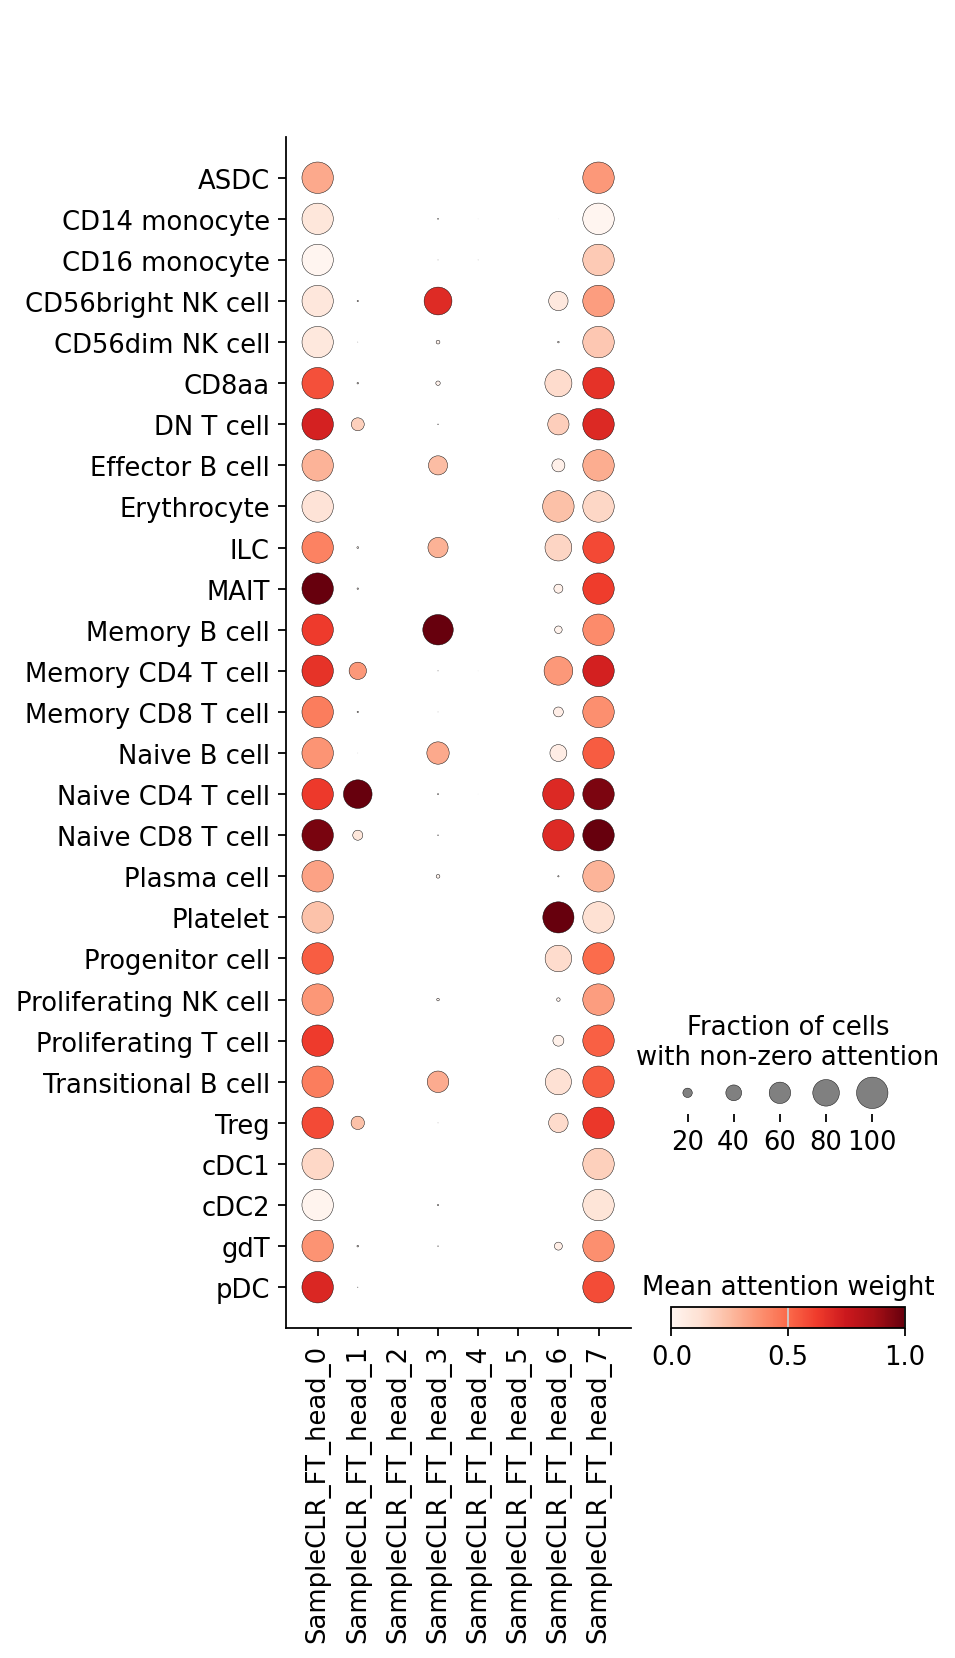

In [39]:
# Attention -> AnnData with one obs per (sampled) cell and one var per head.
head_cols = [c for c in att_ft.columns if c.startswith("head_")]
head_names = [f"SampleCLR_FT_head_{c.split('_')[1]}" for c in head_cols]
att_X = att_ft[head_cols].values.astype(np.float32)
att_adata = ad.AnnData(X=att_X)
att_adata.obs["cell_type"] = pd.Categorical(att_ft["cell_type"].astype(str).values)
att_adata.var_names = head_names

sc.pl.dotplot(att_adata, var_names=list(att_adata.var_names),
              groupby="cell_type",
              colorbar_title="Mean attention weight",
              size_title="Fraction of cells\nwith non-zero attention",
              standard_scale="var")


### Persist SampleCLR cell-level attention weights

`att_ssl` and `att_ft` are the per-cell, per-head attention weights at the
self-supervised and fine-tuned stages — one row per (donor, sampled
cell), plus `cell_type` and `obs_idx` (the row index into the original
AIFI ``adata``). We dump both DataFrames to parquet so the
gene-attention analysis below can be re-run without retraining
SampleCLR twice (the SSL re-train in cell 51 alone takes a few
minutes).


In [40]:
ATT_DIR = META_ADATA_DIR
ATT_SSL_PATH = ATT_DIR / "sampleclr_attention_ssl.parquet"
ATT_FT_PATH  = ATT_DIR / "sampleclr_attention_ft.parquet"
try:
    att_ssl.to_parquet(ATT_SSL_PATH, index=False)
    att_ft.to_parquet(ATT_FT_PATH, index=False)
    print(f"attention SSL -> {ATT_SSL_PATH}  ({ATT_SSL_PATH.stat().st_size / 1e6:.1f} MB, "
          f"{len(att_ssl):,} rows)")
    print(f"attention FT  -> {ATT_FT_PATH}  ({ATT_FT_PATH.stat().st_size / 1e6:.1f} MB, "
          f"{len(att_ft):,} rows)")
except Exception as e:
    # pyarrow may be missing; fall back to CSV (~10x bigger but always works).
    print(f"parquet write failed ({e}); falling back to CSV")
    att_ssl.to_csv(ATT_DIR / "sampleclr_attention_ssl.csv", index=False)
    att_ft.to_csv(ATT_DIR / "sampleclr_attention_ft.csv", index=False)
    print(f"attention SSL -> {ATT_DIR / 'sampleclr_attention_ssl.csv'}")
    print(f"attention FT  -> {ATT_DIR / 'sampleclr_attention_ft.csv'}")


attention SSL -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/sampleclr_attention_ssl.parquet  (3.8 MB, 117,000 rows)
attention FT  -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/sampleclr_attention_ft.parquet  (3.5 MB, 117,000 rows)


### 3. (cell type, head) correlation with age

Top (cell_type, head) age correlations after FT:
        cell_type   head         r  nonzero_fraction  n_cells  n_donors
             cDC1 head_0 -0.573485          1.000000       16        14
 Naive CD4 T cell head_1  0.475841          0.881480    22975       233
             ASDC head_7  0.382513          1.000000       18        15
Memory CD4 T cell head_1  0.361576          0.453064    21849       234
             ASDC head_0  0.359478          1.000000       18        15
            CD8aa head_7 -0.345054          1.000000       55        39
 Naive CD8 T cell head_1  0.306912          0.218438     5315       221
  Effector B cell head_0 -0.257150          0.998624     1453       207
             Treg head_6 -0.246860          0.527072     4174       234
         Platelet head_7 -0.220583          1.000000      166        93
 Naive CD8 T cell head_6 -0.217907          0.999624     5315       221
              gdT head_6 -0.214857          0.160418     2294       221


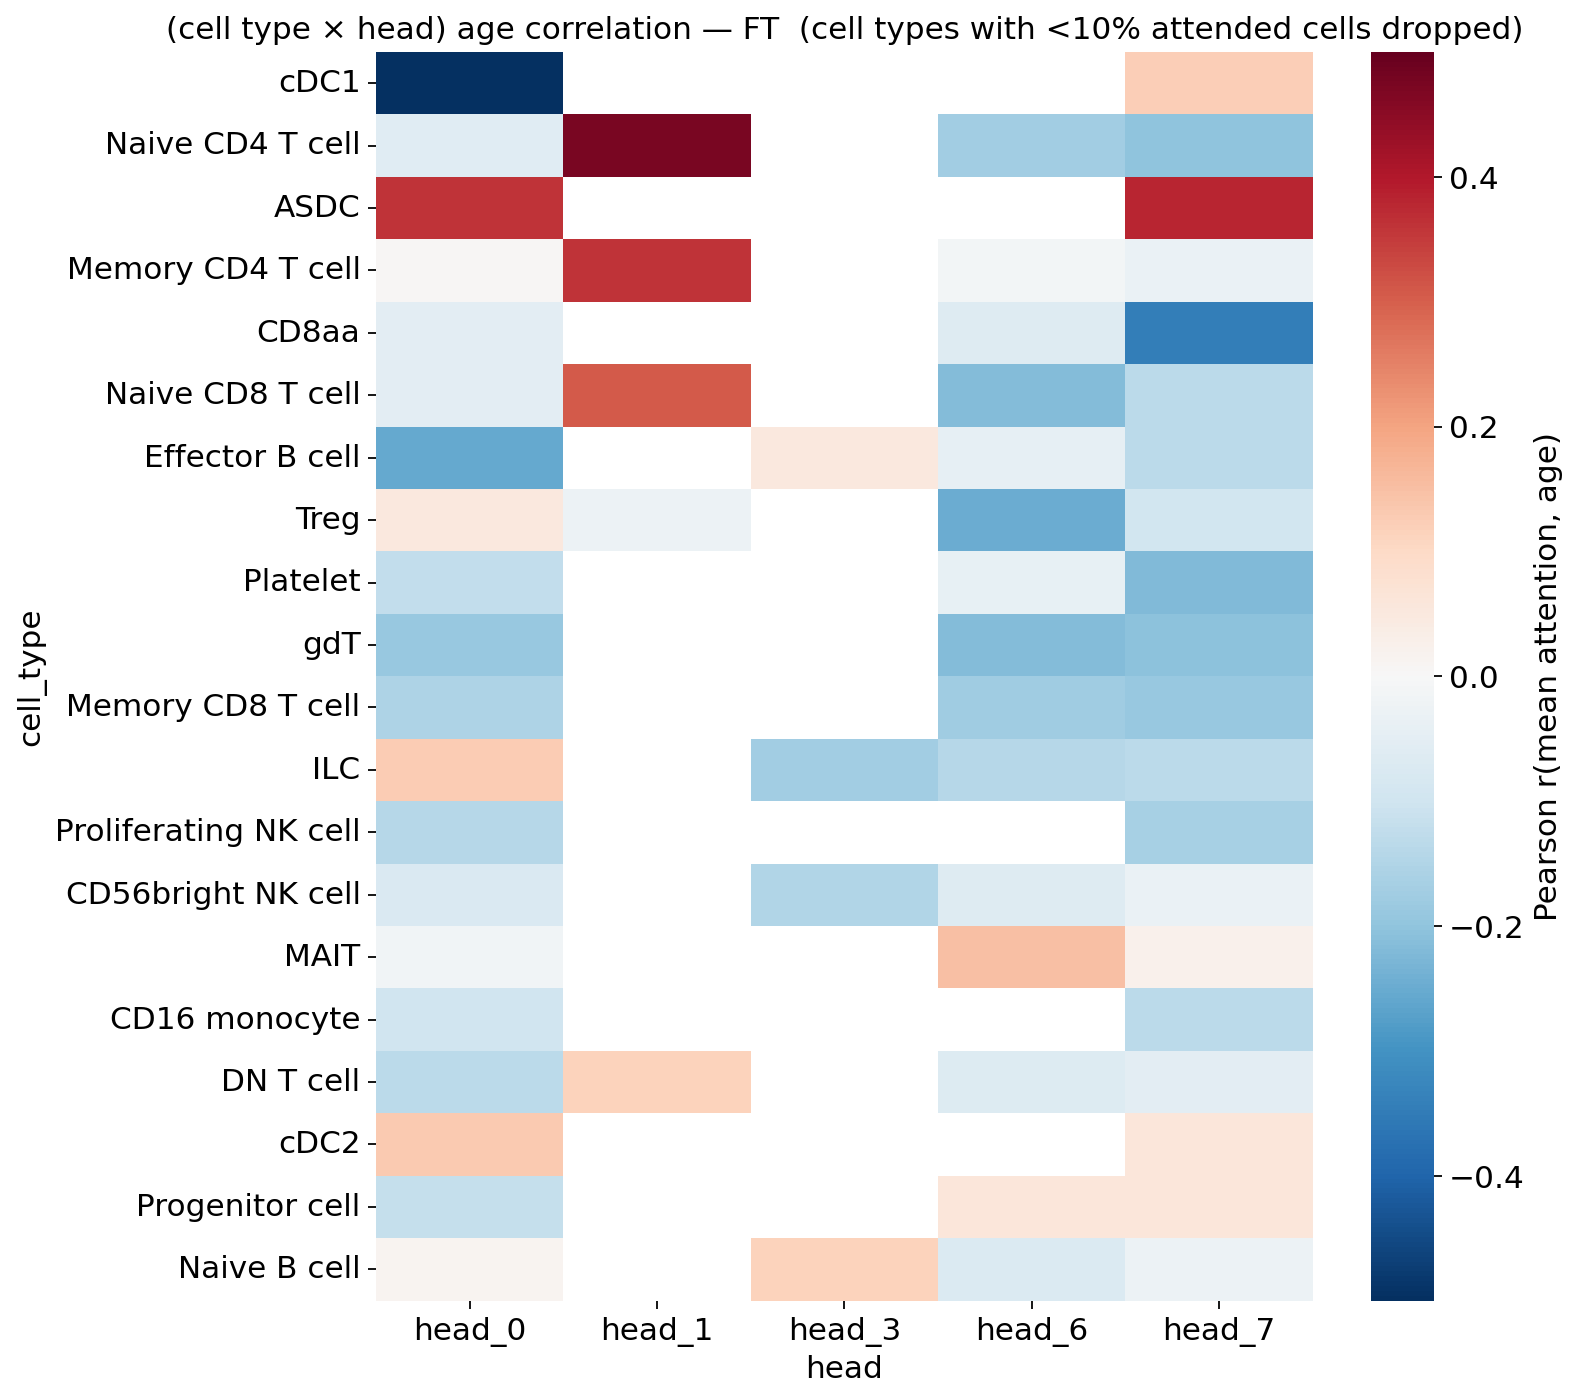

In [41]:
def celltype_head_age_corr(att, meta, min_nonzero_fraction=0.10):
    """Per (cell type, head): Pearson r between donor-mean attention and age.

    A head that attends to almost no cells of a given type carries no reliable
    signal there, so (cell type, head) pairs where fewer than
    ``min_nonzero_fraction`` of that cell type's cells receive non-zero attention
    are dropped.
    """
    head_cols = [c for c in att.columns if c.startswith("head_")]
    rows = []
    for cell_type, group in att.groupby("cell_type", observed=True):
        nonzero_fraction = (group[head_cols] > 0).mean()
        per_donor = (
            group.groupby("donor", observed=True)[head_cols].mean()
            .join(meta["age"]).dropna(subset=["age"])
        )
        if len(per_donor) < 5:
            continue
        age = per_donor.pop("age").values.astype(float)
        for head in head_cols:
            if nonzero_fraction[head] < min_nonzero_fraction:
                continue
            attention = per_donor[head].values.astype(float)
            r = float(np.corrcoef(age, attention)[0, 1]) if np.std(attention) > 1e-8 else np.nan
            rows.append({
                "cell_type": cell_type, "head": head, "r": r,
                "nonzero_fraction": float(nonzero_fraction[head]),
                "n_cells": int(len(group)), "n_donors": int(len(per_donor)),
            })
    return pd.DataFrame(rows)


corr_ft = celltype_head_age_corr(att_ft, donor_meta).sort_values("r", key=lambda s: s.abs(), ascending=False)
corr_ssl = celltype_head_age_corr(att_ssl, donor_meta).sort_values("r", key=lambda s: s.abs(), ascending=False)
print("Top (cell_type, head) age correlations after FT:")
print(corr_ft.head(12).to_string(index=False))

# Heatmap of the most age-correlated cell types. Only cell types that receive
# attention from >=10% of their cells survive the filter above, so the rows are
# all reliable. The figure is sized generously so the cell-type labels are legible.
matrix = corr_ft.pivot_table(index="cell_type", columns="head", values="r")
matrix = matrix.reindex(matrix.abs().max(axis=1).sort_values(ascending=False).head(20).index)
fig, ax = plt.subplots(figsize=(10, max(6, 0.45 * len(matrix))))
sns.heatmap(matrix, ax=ax, cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
            cbar_kws={"label": "Pearson r(mean attention, age)"})
ax.grid(False)
ax.set_title("(cell type × head) age correlation — FT  (cell types with <10% attended cells dropped)")
plt.tight_layout(); plt.show()


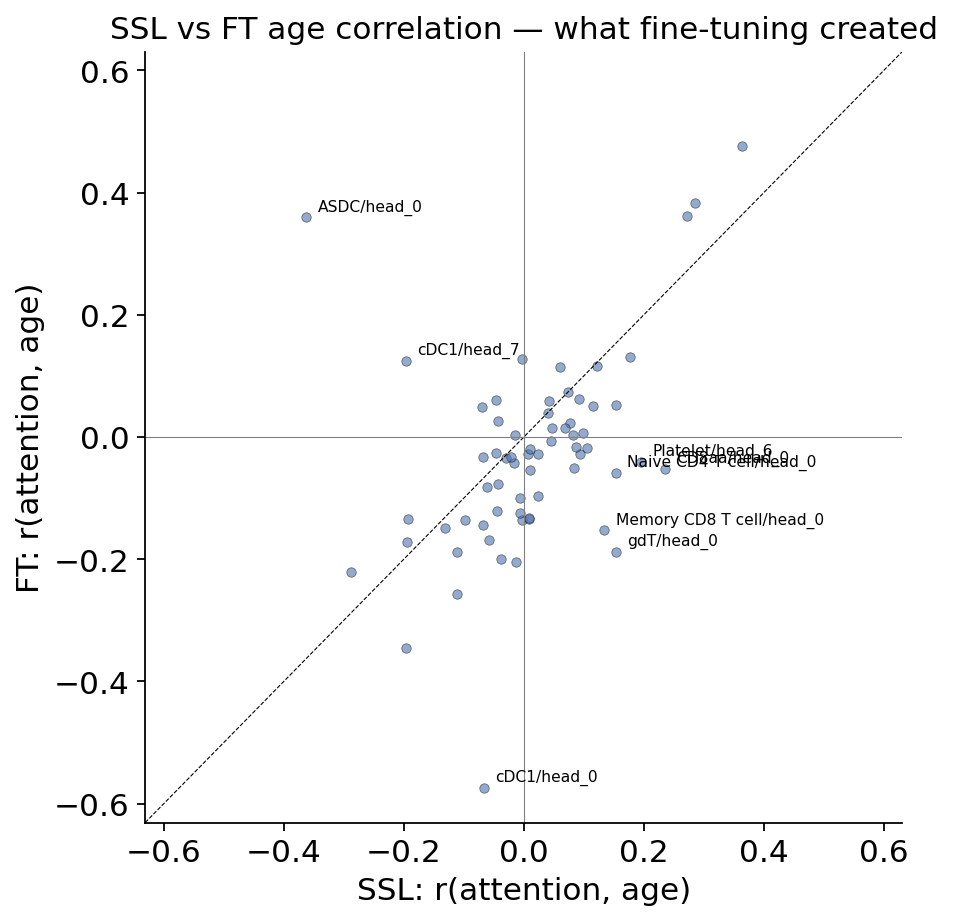

In [42]:
# SSL vs FT scatter — points far from the diagonal are what fine-tuning created.
ssl_vs_ft = (
    corr_ft[["cell_type", "head", "r"]].rename(columns={"r": "FT"})
    .merge(corr_ssl[["cell_type", "head", "r"]].rename(columns={"r": "SSL"}), on=["cell_type", "head"], how="inner")
    .dropna(subset=["SSL", "FT"])
)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ssl_vs_ft["SSL"], ssl_vs_ft["FT"], s=18, color="#4C72B0", alpha=0.6, edgecolor="black", lw=0.3)
biggest_shifts = ssl_vs_ft.assign(delta=(ssl_vs_ft["FT"] - ssl_vs_ft["SSL"]).abs()).sort_values("delta", ascending=False).head(8)
for _, row in biggest_shifts.iterrows():
    ax.annotate(f"{str(row['cell_type'])[:20]}/{row['head']}", (row["SSL"], row["FT"]),
                xytext=(5, 3), textcoords="offset points", fontsize=7)
abs_max = float(ssl_vs_ft[["SSL", "FT"]].abs().to_numpy().max()) if not ssl_vs_ft.empty else 0.1
lim = max(abs_max if np.isfinite(abs_max) else 0.1, 0.1) * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("SSL: r(attention, age)"); ax.set_ylabel("FT: r(attention, age)")
ax.set_title("SSL vs FT age correlation — what fine-tuning created")
despine(ax)
plt.tight_layout(); plt.show()


### 4. Genes that drive the age-correlated attention

In [43]:
def gene_attention_correlation(att, adata, hits, n_top_genes=10):
    """For each (cell type, head) hit, the genes whose expression best correlates
    with that head's per-cell attention within the cell type."""
    gene_names = np.asarray(adata.var_names)
    rows = []
    for _, hit in hits.iterrows():
        subset = att[att["cell_type"] == hit["cell_type"]]
        if len(subset) < 30:
            continue
        obs_idx = subset["obs_idx"].astype(int).values
        attention = subset[hit["head"]].values.astype(np.float32)
        expression = adata.X[obs_idx]
        if hasattr(expression, "toarray"):
            expression = expression.toarray()
        expression = np.asarray(expression, dtype=np.float32)
        attention_z = (attention - attention.mean()) / (attention.std() + 1e-12)
        expression_z = (expression - expression.mean(axis=0)) / (expression.std(axis=0) + 1e-12)
        correlations = (attention_z @ expression_z) / len(attention)
        top = np.argsort(-np.abs(correlations))[:n_top_genes]
        for gene_pos in top:
            rows.append({"cell_type": hit["cell_type"], "head": hit["head"],
                         "head_age_r": float(hit["r"]), "gene": gene_names[gene_pos],
                         "r": float(correlations[gene_pos]), "n_cells": int(len(attention))})
    return pd.DataFrame(rows, columns=["cell_type", "head", "head_age_r", "gene", "r", "n_cells"])


top_hits = corr_ft.head(6).copy()
gene_attention_corr = gene_attention_correlation(att_ft, sclr_adata, top_hits, n_top_genes=12)
print(gene_attention_corr.head(15).round(3).to_string(index=False))


        cell_type   head  head_age_r   gene     r  n_cells
 Naive CD4 T cell head_1       0.476   BCL2 0.420    22975
 Naive CD4 T cell head_1       0.476   CISH 0.414    22975
 Naive CD4 T cell head_1       0.476   PIM1 0.361    22975
 Naive CD4 T cell head_1       0.476  SESN3 0.340    22975
 Naive CD4 T cell head_1       0.476 ARID5B 0.321    22975
 Naive CD4 T cell head_1       0.476 PCED1B 0.293    22975
 Naive CD4 T cell head_1       0.476  DACT1 0.292    22975
 Naive CD4 T cell head_1       0.476  MDFIC 0.289    22975
 Naive CD4 T cell head_1       0.476 ZNF101 0.275    22975
 Naive CD4 T cell head_1       0.476 PTGER2 0.268    22975
 Naive CD4 T cell head_1       0.476    TXK 0.256    22975
 Naive CD4 T cell head_1       0.476  ADTRP 0.254    22975
Memory CD4 T cell head_1       0.362  SESN3 0.399    21849
Memory CD4 T cell head_1       0.362   FHIT 0.383    21849
Memory CD4 T cell head_1       0.362  ADTRP 0.365    21849


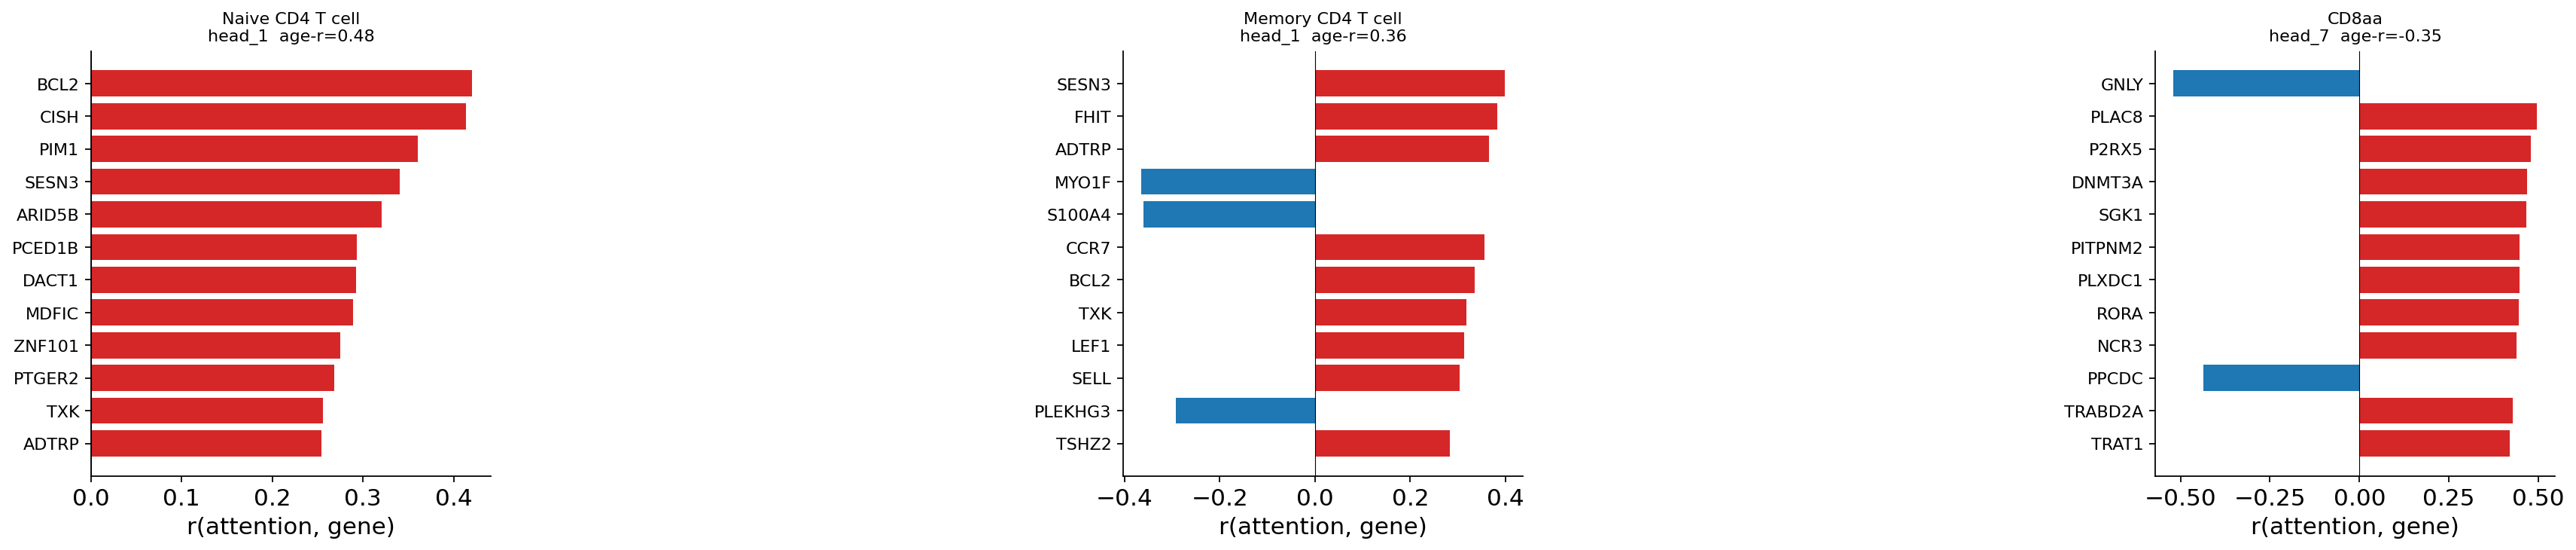

In [44]:
# Gene-attention panels, one per (cell type, head) hit, laid out in a single row.
n_hits = top_hits.shape[0]
fig, axes = plt.subplots(1, n_hits, figsize=(n_hits * 4.2, 4.8), squeeze=False)
for ax, (_, hit) in zip(axes.ravel(), top_hits.iterrows()):
    genes = gene_attention_corr[
        (gene_attention_corr["cell_type"] == hit["cell_type"]) & (gene_attention_corr["head"] == hit["head"])
    ].sort_values("r", key=lambda s: s.abs(), ascending=False)
    if genes.empty:
        ax.set_visible(False)
        continue
    ax.barh(genes["gene"], genes["r"],
            color=["#1f77b4" if value < 0 else "#d62728" for value in genes["r"]])
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{str(hit['cell_type'])[:30]}\n{hit['head']}  age-r={hit['r']:.2f}", fontsize=10)
    ax.set_xlabel("r(attention, gene)")
    ax.tick_params(axis="y", labelsize=10)
    ax.invert_yaxis()
    despine(ax)
plt.tight_layout(); plt.show()


**Reading the panels.** Red bars: cells with **higher** expression of
that gene receive **more** attention. Blue bars: cells with **lower**
expression of that gene receive **more** attention. The header line
gives the cell type, the head index, and the age correlation of that
head's per-donor mean attention.

For example, an NK-cell head whose age correlation is positive and
whose red bars include `GZMB`, `PRF1`, `NKG7` is the model saying *as
donors age, I find more cytotoxic-program NK cells, and I weight them
up*. The same pattern shows up in CD8 T-cell heads with terminal
effector markers and CD14+ monocyte heads with activation markers.

## Sweeping the fine-tune donor budget

10% was an arbitrary choice. How does test-set age prediction change
as we vary the fraction `f` of OneK1K donors used for fine-tuning?

We sweep `f ∈ {0, 0.05, 0.10, 0.20, 0.30, 0.50}` with 5-fold
age-stratified CV over OneK1K donors. For each fold we hold out 20%
of donors as the test set, then for each fraction sample `f × N_total`
donors from the remaining 80% (young-weighted, same scheme as the 10%
subset above), restore each method to its AIFI-pretrained weights, run
the FT stage, and predict the test fold's ages. We report `R²`,
Spearman ρ, and MAE.

The sweep re-uses the AIFI-pretrained state snapshots we captured
earlier (``pa_aifi_state`` for PaSCient, ``sclr_aifi_state`` for
SampleCLR). MixMIL gets its own AIFI pretrain inside this section.

This cell takes a while on a GPU (~80 minutes for the full sweep);
results are saved incrementally to a CSV so the plotting cell can
re-read partial progress if needed.


In [45]:
# --- FT fraction sweep x K-fold CV (each model predicts age with its own head) ---
from sklearn.model_selection import StratifiedKFold
from sampleclr import ContrastiveModel

SWEEP_DIR = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/"
                 "patpy-aging-tutorial/data/aging_benchmark/ft_fraction_sweep_notebook")
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_CSV = SWEEP_DIR / "scores.csv"
SWEEP_PRED = SWEEP_DIR / "predictions.csv"

FRACTIONS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]
N_FOLDS = 2 if SMOKE else 5

# AIFI pretrain / fine-tune epoch budgets per method (mirror the cells above).
MIXMIL_AIFI_EPOCHS = 200 if SMOKE else 1500
MIXMIL_FT_EPOCHS = 50 if SMOKE else 500
PASCIENT_FT_EPOCHS = 5 if SMOKE else 15
PASCIENT_FT_LR = 1e-5
SAMPLECLR_FT_EPOCHS = 5 if SMOKE else 20

device = "cuda" if torch.cuda.is_available() else "cpu"
one_donor_age = adata_one.obs.groupby("donor", observed=True)["age"].first().astype(np.float32)


def age_stratified_kfold(donor_age, n_splits=N_FOLDS, seed=SEED):
    donor_age = donor_age.dropna().astype(float)
    bins = pd.qcut(donor_age, q=min(5, n_splits), duplicates="drop").cat.codes.values
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    donors = donor_age.index.tolist()
    return [([donors[i] for i in train], [donors[i] for i in test])
            for train, test in splitter.split(donors, bins)]


def sample_young_weighted_from(available, donor_age, n_target, seed):
    """Young-weighted draw without replacement, restricted to ``available``."""
    if n_target <= 0 or len(available) == 0:
        return []
    available_ages = donor_age.reindex(available).dropna()
    if len(available_ages) <= n_target:
        return list(available_ages.index)
    weights = (available_ages.max() - available_ages + 1.0).values
    weights = weights / weights.sum()
    rng = np.random.default_rng(seed)
    return list(rng.choice(available_ages.index.values, size=n_target, replace=False, p=weights))


# ---- Per-method predict runners: restore AIFI weights, optional FT, then predict ----

def pascient_predict_sweep(pascient, aifi_state, ft_adata, test_adata, fraction):
    pascient._pascient_model.load_state_dict({k: v.to(pascient.device) for k, v in aifi_state.items()})
    if fraction > 0 and ft_adata.obs["donor"].nunique() >= 2:
        pascient.adata = ft_adata
        pascient.samples = pd.unique(ft_adata.obs["donor"]).tolist()
        pascient.labels = pascient._extract_metadata(pascient.label_keys)
        pascient.lr = PASCIENT_FT_LR
        pascient.fine_tune("age", "regression", n_epochs=PASCIENT_FT_EPOCHS)
    return pascient_predict_on(pascient, test_adata)


def sampleclr_predict_sweep(aifi_model, aifi_state, ft_adata, test_adata, fraction):
    test_donors = pd.unique(test_adata.obs["donor"]).tolist()
    if not (fraction > 0 and ft_adata.obs["donor"].nunique() >= 2):
        # Zero-shot: the AIFI-trained model predicts OneK1K directly through its head.
        return predict_age_sampleclr(aifi_model, test_adata, test_donors,
                                     layer="X_pca_shared", subset_size=N_CELLS_TRANSFER)
    model = ContrastiveModel(
        adata=ft_adata, sample_key="donor", layer="X_pca_shared",
        tasks={"regression": ["age"]}, batch_size=8,
        num_epochs_stage1=1, num_epochs_stage2=SAMPLECLR_FT_EPOCHS,
        num_warmup_epochs_stage1=1, num_warmup_epochs_stage2=max(1, SAMPLECLR_FT_EPOCHS // 5),
        aggregator_activation="relu", use_batch_aware_sampler=False, verbose=False, seed=SEED,
    )
    try:
        model.projector.load_state_dict({k: v.to(device) for k, v in aifi_state["projector"].items()})
        model.aggregator.load_state_dict({k: v.to(device) for k, v in aifi_state["aggregator"].items()})
    except RuntimeError as error:
        print(f"WARN sampleclr load: {error}")
    model.fine_tune(val_metric="loss")
    prediction = predict_age_sampleclr(model, test_adata, test_donors,
                                       layer="X_pca_shared", subset_size=N_CELLS_TRANSFER)
    del model; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return prediction


def _point_mixmil(mixmil, adata):
    mixmil.adata = adata
    mixmil.samples = pd.unique(adata.obs["donor"]).tolist()
    mixmil.labels = mixmil._extract_metadata(mixmil.label_keys)


def mixmil_predict_sweep(mixmil, aifi_state, ft_adata, test_adata, aifi_adata, fraction, min_ref_donors=5):
    mixmil._model.load_state_dict(aifi_state)
    # Drop any regression probe left over from a previous fold *before* the native
    # fine-tune: MixMIL forbids mixing task types, so a stale "age" (regression)
    # label would make fine_tune("age_group", "classification") raise.
    mixmil._probes.pop("age", None)
    if "age" in mixmil.label_keys:
        age_idx = mixmil.label_keys.index("age")
        mixmil.label_keys.pop(age_idx); mixmil.tasks.pop(age_idx)

    use_ft = fraction > 0 and ft_adata.obs["donor"].nunique() >= 2
    if use_ft:
        _point_mixmil(mixmil, ft_adata)
        try:
            mixmil.fine_tune("age_group", "classification", n_epochs=MIXMIL_FT_EPOCHS)
        except Exception as error:
            print(f"WARN MixMIL FT failed: {type(error).__name__}: {error}")
    # Train the regression probe on a labelled reference cohort (the FT donors when
    # there are enough, otherwise the AIFI donors), then predict the test fold.
    reference = ft_adata if (use_ft and ft_adata.obs["donor"].nunique() >= min_ref_donors) else aifi_adata
    _point_mixmil(mixmil, reference)
    mixmil.fit_linear_probe("age", task="regression", test_sample_labels=[], store=True)
    _point_mixmil(mixmil, test_adata)
    return mixmil.predict("age")


# AIFI MixMIL pretrain — same recipe as the main benchmark but on the shared-PCA layer.
mm_sweep = patpy.tl.MixMIL(
    sample_key="donor", label_keys=["age_group"], tasks=["classification"],
    cell_group_key=None, layer="X_pca_shared",
    likelihood="binomial", n_trials=2,
    n_epochs=MIXMIL_AIFI_EPOCHS, batch_size=8, seed=SEED,
)
mm_sweep.prepare_anndata(aifi_t, train=True)
mm_aifi_state = {k: v.detach().cpu().clone() for k, v in mm_sweep._model.state_dict().items()}

folds = age_stratified_kfold(one_donor_age, n_splits=N_FOLDS, seed=SEED)
print(f"folds: {[len(test) for _, test in folds]} test donors each")

runners = {
    "pascient": lambda ft, test, fraction: pascient_predict_sweep(pa, pa_aifi_state, ft, test, fraction),
    "sampleclr": lambda ft, test, fraction: sampleclr_predict_sweep(sclr_t, sclr_aifi_state, ft, test, fraction),
    "mixmil": lambda ft, test, fraction: mixmil_predict_sweep(mm_sweep, mm_aifi_state, ft, test, aifi_t, fraction),
}

score_rows = []
prediction_frames = []
n_total = len(one_donor_age.dropna())
for fold_index, (train_fold, test_fold) in enumerate(folds):
    print(f"\n--- Fold {fold_index + 1}/{len(folds)}: test n={len(test_fold)} ---")
    test_adata_fold = one_t[one_t.obs["donor"].isin(test_fold)].copy()
    for fraction in FRACTIONS:
        n_finetune = round(fraction * n_total)
        seed_for_pick = SEED + 1000 * fold_index + int(fraction * 100)
        ft_donors = sample_young_weighted_from(train_fold, one_donor_age, n_finetune, seed=seed_for_pick)
        if n_finetune > 0 and len(ft_donors) < 2:
            continue
        ft_adata_fold = one_t[one_t.obs["donor"].isin(ft_donors)].copy() if ft_donors else one_t[:0]

        for method, runner in runners.items():
            started = time.time()
            try:
                predictions = runner(ft_adata_fold, test_adata_fold, fraction)
                y_true = one_donor_age.reindex(predictions.index).astype(float).values
                scores = patpy.tl.evaluate_regression(y_true, predictions.values.astype(float))
                score_rows.append({
                    "method": method, "fold": fold_index, "fraction": fraction,
                    "n_ft": len(ft_donors), "n_test": len(test_fold),
                    **scores, "t_sec": round(time.time() - started, 1),
                })
                print(f"  {method:9s} f={fraction:.2f} fold={fold_index}  R²={scores['r2']:.3f}  "
                      f"Spearman={scores['spearman']:.3f}  MAE={scores['mae']:.2f}  n={scores['n']}  "
                      f"({score_rows[-1]['t_sec']}s)")
                prediction_frames.append(pd.DataFrame({
                    "method": method, "fold": fold_index, "fraction": fraction,
                    "donor": list(predictions.index), "y_true": y_true, "y_pred": predictions.values,
                }))
            except Exception as error:
                print(f"  {method} fold={fold_index} f={fraction} failed: {type(error).__name__}: {error}")
        pd.DataFrame(score_rows).to_csv(SWEEP_CSV, index=False)

sweep_df = pd.DataFrame(score_rows)
sweep_df.to_csv(SWEEP_CSV, index=False)
if prediction_frames:
    pd.concat(prediction_frames, ignore_index=True).to_csv(SWEEP_PRED, index=False)
print(f"\nSweep done. {len(sweep_df)} rows -> {SWEEP_CSV}")


Epoch:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch:   0%|          | 1/1500 [00:05<2:06:20,  5.06s/it]

Epoch:   0%|          | 2/1500 [00:05<55:38,  2.23s/it]  

Epoch:   0%|          | 3/1500 [00:05<33:01,  1.32s/it]

Epoch:   0%|          | 4/1500 [00:05<22:23,  1.11it/s]

...

Epoch: 100%|█████████▉| 498/500 [02:50<00:00,  2.99it/s]

Epoch: 100%|█████████▉| 499/500 [02:51<00:00,  2.99it/s]

Epoch: 100%|██████████| 500/500 [02:51<00:00,  2.99it/s]

Epoch: 100%|██████████| 500/500 [02:51<00:00,  2.92it/s]

  mixmil    f=0.50 fold=4  R²=0.276  Spearman=0.516  MAE=10.52  n=196  (174.2s)

Sweep done. 90 rows -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/ft_fraction_sweep_notebook/scores.csv


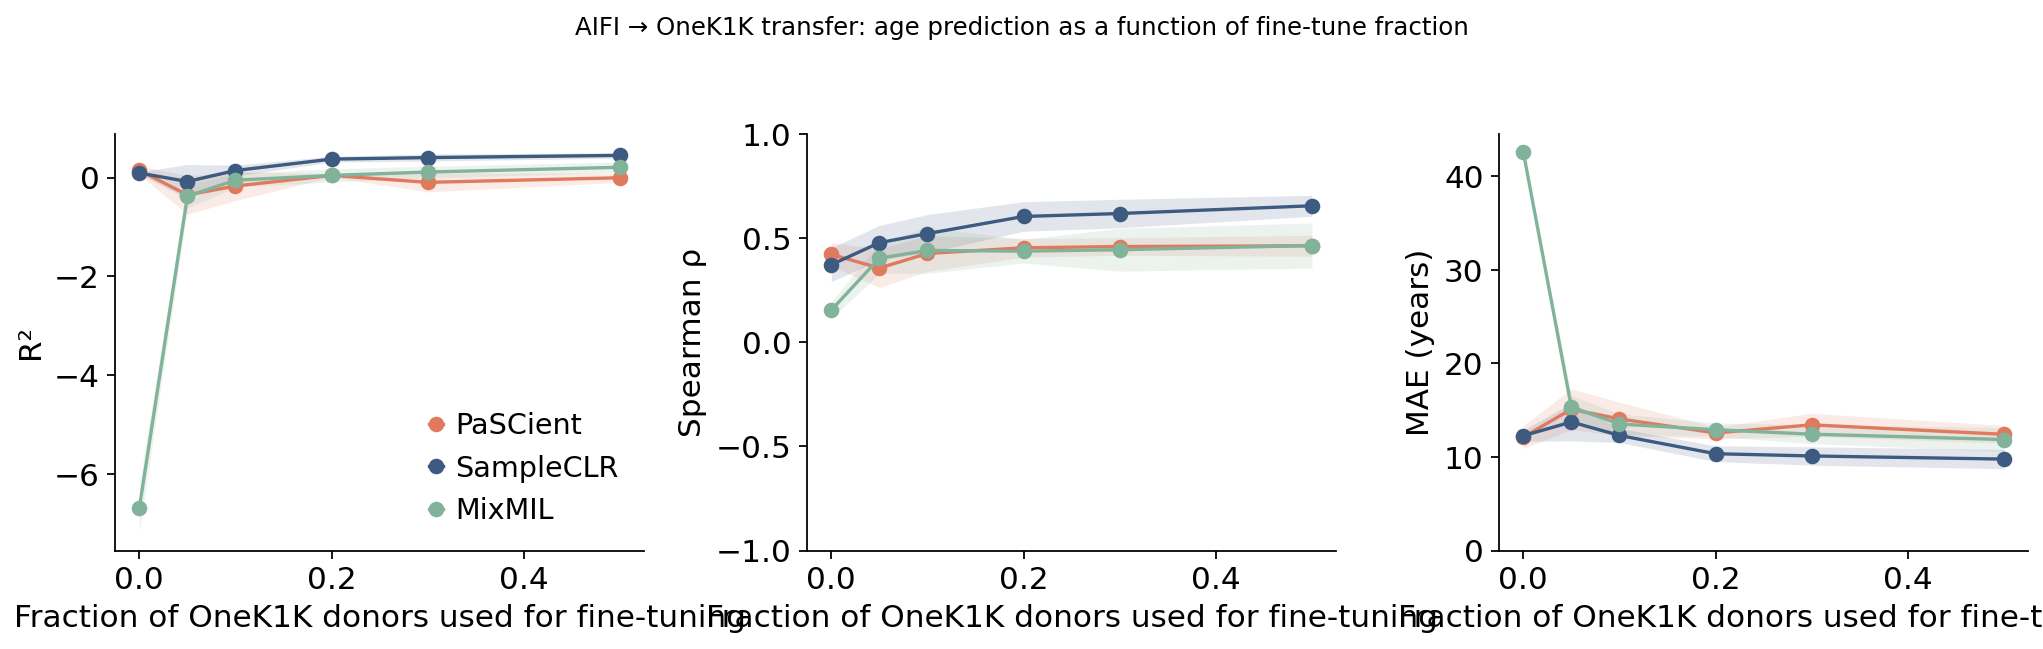

                    r2_mean  r2_std  spearman_mean  mae_mean  n_folds
method    fraction                                                   
mixmil    0.00       -6.689   0.481          0.154    42.630        5
          0.05       -0.377   0.239          0.403    15.329        5
          0.10       -0.051   0.138          0.440    13.527        5
          0.20        0.045   0.133          0.437    12.916        5
          0.30        0.114   0.119          0.444    12.440        5
          0.50        0.210   0.105          0.464    11.870        5
pascient  0.00        0.148   0.089          0.421    12.129        5
          0.05       -0.351   0.391          0.356    15.106        5
          0.10       -0.169   0.293          0.426    14.075        5
          0.20        0.046   0.038          0.453    12.572        5
          0.30       -0.096   0.193          0.459    13.438        5
          0.50       -0.002   0.093          0.463    12.424        5
sampleclr 0.00      

In [46]:
# Plot R²/Spearman/MAE vs FT fraction, mean ± SD across folds.
METHOD_ORDER = ["pascient", "sampleclr", "mixmil"]
METHOD_LABEL = {"pascient": "PaSCient", "sampleclr": "SampleCLR", "mixmil": "MixMIL"}
METHOD_COLOR = {"pascient": "#E07A5F", "sampleclr": "#3D5A80", "mixmil": "#81B29A"}

metrics = [("r2", "R²", None),
            ("spearman", "Spearman ρ", -1),
            ("mae", "MAE (years)", 0)]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, label, ylo) in zip(axes, metrics):
    for method in METHOD_ORDER:
        sub = sweep_df[sweep_df["method"] == method].dropna(subset=[col])
        if sub.empty:
            continue
        agg = sub.groupby("fraction")[col].agg(["mean", "std", "count"]).reset_index()
        x = agg["fraction"].values
        mu = agg["mean"].values
        sd = agg["std"].fillna(0).values
        ax.plot(x, mu, marker="o", color=METHOD_COLOR[method], label=METHOD_LABEL[method])
        ax.fill_between(x, mu - sd, mu + sd, color=METHOD_COLOR[method], alpha=0.15, linewidth=0)
    ax.set_xlabel("Fraction of OneK1K donors used for fine-tuning")
    ax.set_ylabel(label)
    if ylo is not None:
        ax.set_ylim(bottom=ylo)
    if col == "spearman":
        ax.set_ylim(-1, 1)
    despine(ax)
axes[0].legend(frameon=False, loc="best")
fig.suptitle("AIFI → OneK1K transfer: age prediction as a function of fine-tune fraction",
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

# Per-method summary table
summary = (sweep_df.groupby(["method", "fraction"])
            .agg(r2_mean=("r2", "mean"),
                 r2_std=("r2", "std"),
                 spearman_mean=("spearman", "mean"),
                 mae_mean=("mae", "mean"),
                 n_folds=("r2", "count"))
            .round(3))
print(summary.to_string())


## Persist trained models

The AIFI-pretrained state dicts for each method are the slow part of the
pipeline (PaSCient: ~10 min on GPU, MixMIL: ~5 min, SampleCLR: ~1 min).
We snapshot all three into a single ``torch.save`` archive so that
downstream analyses (e.g. running the FT-fraction sweep again with
different hyperparameters, or transferring to a third cohort) can
restore the weights without re-pretraining.

We also dump the FT-fraction sweep CSVs so the sweep can be re-plotted
without re-running.


In [47]:
import torch as _torch

MODELS_PATH = META_ADATA_DIR / "aifi_models.pt"

_torch.save(
    {
        "pascient": {
            "state_dict": pa_aifi_state,
            "config": {
                "sample_key": "donor", "label_keys": ["age"], "tasks": ["regression"],
                "cell_group_key": None, "layer": "X_shared_genes",
                "n_cells": N_CELLS_TRANSFER, "normalize": False, "seed": SEED,
            },
        },
        "sampleclr": {
            "state_dict": sclr_aifi_state,
            "config": {
                "sample_key": "donor", "layer": "X_pca_shared",
                "tasks": {"regression": ["age"]},
                "batch_size": 8, "num_epochs_stage1": 30, "num_epochs_stage2": 30,
                "aggregator_activation": "relu",
                "use_batch_aware_sampler": True,
                "batch_sampler_batch_col": "batch_id",
                "seed": SEED,
            },
        },
        "mixmil": {
            "state_dict": mm_aifi_state,
            "config": {
                "sample_key": "donor", "label_keys": ["age_group"],
                "tasks": ["classification"], "cell_group_key": None,
                "layer": "X_pca_shared", "likelihood": "binomial", "n_trials": 2,
                "n_epochs": MIXMIL_AIFI_EPOCHS, "batch_size": 8, "seed": SEED,
            },
        },
        "aifi_donors": aifi_donors,
        "shared_genes": shared_genes,
        "pca_shared_components": pca_shared.components_,
        "pca_shared_mean": pca_shared.mean_,
        "patpy_version": patpy.__version__,
    },
    MODELS_PATH,
)
print(f"models -> {MODELS_PATH}  ({MODELS_PATH.stat().st_size / 1e6:.1f} MB)")
print("How to restore PaSCient on a new cohort:")
print("    blob = torch.load(MODELS_PATH)")
print("    pa = patpy.tl.PaSCient(**blob['pascient']['config'])")
print("    pa.prepare_anndata(new_adata, train=True)")
print("    pa._pascient_model.load_state_dict(blob['pascient']['state_dict'])")

# Also dump the sweep CSV next to the rest of the artifacts.
sweep_df.to_csv(META_ADATA_DIR / "ft_fraction_sweep_scores.csv", index=False)
print(f"sweep scores -> {META_ADATA_DIR / 'ft_fraction_sweep_scores.csv'}")


models -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/aifi_models.pt  (12.5 MB)
How to restore PaSCient on a new cohort:
    blob = torch.load(MODELS_PATH)
    pa = patpy.tl.PaSCient(**blob['pascient']['config'])
    pa.prepare_anndata(new_adata, train=True)
    pa._pascient_model.load_state_dict(blob['pascient']['state_dict'])
sweep scores -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/ft_fraction_sweep_scores.csv


## Take-aways

**Biology**

1. **The reproducible signal is compositional.** CLR-composition reaches
   `R²≈0.30` for held-out age on both AIFI and OneK1K. The same
   cell-type families move in the same direction in both cohorts: naive
   CD4 / CD8 T cells ↓, GZMB+ effectors and CD16+ monocytes ↑, naive B
   cells ↓.
2. **Within-cell-type transcription adds real predictive power.**
   PaSCient and SampleCLR-FT both beat composition on both cohorts. The
   attention deep-dive reveals what they're picking up: cytotoxic
   program in NK / effector-CD8, classical-monocyte activation, plasma
   cell signatures, etc.
3. **Fine-tuning concentrates the attention on age-discriminative cells.**
   SSL attention is roughly proportional to cell-type prevalence; FT
   attention shifts toward the cell types whose abundance and
   transcriptional state track age. The SSL-vs-FT scatter above makes
   this explicit.

**Method notes**

- **Scoring goes through patpy.** Unsupervised methods are scored with the
  built-in linear probe (`fit_linear_probe`, embedding methods) or KNN on the
  distance matrix (`predict_knn`, GloScope); supervised methods predict with
  their own head via `predict()`. All metrics come from
  `patpy.tl.evaluate_regression`.
- **Composition (CLR)** is the cheap interpretable baseline and the one
  that most cleanly replicates across cohorts. Use it first.
- **Pseudobulk** and **GloScope** add modest extra signal but inherit
  batch structure from `X_pca`.
- **PaSCient** consumes log-normalised gene expression (`adata.X`) with
  `normalize=False`; for cross-cohort transfer it runs on the shared gene panel.
  Predictions come straight from its native regression head.
- **MixMIL** only supports binomial / categorical likelihoods upstream, so we
  train its native head on the binary `age_group` and attach a regression linear
  probe (patpy's `fit_linear_probe(..., store=True)`) for continuous age.
- **Held-out scoring is honest for unsupervised, biased for supervised**
  (the supervised models saw test donors' ages during training). The
  cross-cohort agreement and the attention-driven biology are the more
  defensible comparisons.

For follow-up, the same template generalises to any donor-level
continuous target: BMI, severity scores, response to therapy,
time-to-event.
